# **PoliMillionaire - *Literally Losing My-mind***

**Project Overview:**

This project builds an autonomous agent to compete in the **"Who Wants to be a PoliMillionaire?"** online quiz. The quiz covers five categories. The agent must answer multiple-choice questions within a 30-second timeout using only locally-hosted models (no external APIs).

**Course Information:**
```
University:      Politecnico di Milano
Course:          Natural Language Processing (NLP)
Academic Year:   2025/2026
Professor:       Mark Carman James
```

**Team Members:**
```
Jasmin Spinetto
Olga Eskarous
Luca Colangelo
Hossam Eldin Ahmed Hussien
Andrea Mikhaiel
```


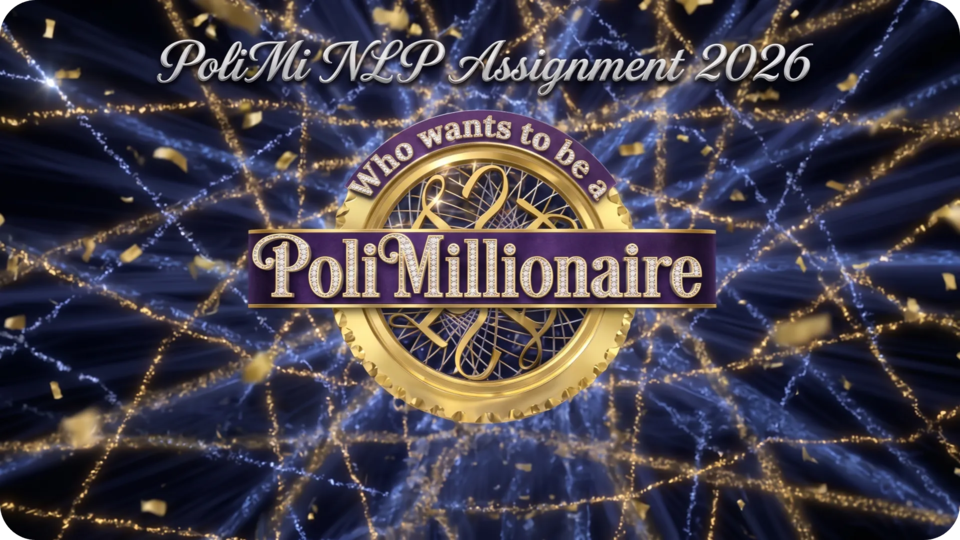

## 🌐 **Colab Setup**

> **Run these cells ONLY if running on Google Colab**  
>
> Ensure that the project folder structure is maintained and that the notebook is placed in the root of your project directory. Specifically, a folder named utils/ containing all the utility scripts provided with the assignment must be present in the same directory as this notebook:
> ```
> /your-project-folder
> ├── PoliMillionaire.ipynb
> └── utils/
>     ├── utility_1.py
>     └── ...
> ```

### ⚙️ Libraries Import

In [1]:
!pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 19.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=32d2184971089dcc90ca2293bbaebf2bb1e62f4f352a9c13335825c93a73cf67
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [2]:
SEED = 42
import os, random, logging, warnings, inspect
import numpy as np
import gc, re, string
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from google.colab import userdata
from huggingface_hub import login
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer, CrossEncoder
#i was trying to fix import error ~hossam
!pip install -U bitsandbytes>=0.46.1
from transformers import AutoModelForSequenceClassification, AutoTokenizer,AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
#--------#
from transformers.utils import logging as hf_logging
import whisper

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import random

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__} | device: {device}")


PyTorch 2.11.0+cu128 | device: cuda


In [3]:
# os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
# os.environ["TRANSFORMERS_VERBOSITY"] = "error"
# logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
# logging.getLogger("transformers").setLevel(logging.ERROR)
# warnings.filterwarnings("ignore", category=FutureWarning)
# hf_logging.disable_progress_bar()


### ⏳ Loading Data & Platform Utils

```
gdrive_home/
├── NLP_assignment/
│     ├── PoliMillionaire.ipynb  <-- Notebook
│     └── millionaire_client/    <-- Utils Directory
```

In [4]:
from google.colab import drive
import os
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [5]:
path = 'NLP_assignement'

os.chdir(f'/content/gdrive/MyDrive/{path}')
os.getcwd()

'/content/gdrive/MyDrive/NLP_assignement'

In [6]:
from millionaire_client import MillionaireClient, AuthenticationError, GameError

### ➜] Login

In [7]:
API_URL = "http://131.175.15.22:51111/"
username = "Hossam"
password = userdata.get('poli-millionaire')
hf_token = userdata.get('HF_TOKEN')

In [8]:
client = MillionaireClient(API_URL)
try:
    user = client.login(username, password)
    print(f"Welcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")

login(token=hf_token)


Welcome, Hossam! (Role: student)


## 🖥️ **Local Setup**

> **Run these cells ONLY if running locally** (repo cloned, not on Colab).
>
> Requires a `.env` file at the repo root (see `.env.example`):
> ```
> API_URL  = http://131.175.15.22:51111/
> USERNAME = your_username
> PASSWORD = your_password
> HF_TOKEN = your_huggingface_token
> ```

### ⚙️ Libraries Import

In [ ]:
import importlib.util, subprocess, sys
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

packages = {
    "matplotlib":             "matplotlib",
    "torch":                  "torch",
    "torchvision":            "torchvision",
    "sentence-transformers":  "sentence_transformers",
    "transformers":           "transformers",
    "huggingface_hub":        "huggingface_hub",
    "openai-whisper":         "whisper",
    "python-dotenv":          "dotenv",
    "networkx":               "networkx",
    "faiss-cpu":              "faiss",
    "scikit-learn":           "sklearn",
}

for pip_name, import_name in packages.items():
    if importlib.util.find_spec(import_name) is not None:
        print(f"  ✓ {pip_name}")
    else:
        print(f"  ↓ {pip_name} ... ", end="", flush=True)
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", pip_name], check=True)
        print("installed")

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



  ✓ matplotlib
  ✓ torch
  ✓ torchvision
  ✓ sentence-transformers
  ✓ transformers
  ✓ huggingface_hub
  ✓ openai-whisper
  ✓ python-dotenv
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_189/2045098915.py", line 21, in <cell line: 0>
    if importlib.util.find_spec(import_name) is not None:
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib.util>", line 100, in find_spec
  File "<frozen importlib._bootstrap>", line 1262, in _find_spec
  File "<frozen importlib._bootstrap_external>", line 1532, in find_spec
  File "<frozen importlib._bootstrap_external>", line 1504, in _get_spec
  File "<frozen importlib._bootstrap_external>", line 1483, in _path_importer_cache
OSError: [Errno 107] Transport endpoint is not connected

During handling of the above exception, another exception occurred:

Traceback (m

In [ ]:
SEED = 42
import os, gc, re, string, random, logging, warnings, inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers.utils import logging as hf_logging
import whisper
from huggingface_hub import login
from dotenv import dotenv_values

os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__} | device: {device}")


PyTorch 2.11.0+cu128 | device: cuda


In [ ]:
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=FutureWarning)
hf_logging.disable_progress_bar()


### ➜] Login & Platform Utils

In [ ]:
if os.path.basename(os.getcwd()) == "deliverables":
    os.chdir("..")  # repo root
assert os.path.exists("utils"), "Could not find utils/ — run from NLP_challenge root."
print(f"cwd: {os.getcwd()}")

env      = dotenv_values(".env")
API_URL  = env["API_URL"]
username = env["USERNAME"]
password = env["PASSWORD"]
hf_token = env["HF_TOKEN"]

from utils import MillionaireClient, AuthenticationError, GameError
client = MillionaireClient(API_URL)
try:
    user = client.login(username, password)
    print(f"Welcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")

login(token=hf_token, add_to_git_credential=False)

cwd: /content/gdrive/MyDrive/NLP_assignement


KeyError: 'API_URL'

## 🕹️ **Play**

In [9]:
def list_competitions():
  """
  Lists available competitions.
  """

  print("\n=== Available Competitions ===")
  competitions = client.competitions.list_all()
  for comp in competitions:
    print(f"  {comp.id}: {comp.name} ({comp.max_levels} questions)")

  return competitions

In [10]:
def show_leaderboard(comp_id):
  """
  Shows leaderboard position for the given competition id.
  """

  lb = client.leaderboard.get(competition_id=comp_id, limit=10)
  print(f"\n=== Leaderboard for {lb.competition.name} ===")
  for i, entry in enumerate(lb.entries[:5], 1):
      marker = " <-- YOU" if entry.username == username else ""
      print(f"  {i}. {entry.username}: ${entry.score:,.2f} (Level {entry.reached_level}){marker}")

In [11]:
def play(model, transcriber=None, test_all=True, math_only=False, multiplicity=20, verbose=False, debug=False):
  """
    Runs an interactive quiz session against the online platform.
    Allows the user to select a competition, play multiple games, and
    tracks performance history (games played, levels reached, scores).
    At the end of the session, prints a summary with average statistics
    for each competition played.
    """

  assert multiplicity >= 1, "Input Error: Multiplicity value should be greater or equal to 1!"

  if hasattr(model, "debug"):
      model.debug = debug

  num_competitions = len(client.competitions.list_all())
  play_history = {
      i: {"num_games": 0, "level": [], "score": []}
      for i in range(num_competitions)
  }
  mode = "text" if transcriber is None else "speech"

  competitions = list_competitions()

  if math_only:
      math_comp_id = next(
          (i for i, c in enumerate(competitions) if "math" in c.name.lower()), None
      )
      if math_comp_id is None:
          print("Error: no math competition found.")
          return
      print(f"\nMath-only mode: running {multiplicity} games on '{competitions[math_comp_id].name}'")

  print_cond = (not test_all and not math_only) or verbose
  cnt = -1

  while(True):
      if math_only:
          cnt += 1
          comp_id = math_comp_id
          play_history[comp_id]["num_games"] += 1
          if verbose: print(f"Competition selected: {competitions[comp_id].name}")
      elif test_all:
          cnt += 1
          comp_id = cnt % num_competitions
          play_history[comp_id]["num_games"] += 1
          if verbose: print(f"Competition selected: {competitions[comp_id].name}")
      else:
          comp_id = int(input("Enter competition ID:"))
          while comp_id < 0 or comp_id >= num_competitions:
              print(f"Invalid competition. Please enter a competition ID in [0-{num_competitions - 1}]")
              comp_id = int(input("Enter competition ID:"))
          play_history[comp_id]["num_games"] += 1

      if hasattr(model, "set_competition"):
          model.set_competition(comp_id)

      game = client.game.start(competition_id=comp_id)
      if print_cond:
          print("\n=== Starting Game ===")
          print(f"Session ID: {game.session_id}")
          print(f"Total number of questions: {game.state.competition.max_levels}")
          print()

      while game.in_progress:
          if mode == "text":
                question = game.current_question
                if not question:
                    if print_cond: print("No question available. Game may have ended.")
                    break
                options = {str(opt.id): opt.text for opt in question.options}
                question = question.text
          else:
              try:
                  question_audio = game.fetch_audio_question()
                  transcriber.process(question_audio)
              except GameError as e:
                  print(f"Error fetching question audio: {e}")
                  break

              for i in range(4):
                  try:
                      option_audio = game.fetch_audio_option_next()
                      transcriber.process(option_audio)
                  except GameError as e:
                      print(f"Error fetching question audio: {e}")
                      break

              question, options = transcriber.llm_refine(competitions[comp_id].name, model)

          if print_cond:
              print(f"\n--- Level {game.current_level} ---")
              print(f"Q: {question}")
              print()
              for opt in options.keys():
                  print(f"  [{opt}] {options[opt]}")

          answer_id = model.answer(question, options)
          if print_cond: print(f"\nSelected answer: {answer_id}")

          time_left = game.time_remaining
          if time_left and print_cond:
              print(f"Time to answer: {30.0 - time_left:.1f}s")

          result = game.answer(answer_id)

          if print_cond:
              if result.correct:
                  print("\n CORRECT!")
                  if result.game_over:
                      print(f"\n CONGRATULATIONS! You completed the game!")
                      print(f" Final earnings: ${result.earned_amount:,.2f}")
                  else:
                      print(f" Earned so far: ${result.earned_amount:,.2f}")
              elif result.timed_out:
                  print("\nTIMED OUT!")
                  print(f"\n Game Over!")
                  print(f" Final earnings: ${result.earned_amount:,.2f}")
              elif not result.correct:
                  print("\n WRONG ANSWER!")
                  print(f"\n Game Over!")
                  print(f" Final earnings: ${result.earned_amount:,.2f}")

      if print_cond:
          print("\n=== Game Summary ===")
          print(f"Reached Level: {game.current_level}")
          print(f"Total Earnings: ${game.earned_amount:,.2f}")
          print()

      play_history[comp_id]["level"].append(game.current_level - 1)
      play_history[comp_id]["score"].append(game.earned_amount)

      if math_only:
          if cnt + 1 >= multiplicity: break
      elif test_all:
          if cnt + 1 >= num_competitions * multiplicity:
              break
      else:
          play_again = input("Play again? [Y/N]: ")
          if play_again.lower() == 'n':
              break

  print("\n=== Session Summary ===")
  for comp_id in play_history.keys():
      num_games = play_history[comp_id]["num_games"]
      if num_games == 0: continue

      print(f"\n{competitions[comp_id]}:")
      print(f"Number of games: {num_games}")
      print(f"Average correct answers: {sum(play_history[comp_id]['level'])/num_games:,.2f}")
      print(f"Average earnings: {sum(play_history[comp_id]['score'])/num_games:,.2f}")
      print()

## 🆘 **Model Utils**

In [12]:
_MODELS = ["tiny.en", "base.en", "small.en", "medium.en", "large", "turbo"]
_ANSWERS = ["A", "B", "C", "D"]

class Transcriber:
    """
    Handles transcription text normalization and cleanup.
    Cleans raw input by filtering out laughter, normalizing punctuation,
    and formatting the final output for NLP processing.

    process function is expected to be called five times sequentially
    in the following order: question, options (A,B,C,D)
    """

    def __init__(self, model_name="medium.en"):
        assert model_name in _MODELS, f"{model_name} is not supported. Available models: {_MODELS}"
        self.model = whisper.load_model(model_name)
        self.question = None
        self.options = {}
        self._current_idx = 0

    def process(self, raw_audio):
        file_name = "temp_audio.wav"
        with open(file_name, "wb") as f:
            f.write(raw_audio)

        try:
            result = self.model.transcribe(file_name)
            cleaned_text = self._clean_text(result["text"])
            if self._current_idx: self.options[str(self._current_idx-1)] = cleaned_text
            else: self.question = cleaned_text
            return cleaned_text
        finally:
            self._current_idx += 1
            self._current_idx %= 5
            if os.path.exists(file_name):
                os.remove(file_name)

    def _clean_text(self, text: str):
        words = text.split()
        mask = [True] * len(words)

        # Check if first word is option or if second word has at most two characters, and one of them is the answer alphabetic index
        if len(words) >= 2 and self._current_idx and (words[0].lower() == "option" or (len(words[1]) <= 2 and _ANSWERS[self._current_idx-1] in words[1].upper())):
            mask[0],mask[1] = False, False

        # Pattern: words containing only "h" and vowels
        laugh_pattern = r"^(?=[aeiou]*h)[haeiou]+$"
        for i, p in enumerate(words):
            p_clean = re.sub(r'[^\w]', '', p)
            if re.search(laugh_pattern, p_clean, re.IGNORECASE):
                mask[i] = False

        filtered_words = [word for i, word in enumerate(words) if mask[i]]
        if len(filtered_words) == 0: return text
        filtered_words[0] = filtered_words[0][0].upper() + filtered_words[0][1:]
        filtered_words[-1] = filtered_words[-1].rstrip(string.punctuation)
        if not self._current_idx: filtered_words[-1] += "?"

        return " ".join(filtered_words)

    def llm_refine(self, subject, llm_model):
        question = self.question
        options = self.options.copy()
        self.question = None
        self.options = {}

        if isinstance(llm_model, LLMModel) and hasattr(llm_model, "refine"):
            return llm_model.refine(subject, question, options)
        return question, options

In [13]:
_baseline_names = set(dir())  # names that exist before any model is loaded

def free_memory(_KEEP={}):
    _initial_keys = len(globals())
    for name in list(globals().keys()):
        if name in _baseline_names or name in _KEEP or name.startswith("_"):
            continue
        obj = globals()[name]
        if inspect.isclass(obj) or inspect.isfunction(obj):
            continue
        del globals()[name]
    gc.collect()
    torch.cuda.empty_cache()
    removed_count = _initial_keys - len(globals())
    print(f"--- Memory cleanup: removed {removed_count} variables. ---")


## ➖ **Baseline Models**

### ***0. Random***

#### *Implementation*

In [ ]:
class RandomModel:
    """
    Random baseline model. Given the question and options,
    the model selects the answer uniformly at random.
    """

    def get_info(self) -> dict:
        return {
            "model_name": "Random baseline",
            "decoding": "uniform random choice",
        }

    def answer(self, question_text: str, options: dict) -> int:
        return int(random.choice(list(options.keys())))

#### *Testing*

In [ ]:
model = RandomModel()

print("TESTING: Random")
play(model)

TESTING: Random

=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)

=== Session Summary ===

Competition(id=0, name='Entertainment', description='Music, Movies, Celebrities and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:02', question_count=840):
Number of games: 20
Average correct answers: 0.25
Average earnings: 25.00


Competition(id=1, name='Ancient History and Politics', description='The Roman Empire, The Greeks, and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:06', question_count=454):
Number of games: 20
Average correct answers: 0.15
Average earnings: 15.00


Competition(id=2, name='Science and Nature', description='Chemistry, Biology, Physics and similar subjects', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:10', 

### ***1. TF-IDF***

#### *Implementation*

In [ ]:
try:
    from duckduckgo_search import DDGS
except ImportError:
    DDGS = None

class TfIdfBaseModel:
    def get_info(self):
        return {
            "Name": "TF-IDF Base",
            "Description": "Matches answers to the question using Cosine Similarity on TF-IDF representation."
        }

    def answer(self, question: str, options: dict) -> int:
        option_ids = list(options.keys())
        option_texts = list(options.values())

        # The corpus consists of the question followed by the options
        corpus = [question] + option_texts
        vectorizer = TfidfVectorizer(stop_words='english')

        try:
            tfidf_matrix = vectorizer.fit_transform(corpus)
        except ValueError:
            # Fallback if text is empty or contains only stop words
            return int(random.choice(option_ids))

        question_vec = tfidf_matrix[0:1]
        options_vec = tfidf_matrix[1:]

        similarities = cosine_similarity(question_vec, options_vec)[0]
        max_sim = max(similarities)

        # Find all options that share the maximum similarity (handles ties)
        best_indices = [i for i, sim in enumerate(similarities) if sim == max_sim]

        # Select random if tied
        chosen_index = random.choice(best_indices)
        return int(option_ids[chosen_index])


class TfIdfWebModel(TfIdfBaseModel):
    def get_info(self):
        return {
            "Name": "TF-IDF Web",
            "Description": "Retrieves top web search document for the question and matches answers to it using TF-IDF."
        }

    def get_web_document(self, query: str) -> str:
        if DDGS is None:
            print("duckduckgo_search not found. Falling back to the question text.")
            return query

        try:
            # Perform a lightweight web search using duckduckgo (requires no API Key)
            results = list(DDGS().text(query, max_results=1))
            if results and len(results) > 0:
                return results[0]['body']
            return query
        except Exception as e:
            print(f"Web search error: {e}")
            return query

    def answer(self, question: str, options: dict) -> int:
        # Search the web to retrieve a relevant document
        web_doc = self.get_web_document(question)

        # Create corpus with web doc as the baseline reference, instead of just the question
        return super().answer(web_doc, options)

#### *Testing*

In [ ]:
# Testing TF-IDF Base
model_base = TfIdfBaseModel()
print("TESTING: TF-IDF Base")
play(model_base)

# Testing TF-IDF Web
model_web = TfIdfWebModel()
print("\nTESTING: TF-IDF Web")
play(model_web)

### ***2. BERT***

#### *Implementation*

In [ ]:
package_map = {
    "SentenceTransformer" : [SentenceTransformer, lambda m: m.get_embedding_dimension()],
    "CrossEncoder" : [CrossEncoder, lambda m: m.model.config.hidden_size],
    "transformers" : [AutoModelForSequenceClassification.from_pretrained, lambda m: m.config.hidden_size]
}

In [ ]:
class Bert(nn.Module):
    """
    General BERT-based classifier supporting biencoder/crossencoder backends,
    using the pretrained model's own head.
    """

    def __init__(
            self,
            model_name,
            package_name,   # "SentenceTransformer" | "CrossEncoder" | "transformers"
            model_type,     # "biencoder" | "crossencoder"
            ):
        super().__init__()

        # Validate parameters
        validate_bert_params(
            model_name=model_name, package_name=package_name, model_type=model_type
        )

        # Parameters
        self.package_name = package_name
        self.model_type = model_type

        # BERT encoder
        model_class, embed_dim_fn = package_map[package_name]
        self.encoder = model_class(model_name)
        self.embed_dim = embed_dim_fn(self.encoder)
        self.encoder.eval()

        # Tokenizer in case of 'transformers' BERT
        if self.package_name == "transformers":
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)

    def _encode(self, x):
        """
        Encode a single input (biencoder) or a single text pair (crossencoder).
        For biencoder: returns the sentence embedding.
        For crossencoder: returns the logits from the pretrained classification head.
        """

        # SentenceTransformer biencoder: a single string -> sentence embedding
        if self.package_name == "SentenceTransformer":
            features = self.encoder.tokenize([x])
            features = {k: v.to(next(self.encoder.parameters()).device) if isinstance(v, torch.Tensor) else v for k, v in features.items()}
            return self.encoder(features)["sentence_embedding"][0]

        # CrossEncoder: a single [text_a, text_b] pair -> classification logits
        if self.package_name == "CrossEncoder":
            tok = self.encoder.tokenizer(x[0], x[1], padding=True, truncation=True, return_tensors="pt")
            tok = {k: v.to(next(self.encoder.model.parameters()).device) for k, v in tok.items()}
            outputs = self.encoder.model(**tok)
            return outputs.logits[0]

        # transformers AutoModelForSequenceClassification: handle both bi and cross via tokenizer
        if self.model_type == "biencoder":
            tok = self.tokenizer(x, padding=True, truncation=True, return_tensors="pt")
        else:
            tok = self.tokenizer(x[0], x[1], padding=True, truncation=True, return_tensors="pt")
        tok = {k: v.to(next(self.encoder.parameters()).device) for k, v in tok.items()}
        outputs = self.encoder(**tok, output_hidden_states=(self.model_type == "biencoder"))

        # Biencoder: use [CLS] embedding from hidden states; Crossencoder: use head logits
        if self.model_type == "biencoder":
            return outputs.hidden_states[-1][0, 0, :]
        return outputs.logits[0]

    def forward(self, x):
        # x is a single input:
        #   - biencoder: [str_a, str_b] -> returns cosine similarity (scalar)
        #   - crossencoder: [str_a, str_b] -> returns logits (num_classes,) from pretrained head

        with torch.no_grad():
            if self.model_type == "biencoder":
                emb_a = self._encode(x[0])
                emb_b = self._encode(x[1])
                return F.cosine_similarity(emb_a.unsqueeze(0), emb_b.unsqueeze(0))[0]

            return self._encode(x)

    def answer(self, question_text, options):
        option_ids = list(options.keys())
        opts = [options[k] for k in option_ids]

        # Biencoder: pick the option with highest cosine similarity to the question
        if self.model_type == "biencoder":
            scores = torch.stack([self.forward([question_text, opt]) for opt in opts])
            return option_ids[int(torch.argmax(scores).item())]

        # Crossencoder: binary classification per pair, pick best "true" logit
        POSITIVE_CLASS = -1
        scores = torch.stack([self.forward([question_text, opt])[POSITIVE_CLASS] for opt in opts])
        return option_ids[int(torch.argmax(scores).item())]

In [ ]:
def validate_bert_params(**kwargs):
    """
    Validate input parameters for Bert class.
    """

    # Required parameters check
    required = ["model_name", "package_name", "model_type"]
    if any(kwargs.get(p) is None for p in required):
        raise ValueError(f"All the following params must be specified: {required}")

    # Package and model type consistency
    package_name = kwargs["package_name"]
    model_type = kwargs["model_type"]
    if package_name not in package_map:
        raise ValueError(f"package_name must be one of {list(package_map.keys())}")
    if model_type not in ("biencoder", "crossencoder"):
        raise ValueError("model_type must be 'biencoder' or 'crossencoder'")
    if package_name == "SentenceTransformer" and model_type != "biencoder":
        raise ValueError("SentenceTransformer models must be 'biencoder'")
    if package_name == "CrossEncoder" and model_type != "crossencoder":
        raise ValueError("CrossEncoder models must be 'crossencoder'")

#### *Testing*

In [ ]:
# Biencoder - all-mpnet-base-v2
model = Bert(
    model_name="sentence-transformers/all-mpnet-base-v2",
    package_name="SentenceTransformer",
    model_type="biencoder"
)

print("TESTING: biencoder - \"all-mpnet-base-v2\"")
play(model)

TESTING: biencoder - "all-mpnet-base-v2"

=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)

=== Session Summary ===

Competition(id=0, name='Entertainment', description='Music, Movies, Celebrities and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:02', question_count=840):
Number of games: 20
Average correct answers: 0.95
Average earnings: 480.00


Competition(id=1, name='Ancient History and Politics', description='The Roman Empire, The Greeks, and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:06', question_count=454):
Number of games: 20
Average correct answers: 0.50
Average earnings: 50.00


Competition(id=2, name='Science and Nature', description='Chemistry, Biology, Physics and similar subjects', max_levels=15, is_infinite=False, created_

In [ ]:
# Crossencoder - qnli-electra-base
model = Bert(
    model_name="cross-encoder/ms-marco-MiniLM-L12-v2",
    package_name="CrossEncoder",
    model_type="crossencoder"
)

print("TESTING: crossencoder - \"ms-marco-MiniLM-L12-v2\"")
play(model)

TESTING: crossencoder - "ms-marco-MiniLM-L12-v2"

=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)

=== Session Summary ===

Competition(id=0, name='Entertainment', description='Music, Movies, Celebrities and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:02', question_count=840):
Number of games: 20
Average correct answers: 0.70
Average earnings: 70.00


Competition(id=1, name='Ancient History and Politics', description='The Roman Empire, The Greeks, and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:06', question_count=454):
Number of games: 20
Average correct answers: 0.80
Average earnings: 85.00


Competition(id=2, name='Science and Nature', description='Chemistry, Biology, Physics and similar subjects', max_levels=15, is_infinite=False, c

In [ ]:
free_memory()

--- Memory cleanup complete. Removed 1 variables. ---


### ***3. GPT***

#### *Implementation*

In [ ]:
from transformers import AutoModelForCausalLM

class Gpt(nn.Module):
    """
    GPT-based classifier: generates a free-text answer, then selects
    the most similar option via cosine similarity on sentence embeddings.
    """

    def __init__(
            self,
            generator_name,   # HuggingFace causal LM model name
            embedder_name,    # SentenceTransformer model name
            ):
        super().__init__()

        # Validate parameters
        validate_gpt_params(
            generator_name=generator_name, embedder_name=embedder_name
        )

        # GPT generator
        self.generator = AutoModelForCausalLM.from_pretrained(generator_name)
        self.tokenizer = AutoTokenizer.from_pretrained(generator_name)

        # Sentence embedding model
        self.embedder = SentenceTransformer(embedder_name)

    def _generate(self, question_text):
        """
        Generate a free-text answer from the question.
        """

        with torch.no_grad():
          tok = self.tokenizer(question_text, return_tensors="pt")
          tok = {k: v.to(next(self.generator.parameters()).device) for k, v in tok.items()}
          output_ids = self.generator.generate(**tok)
          # Decode only the newly generated tokens (excluding the prompt)
          generated_ids = output_ids[0][tok["input_ids"].shape[1]:]
          return self.tokenizer.decode(generated_ids, skip_special_tokens=True)

    def _embed(self, text):
        """
        Embed a single text using the sentence embedding model.
        """

        with torch.no_grad():
          features = self.embedder.tokenize([text])
          features = {k: v.to(next(self.embedder.parameters()).device) if isinstance(v, torch.Tensor) else v
                      for k, v in features.items()}
          return self.embedder(features)["sentence_embedding"][0]

    def forward(self, question_text):
        # Generate a free-text answer and return its embedding
        generated_text = self._generate(question_text)
        return self._embed(generated_text)

    def answer(self, question_text, options):

        # Preserve the original option ids so we can return the correct one
        option_ids = list(options.keys())
        opts = [options[k] for k in option_ids]

        # Generate an answer and embed it
        generated_emb = self.forward(question_text)

        # Embed each option and compute cosine similarity with the generated answer
        scores = torch.stack([
            F.cosine_similarity(generated_emb.unsqueeze(0), self._embed(opt).unsqueeze(0))[0]
            for opt in opts
        ])
        return option_ids[int(torch.argmax(scores).item())]

In [ ]:
def validate_gpt_params(**kwargs):
    """
    Validate input parameters for Gpt class.
    """

    required = ["generator_name", "embedder_name"]
    if any(kwargs.get(p) is None for p in required):
        raise ValueError(f"All the following params must be specified: {required}")

#### *Testing*

In [ ]:
# GPT - gpt2
model = Gpt(
  generator_name= "openai-community/gpt2",
  embedder_name= "sentence-transformers/all-mpnet-base-v2"
)

print("TESTING: GPT - \"gpt2\"")
play(model)

TESTING: GPT - "gpt2"

=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)

=== Session Summary ===

Competition(id=0, name='Entertainment', description='Music, Movies, Celebrities and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:02', question_count=840):
Number of games: 20
Average correct answers: 0.55
Average earnings: 55.00


Competition(id=1, name='Ancient History and Politics', description='The Roman Empire, The Greeks, and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:06', question_count=454):
Number of games: 20
Average correct answers: 1.10
Average earnings: 110.00


Competition(id=2, name='Science and Nature', description='Chemistry, Biology, Physics and similar subjects', max_levels=15, is_infinite=False, created_at='2026-05-22 22:1

In [ ]:
# GPT - gpt2-medium
model = Gpt(
  generator_name= "openai-community/gpt2-medium",
  embedder_name= "sentence-transformers/all-mpnet-base-v2"
)

print("TESTING: GPT - \"gpt2-medium\"")
play(model)

TESTING: GPT - "gpt2-medium"

=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)

=== Session Summary ===

Competition(id=0, name='Entertainment', description='Music, Movies, Celebrities and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:02', question_count=840):
Number of games: 20
Average correct answers: 0.90
Average earnings: 90.00


Competition(id=1, name='Ancient History and Politics', description='The Roman Empire, The Greeks, and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:06', question_count=454):
Number of games: 20
Average correct answers: 0.90
Average earnings: 95.00


Competition(id=2, name='Science and Nature', description='Chemistry, Biology, Physics and similar subjects', max_levels=15, is_infinite=False, created_at='2026-05-2

In [ ]:
# GPT - gpt2-large
model = Gpt(
  generator_name= "openai-community/gpt2-large",
  embedder_name= "sentence-transformers/all-mpnet-base-v2"
)

print("TESTING: GPT - \"gpt2-large\"")
play(model)

TESTING: GPT - "gpt2-large"

=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)

=== Session Summary ===

Competition(id=0, name='Entertainment', description='Music, Movies, Celebrities and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:02', question_count=840):
Number of games: 20
Average correct answers: 0.95
Average earnings: 120.00


Competition(id=1, name='Ancient History and Politics', description='The Roman Empire, The Greeks, and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:06', question_count=454):
Number of games: 20
Average correct answers: 0.70
Average earnings: 70.00


Competition(id=2, name='Science and Nature', description='Chemistry, Biology, Physics and similar subjects', max_levels=15, is_infinite=False, created_at='2026-05-2

In [ ]:
free_memory()

--- Memory cleanup: removed 1 variables. ---


### ***4. Sequence2Sequence***

#### *Implementation*

In [ ]:
from transformers import AutoModelForSeq2SeqLM

class Seq2Seq(nn.Module):
    """
    Encoder-Decoder based classifier: generates a free-text answer, then selects
    the most similar option via cosine similarity on sentence embeddings.
    """

    def __init__(
            self,
            generator_name,
            embedder_name,
            ):
        super().__init__()

        validate_seq2seq_params(
            generator_name=generator_name, embedder_name=embedder_name
        )

        # Seq2Seq generator
        self.generator = AutoModelForSeq2SeqLM.from_pretrained(generator_name)
        self.tokenizer = AutoTokenizer.from_pretrained(generator_name)

        # Sentence embedding model
        self.embedder = SentenceTransformer(embedder_name)

    def _generate(self, question_text):
      with torch.no_grad():
        tok = self.tokenizer(question_text, return_tensors="pt")
        tok = {k: v.to(next(self.generator.parameters()).device) for k, v in tok.items()}
        output_ids = self.generator.generate(**tok)
        return self.tokenizer.decode(output_ids[0], skip_special_tokens=True)

    def _embed(self, text):
      with torch.no_grad():
        features = self.embedder.tokenize([text])
        features = {k: v.to(next(self.embedder.parameters()).device) if isinstance(v, torch.Tensor) else v
                    for k, v in features.items()}
        return self.embedder(features)["sentence_embedding"][0]

    def forward(self, question_text):
        generated_text = self._generate(question_text)
        return self._embed(generated_text)

    def answer(self, question_text, options):
        option_ids = list(options.keys())
        opts = [options[k] for k in option_ids]

        generated_emb = self.forward(question_text)

        scores = torch.stack([
            F.cosine_similarity(generated_emb.unsqueeze(0), self._embed(opt).unsqueeze(0))[0]
            for opt in opts
        ])
        return option_ids[int(torch.argmax(scores).item())]

In [ ]:
def validate_seq2seq_params(**kwargs):
    required = ["generator_name", "embedder_name"]
    if any(kwargs.get(p) is None for p in required):
        raise ValueError(f"All the following params must be specified: {required}")

#### *Testing*

In [ ]:
# Sequence2Sequence - flan-t5-base
model = Seq2Seq(
  generator_name= "google/flan-t5-base",
  embedder_name= "sentence-transformers/all-mpnet-base-v2"
)

print("TESTING: Sequence2Sequence - \"flan-t5-base\"")
play(model)

TESTING: Sequence2Sequence - "flan-t5-base"

=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)

=== Session Summary ===

Competition(id=0, name='Entertainment', description='Music, Movies, Celebrities and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:02', question_count=840):
Number of games: 20
Average correct answers: 0.60
Average earnings: 60.00


Competition(id=1, name='Ancient History and Politics', description='The Roman Empire, The Greeks, and more', max_levels=15, is_infinite=False, created_at='2026-05-22 22:12:06', question_count=454):
Number of games: 20
Average correct answers: 0.25
Average earnings: 25.00


Competition(id=2, name='Science and Nature', description='Chemistry, Biology, Physics and similar subjects', max_levels=15, is_infinite=False, create

In [ ]:
free_memory()

--- Memory cleanup: removed 1 variables. ---


## 🤖 **LLM**

### Debate RAG (Qwen-7B + Llama-3B)

**two-model debate system** paired with an **agentic Wikipedia RAG pipeline**.

#### Pipeline at a Glance


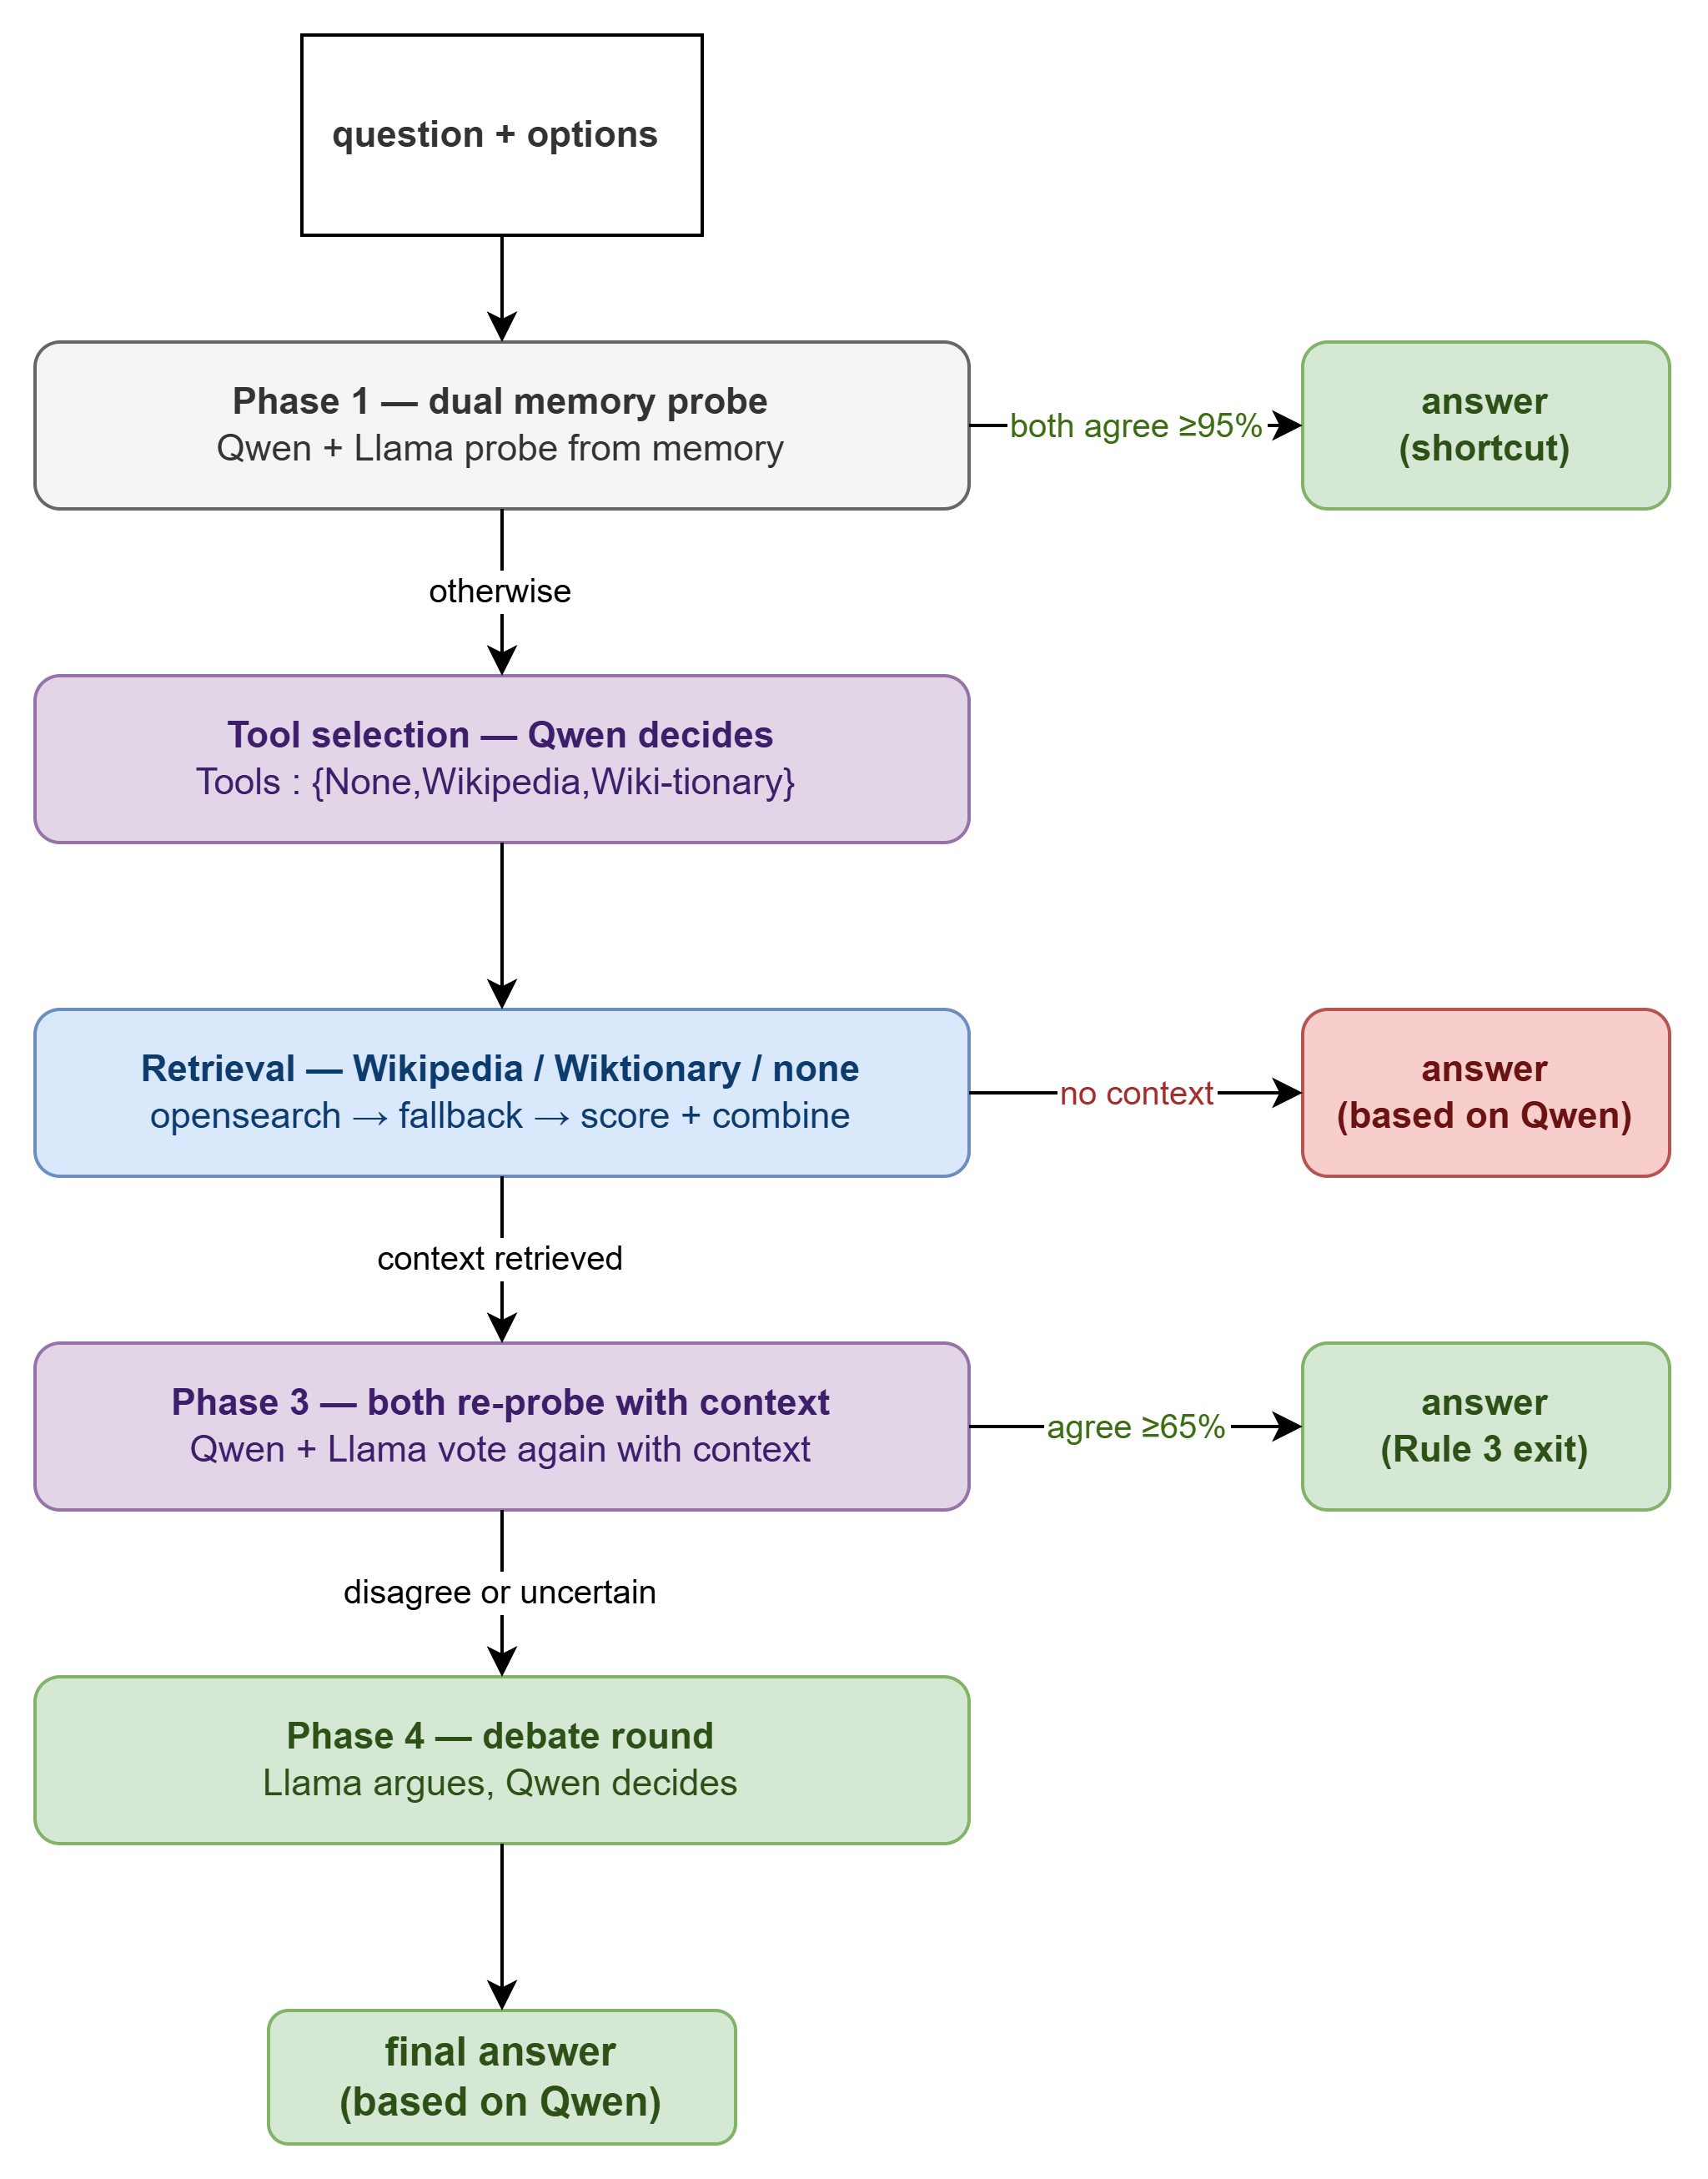

In [14]:
# ── Additional imports required by the RAG + LLM pipeline ─────────────────
import html
import json
import requests
from concurrent.futures import ThreadPoolExecutor, wait
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from typing import Optional


### 🔎 **1. RAG System**

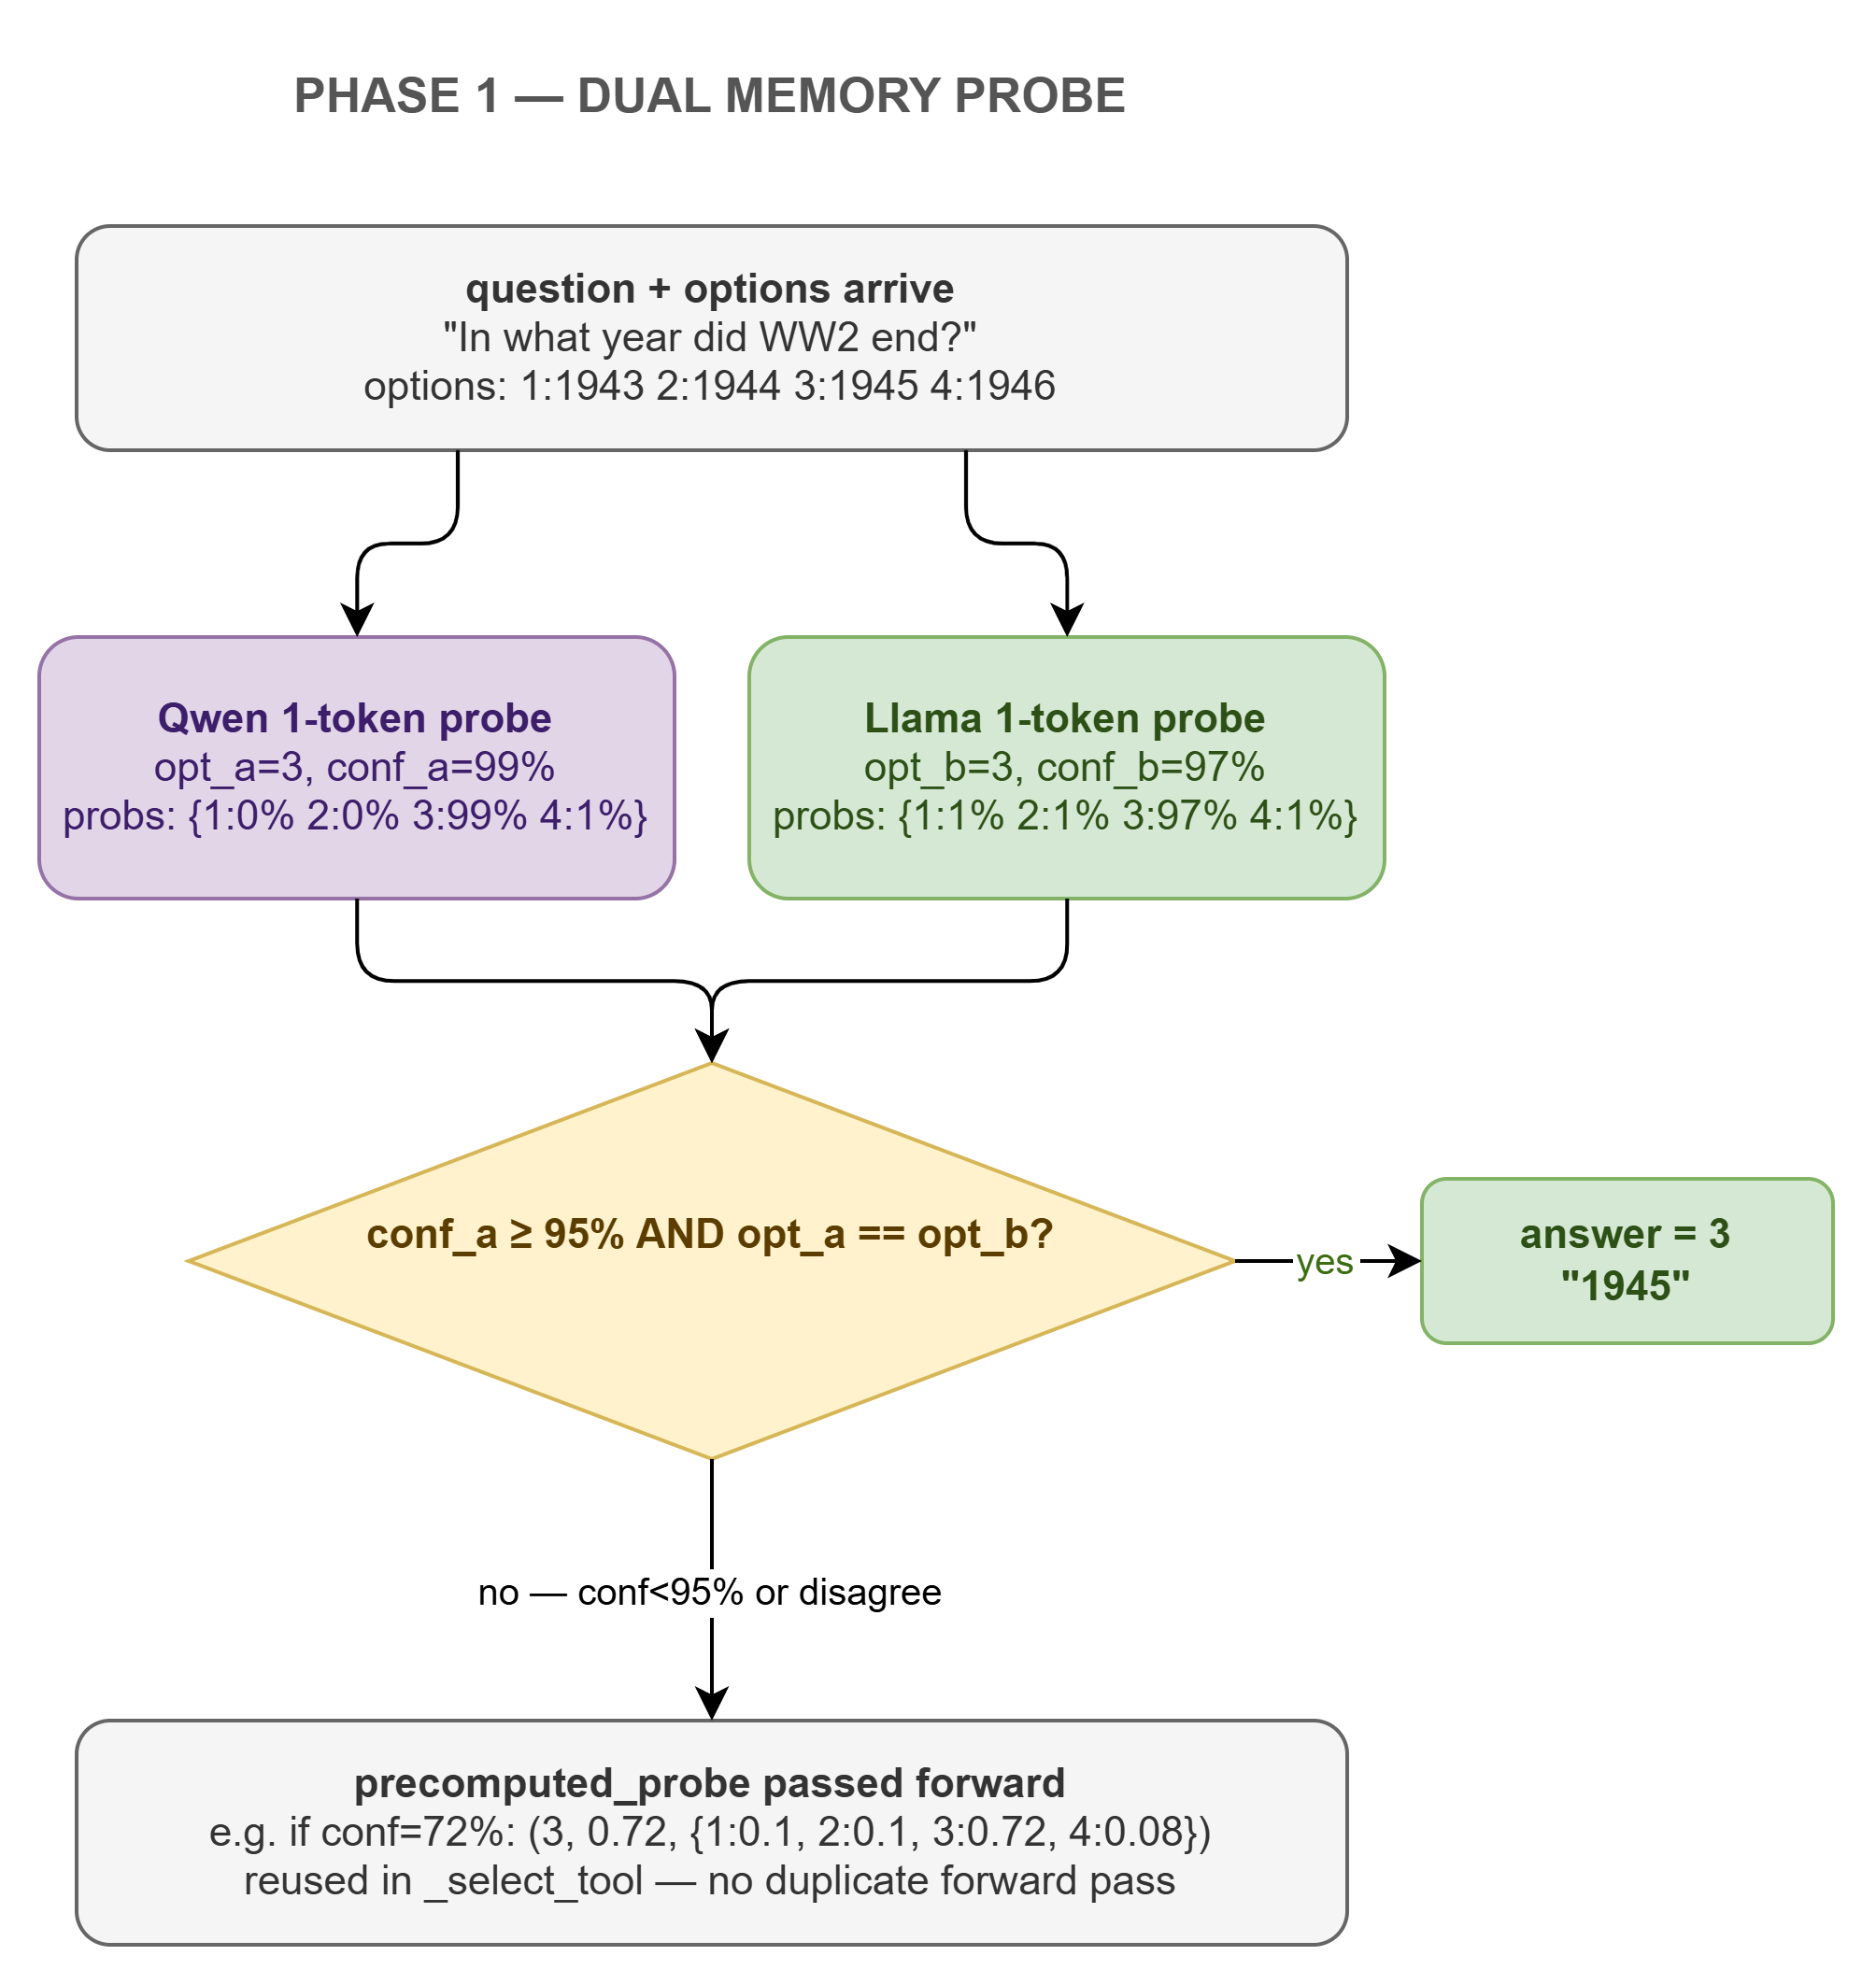

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# RAG System — Constants & Helper Functions (agentic mode only)
# ─────────────────────────────────────────────────────────────────────────────

_PARALLEL_TIMEOUT = 5.0    # seconds budget for parallel search phase
_MAX_CONTEXT_LEN  = 5000   # max chars of combined article text fed to the LLM
_MAX_ARTICLES     = 2      # top-2 most relevant articles (avoids "lost in the middle")
_WIKI_SENTENCES   = 25     # sentences per article summary fetched from Wikipedia
_MAX_WORKERS      = 4      # concurrent Wikipedia search calls (I/O-bound, safe for Colab)

_WIKI_API  = "https://en.wikipedia.org/w/api.php"
_WIKT_API  = "https://en.wiktionary.org/w/api.php"
_WIKI_HDRS = {"User-Agent": "PoliMillionaire-quiz/1.0 (educational NLP project)"}

_STOP_WORDS = frozenset({
    "what", "which", "how", "where", "when", "why", "who", "whom", "whose",
    "the", "a", "an",
    "of", "for", "to", "from", "by", "at", "in", "on", "into", "with",
    "about", "between", "among", "during", "after", "before",
    "and", "or", "but",
    "is", "are", "was", "were", "did", "does", "do", "have", "has", "had",
    "be", "been", "being", "would", "could", "should", "will", "can", "may",
    "might", "must", "used",
    "it", "its", "this", "that", "these", "those", "they", "them", "their",
    "he", "she", "his", "her", "we", "our", "you", "your",
    "also", "then", "than", "not", "no", "more", "most", "such", "very",
    "term", "refers", "refer", "using", "based", "given", "found", "known",
    "called", "named", "describes", "describe", "connection", "according",
    "following", "primary", "secondary", "fundamental", "best", "main",
    "whole", "general", "specific", "certain", "common",
    "times", "time", "year", "years", "century", "period",
    "article", "question", "option", "answer", "passage",
})


def _keywords(question: str) -> list:
    words = re.findall(r"[a-zA-Z]+", question.lower())
    return sorted({w for w in words if len(w) > 4 and w not in _STOP_WORDS})


def _proper_nouns(question: str) -> list:
    words = re.findall(r"\b[a-zA-Z]+\b", question)
    return [w.lower() for i, w in enumerate(words)
            if i > 0 and w[0].isupper() and len(w) >= 4]

def _is_relevant(question: str, context: str) -> bool:
    """Accept article if >= 50% of proper nouns appear in context, OR if any
    content keyword overlaps (including 4-char prefix stem fallback)."""
    c_lower = context.lower()
    proper  = _proper_nouns(question)
    if proper:
        matches = sum(1 for p in proper if p in c_lower)
        if matches / len(proper) >= 0.5:
            return True
    q_kw = set(_keywords(question))
    c_kw = set(_keywords(context))
    if q_kw & c_kw:
        return True
    q_stems = {w[:4] for w in q_kw if len(w) >= 5}
    c_stems = {w[:4] for w in c_kw if len(w) >= 5}
    return bool(q_stems & c_stems)


def _strip_html(raw: str) -> str:
    text = re.sub(r"<[^>]+>", " ", raw)
    text = html.unescape(text)
    return re.sub(r"\s+", " ", text).strip()

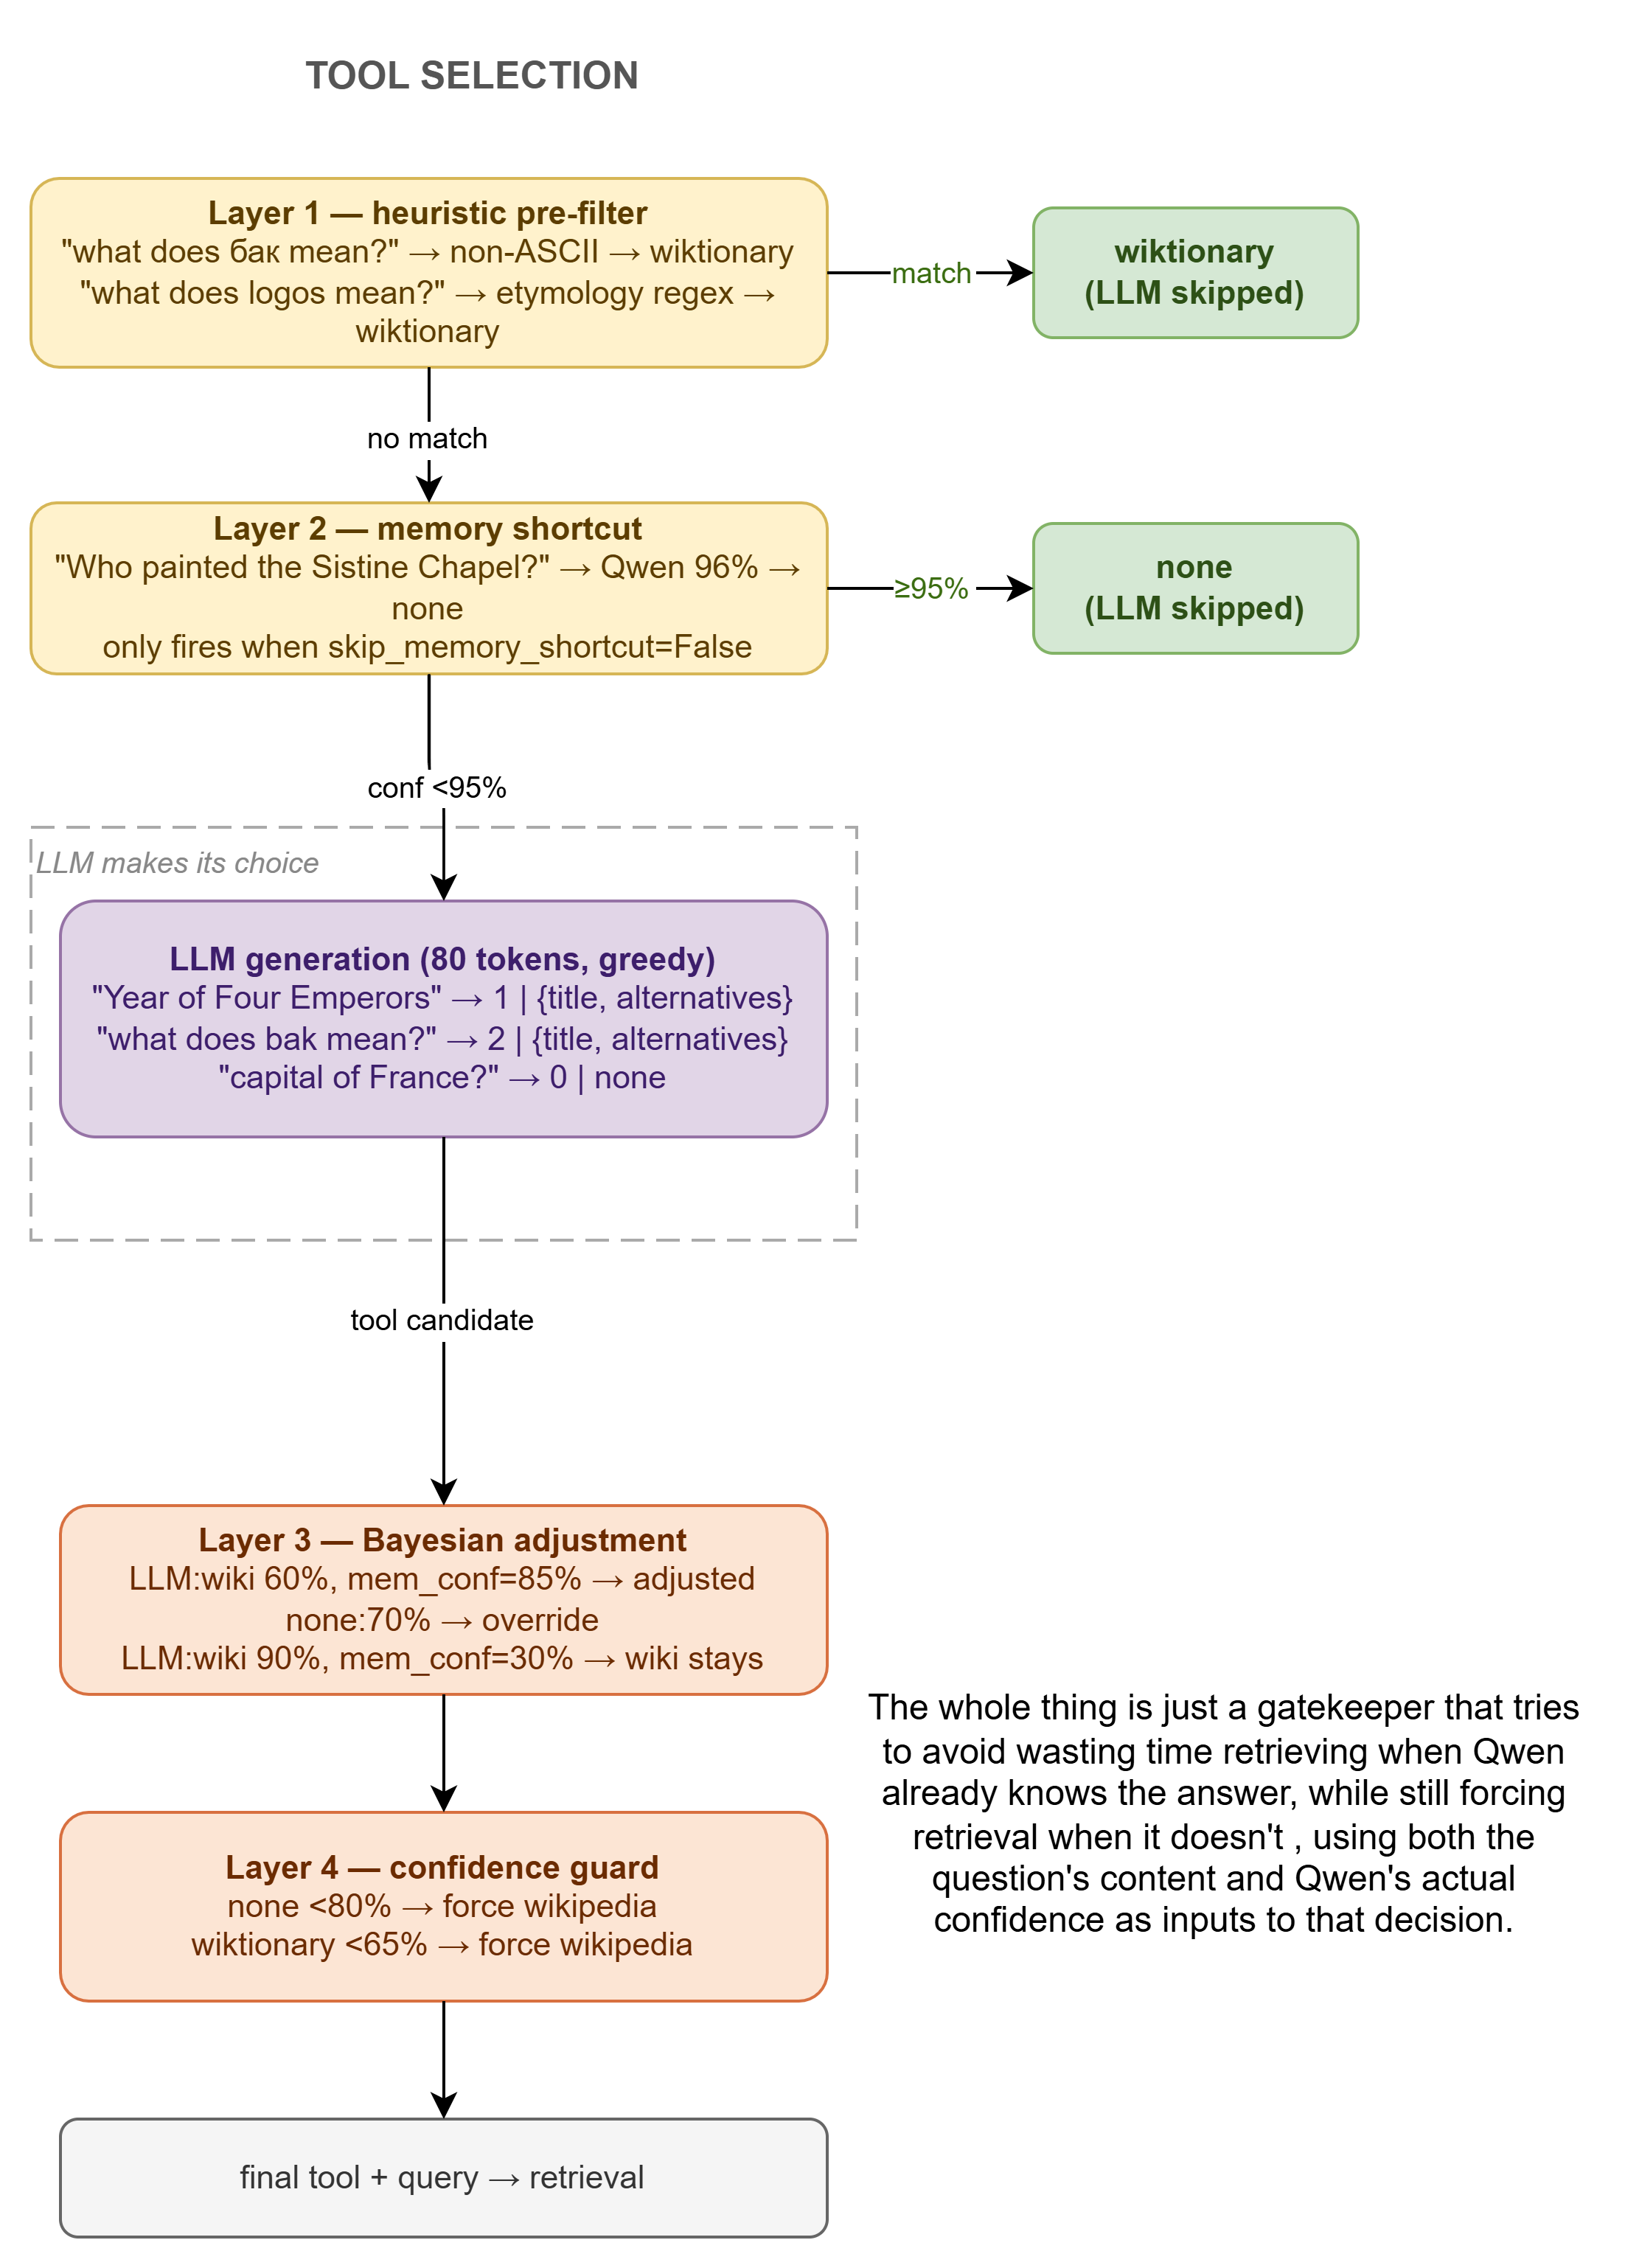

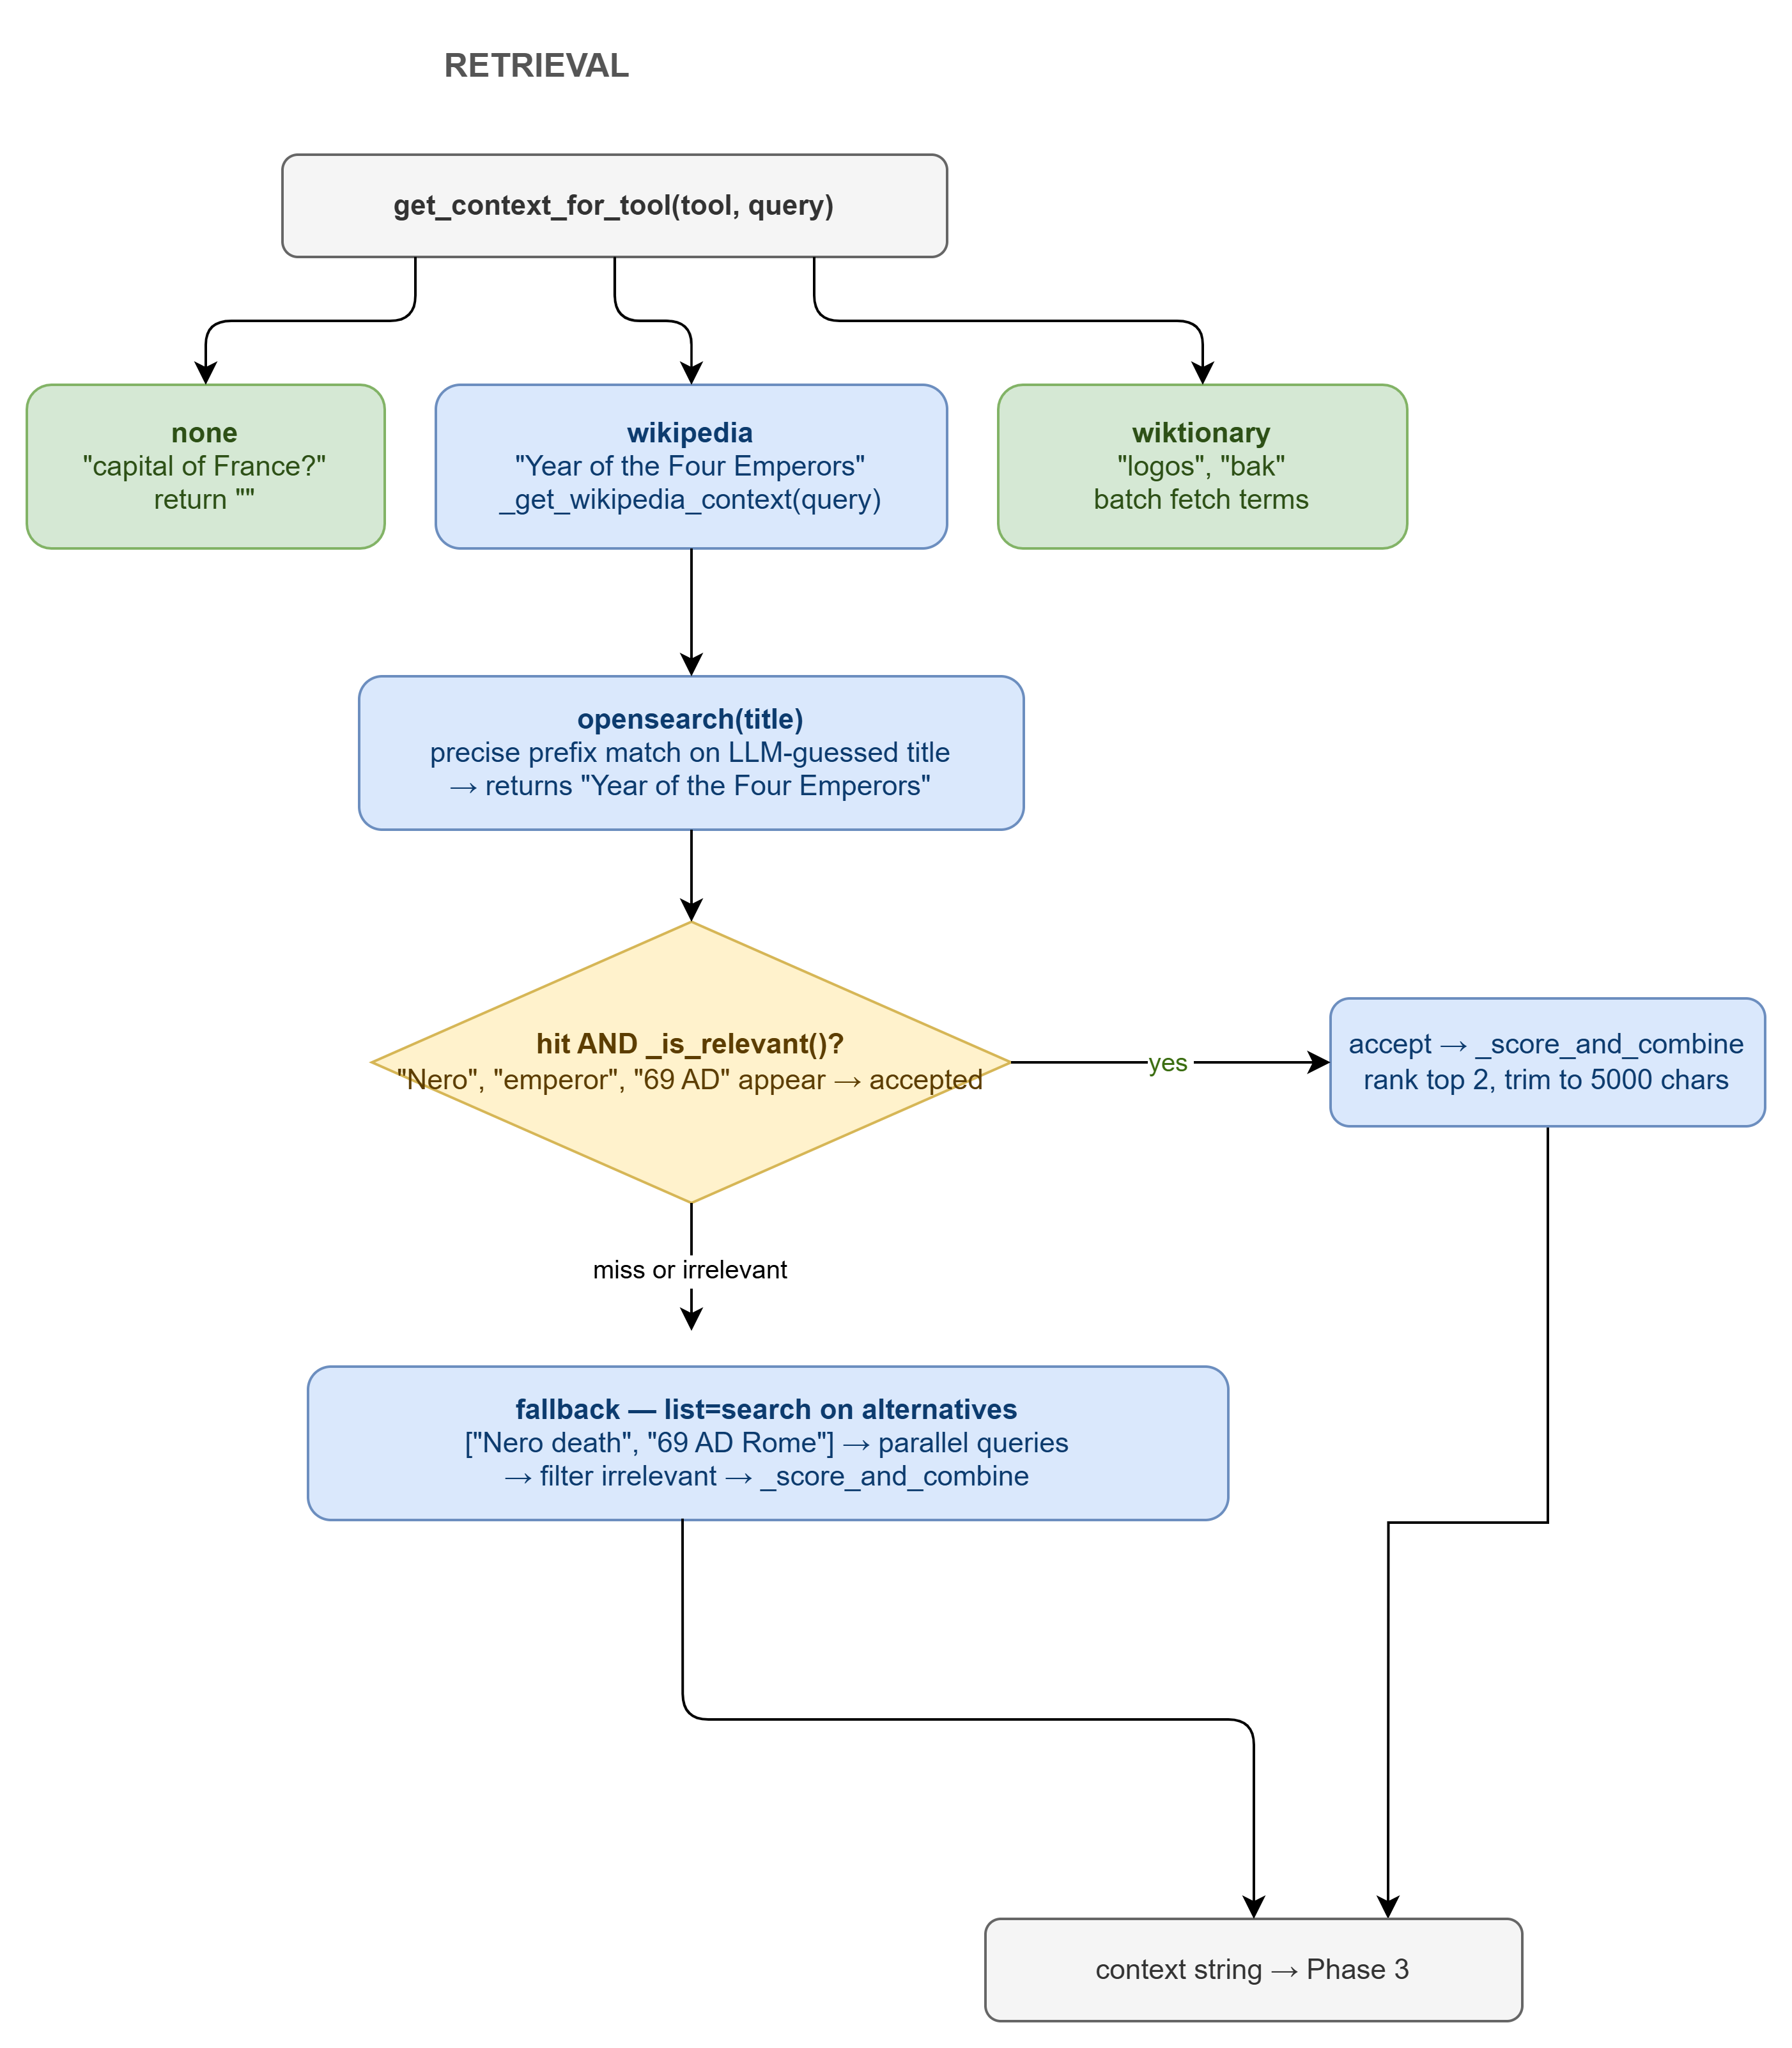

In [16]:
class Retriever:
    """Wikipedia + Wiktionary retrieval via the MediaWiki REST API.

    Agentic mode only. Query is always a dict {"title": ..., "alternatives": [...]}.

    Phase 1 — opensearch with the LLM-guessed title (title-prefix match).
    Phase 2 — full-text list=search with alternatives if Phase 1 misses.
    Total:  N + 1  API calls instead of 2N.
    """

    def __init__(self, log_fn=None):
        self._log = log_fn or (lambda msg: None)
        self._session = requests.Session()
        _retry = Retry(
            total=1, connect=0, read=1, backoff_factor=2.0,
            status_forcelist=[429, 500, 502, 503, 504],
            respect_retry_after_header=False,
        )
        self._session.mount("https://", HTTPAdapter(max_retries=_retry))
        self._session.headers.update(_WIKI_HDRS)

    # ── low-level API calls ────────────────────────────────────────────────

    def _search_titles(self, query: str, srlimit: int = 5):
        """list=search full-text search. Returns title list or None on error."""
        try:
            r = self._session.get(
                _WIKI_API,
                params={"action": "query", "list": "search",
                        "srsearch": query, "srlimit": srlimit, "format": "json"},
                timeout=3,
            )
            r.raise_for_status()
            return [hit["title"] for hit in r.json()["query"]["search"]]
        except Exception as e:
            self._log(f"WIKI SEARCH ERR  : {query!r} -> {e}")
            return None

    def _fetch_extracts(self, titles: list) -> dict:
        """Batch-fetch intro extracts for all titles in ONE API call."""
        if not titles:
            return {}
        try:
            r = self._session.get(
                _WIKI_API,
                params={"action": "query", "prop": "extracts",
                        "exintro": True, "exsentences": _WIKI_SENTENCES,
                        "titles": "|".join(titles[:50]),
                        "redirects": 1, "format": "json"},
                timeout=6,
            )
            r.raise_for_status()
            out = {}
            for pid, page in r.json()["query"]["pages"].items():
                if pid == "-1":
                    continue
                text = _strip_html(page.get("extract", ""))
                if text:
                    out[page.get("title", titles[0])] = text
            return out
        except Exception as e:
            self._log(f"WIKI EXTRACT ERR : {e}")
            return {}

    def _fetch_wiktionary(self, terms: list) -> dict:
        """Batch-fetch Wiktionary entries for the given terms."""
        if not terms:
            return {}
        try:
            r = self._session.get(
                _WIKT_API,
                params={"action": "query", "prop": "extracts",
                        "exsentences": 8, "titles": "|".join(terms[:10]),
                        "redirects": 1, "format": "json"},
                timeout=4,
            )
            r.raise_for_status()
            out = {}
            for pid, page in r.json()["query"]["pages"].items():
                if pid == "-1":
                    continue
                text = _strip_html(page.get("extract", ""))
                if text:
                    out[page.get("title", terms[0])] = text
            return out
        except Exception as e:
            self._log(f"WIKT EXTRACT ERR : {e}")
            return {}

    def _opensearch_title(self, title: str):
        """Resolve a guessed article title via Wikipedia's opensearch endpoint.
        Returns the best non-disambiguation title, or None on miss/error.
        """
        if not title:
            return None
        try:
            r = self._session.get(
                _WIKI_API,
                params={"action": "opensearch", "search": title,
                        "limit": 5, "namespace": 0, "format": "json"},
                timeout=3,
            )
            r.raise_for_status()
            data   = r.json()
            titles = data[1] if len(data) > 1 else []
            for t in titles:
                if t.lower() == title.lower():
                    return t
            for t in titles:
                if "(disambiguation)" not in t.lower():
                    return t
            return titles[0] if titles else None
        except Exception as e:
            self._log(f"OPENSEARCH ERR   : {title!r} -> {e}")
            return None

    def _run_queries(self, queries: list, srlimit: int = 5) -> tuple:
        """Run search queries in parallel, then batch-fetch all extracts.
        Returns (extracts: dict, had_error: bool).
        """
        if not queries:
            return {}, False
        with ThreadPoolExecutor(max_workers=_MAX_WORKERS) as ex:
            future_map = {ex.submit(self._search_titles, q, srlimit): q for q in queries}
            done, _    = wait(future_map.keys(), timeout=_PARALLEL_TIMEOUT)

        had_error = False
        seen_titles, ordered_titles = set(), []
        for fut in done:
            try:
                result = fut.result()
                if result is None:
                    had_error = True
                else:
                    for title in result:
                        if title not in seen_titles:
                            seen_titles.add(title)
                            ordered_titles.append(title)
            except Exception as e:
                had_error = True
                self._log(f"SEARCH ERROR     : {e}")

        if not ordered_titles:
            return {}, had_error
        self._log(f"WIKI TITLES      : {ordered_titles}")
        return self._fetch_extracts(ordered_titles), had_error

    def _score_and_combine(self, unique: list, question: str) -> str:
        """Score articles by relevance, keep top _MAX_ARTICLES, return combined string."""
        if not unique:
            return ""
        q_kw     = set(_keywords(question))
        q_proper = set(_proper_nouns(question))
        def _score(ctx):
            lower = ctx.lower()
            return (sum(1 for kw in q_kw if kw in lower)
                    + sum(2 for p in q_proper if p in lower))
        unique.sort(key=_score, reverse=True)
        unique   = unique[:_MAX_ARTICLES]
        combined = "\n\n---\n\n".join(unique)[:_MAX_CONTEXT_LEN]
        self._log(f"CONTEXT READY    : {len(unique)} source(s), {len(combined)} chars")
        return combined

    # ── individual tool methods ───────────────────────────────────────────

    def _get_wikipedia_context(self, question: str, options: dict, query: dict) -> str:
        """Wikipedia retrieval. query is always a dict {"title": ..., "alternatives": [...]}.

        Phase 1 — opensearch with LLM-guessed title (precise title match).
        Phase 2 — list=search with alternatives if Phase 1 misses or returns
                  an irrelevant article.
        """
        title        = query.get("title", "").strip()
        alternatives = [a for a in query.get("alternatives", []) if a.strip()]

        matched = self._opensearch_title(title) if title else None
        if matched:
            self._log(f"OPENSEARCH HIT   : {matched!r}")
            extracts  = self._fetch_extracts([matched])
            seen_text, unique = set(), []
            for t, ctx in extracts.items():
                if ctx[:80] not in seen_text and _is_relevant(question, ctx):
                    seen_text.add(ctx[:80])
                    unique.append(ctx)
                    self._log(f"WIKI ACCEPTED    : [{t}]")
                elif ctx[:80] not in seen_text:
                    self._log(f"WIKI REJECTED    : [{t}] (relevance too low)")
            if unique:
                return self._score_and_combine(unique, question)
            self._log("OPENSEARCH MISS  : not relevant -> trying alternatives")
        else:
            self._log(f"OPENSEARCH MISS  : no title match for {title!r}")

        fallback = alternatives or ([title] if title else [])
        if not fallback:
            return ""
        self._log(f"WIKI FALLBACK    : {fallback}")
        extracts, _ = self._run_queries(fallback, srlimit=3)
        seen_text, unique = set(), []
        for t, ctx in extracts.items():
            if ctx[:80] not in seen_text:
                if _is_relevant(question, ctx):
                    seen_text.add(ctx[:80])
                    unique.append(ctx)
                    self._log(f"WIKI ACCEPTED    : [{t}]")
                else:
                    self._log(f"WIKI REJECTED    : [{t}] (relevance too low)")
        return self._score_and_combine(unique, question)

    def _get_wiktionary_context(self, question: str, options: dict, query: dict) -> str:
        """Wiktionary lookup — best for word definitions and etymology."""
        terms = [query.get("title", "")] + query.get("alternatives", [])
        terms = [t.strip() for t in terms if t.strip()]
        self._log(f"WIKT LOOKUP      : {terms}")
        wikt_extracts = self._fetch_wiktionary(terms)
        unique, seen_text = [], set()
        for title, ctx in wikt_extracts.items():
            if ctx[:80] not in seen_text:
                seen_text.add(ctx[:80])
                unique.append(ctx)
                self._log(f"WIKT ACCEPTED    : [{title}]")
        if not unique:
            self._log("WIKT             : no entries found")
        return self._score_and_combine(unique, question)

    def get_context_for_tool(self, tool: str, question: str,
                             options: dict = None, query: dict = None) -> str:
        """Route retrieval to a named tool using the LLM-generated dict query.

        tool  : 'none' | 'wikipedia' | 'wiktionary'
        query : dict {"title": ..., "alternatives": [...]} or None
        """
        options = options or {}
        if tool == "none":
            self._log("TOOL ROUTE       : memory (no retrieval)")
            return ""
        if tool == "wikipedia":
            self._log("TOOL ROUTE       : wikipedia")
            return self._get_wikipedia_context(question, options, query or {})
        if tool == "wiktionary":
            self._log("TOOL ROUTE       : wiktionary")
            return self._get_wiktionary_context(question, options, query or {})
        self._log(f"TOOL ROUTE       : unknown '{tool}' -> no retrieval")
        return ""

### 🔗 **2. Pipeline**

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# LLM Pipeline — System Prompts, Tool-Selection Constants & Helper Functions
# ─────────────────────────────────────────────────────────────────────────────

SYSTEM_PROMPTS = {
    "default": (
        "You are a quiz contestant. Given a multiple choice question, "
        "reply with ONLY the number of the correct option. No explanation."
    ),
    "retrieval": (
        "You are a quiz contestant. Given a multiple choice question and optional web context, "
        "reply with ONLY the number of the correct option. No explanation."
    ),
}

TOOL_QUERY_PROMPT = (
    "You are selecting an information source and writing a search query for a quiz question.\n\n"
    "Sources:\n"
    "  0 = memory      — answer from your own knowledge (no search needed)\n"
    "  1 = wikipedia   — encyclopedia: historical events, people, places, cultural practices\n"
    "  2 = wiktionary  — word definitions and etymology ONLY (NOT historical/cultural facts)\n\n"
    "IMPORTANT: use wiktionary ONLY when the question asks what a word or term MEANS "
    "linguistically — NOT for facts about a historical entity, person, or event.\n\n"
    "You will see the answer options. Use them ONLY to identify the topic domain "
    "(e.g. if options are Egyptian period names, search Egypt). "
    "Do NOT write a query that searches for one specific option — write a neutral "
    "query about the underlying concept in the question.\n\n"
    'Reply on ONE line:  <digit> | {"title": "<most likely article title>", "alternatives": ["<alt1>", "<alt2>"]}\n'
    "For digit=0 write:  0 | none\n\n"
    "Examples:\n"
    '  1 | {"title": "Roman salute", "alternatives": ["fascist salute history", "Mussolini arm gesture"]}\n'
    '  2 | {"title": "logos", "alternatives": ["logos Greek etymology", "logos meaning"]}\n'
    "  0 | none"
)

_TOOL_MAP  = {"0": "none", "1": "wikipedia", "2": "wiktionary"}

_TOOL_MIN_CONF             = {"none": 0.80, "wiktionary": 0.65}
_MEMORY_SHORTCUT_THRESHOLD = 0.95
_DTYPE_MAP = {"bfloat16": torch.bfloat16, "float16": torch.float16, "float32": torch.float32}
_SEP  = "=" * 64
_DASH = "-" * 64


def _bayesian_adjust(prob_dict: dict, mem_conf: float) -> dict:
    p_none = prob_dict.get("none", 0.0) / 100
    p_rest = 1.0 - p_none
    unnorm_none = p_none * mem_conf
    unnorm_rest = p_rest * (1.0 - mem_conf)
    total = unnorm_none + unnorm_rest
    if total == 0:
        return dict(prob_dict)
    adj_none   = unnorm_none / total
    rest_scale = (unnorm_rest / total) / p_rest if p_rest > 0 else 0.0
    return {
        "none":       round(adj_none * 100, 1),
        "wikipedia":  round(prob_dict.get("wikipedia",  0) / 100 * rest_scale * 100, 1),
        "wiktionary": round(prob_dict.get("wiktionary", 0) / 100 * rest_scale * 100, 1),
    }


_HEURISTIC_QUOTED_RE = re.compile(
    r"(?:the\s+)?(?:term|word|concept|phrase|name)\s+[\'\'\u2018\u2019\u201c\u201d]([^\'\'\u2018\u2019\u201c\u201d]+)[\'\'\u2018\u2019\u201c\u201d]"
    r"|[\'\'\u2018\u2019\u201c\u201d]([^\'\'\u2018\u2019\u201c\u201d]{1,40})[\'\'\u2018\u2019\u201c\u201d]",
    re.IGNORECASE,
)
_WIKT_ETYMOLOGY_RE = re.compile(
    r"\bwhat\s+does\b.*\bmean\b|\bwhat\s+is\s+the\s+meaning\s+of\b"
    r"|\bfrom\s+(?:the\s+)?(?:greek|latin|hebrew|arabic|french|german|italian|spanish)\s+(?:word|term|phrase|root)\b"
    r"|\betymolog|\bwhich\s+(?:term|word|phrase)\s+(?:refers|means|denotes|signifies)\b",
    re.IGNORECASE,
)
_LATIN_GREEK_SUFFIX_RE = re.compile(
    r"(?:us|um|ae|orum|ibus|atio|ius|eum|eus|alis|oris|inis|ens|icis"
    r"|ikos|logos|osis|itis|polis|phile|phobia|nomy|cracy|arche|kratos)$",
    re.IGNORECASE,
)
_WIKT_TRANSLATE_RE = re.compile(r"\btranslates?\s+(?:to|from|as)\b", re.IGNORECASE)


def _parse_tool_query(raw: str) -> tuple:
    raw = raw.strip()
    if "|" in raw:
        digit_part, query_part = raw.split("|", 1)
        digit     = digit_part.strip().strip(".,!?:;")
        query_str = query_part.strip()
    else:
        digit     = raw.split()[0].strip(".,!?:;") if raw else ""
        query_str = ""
    tool = _TOOL_MAP.get(digit, "wikipedia")
    if not query_str or query_str.lower() in ("none", "-", "n/a"):
        return tool, None
    try:
        data = json.loads(query_str)
        if isinstance(data, dict) and "title" in data:
            return tool, {
                "title":        str(data.get("title", "")).strip(),
                "alternatives": [str(a).strip() for a in data.get("alternatives", []) if a],
            }
    except (json.JSONDecodeError, ValueError):
        pass
    return tool, query_str


def _extract_quoted(question: str) -> list:
    seen, out = set(), []
    for m in _HEURISTIC_QUOTED_RE.finditer(question):
        term = (m.group(1) or m.group(2) or "").strip()
        if term and term.lower() not in seen:
            seen.add(term.lower())
            out.append(term)
    return out


def _heuristic_tool(question: str) -> Optional[str]:
    quoted = _extract_quoted(question)
    for term in quoted:
        if any(ord(c) > 127 for c in term):
            return "wiktionary"
    if _WIKT_ETYMOLOGY_RE.search(question):
        return "wiktionary"
    if quoted and _WIKT_TRANSLATE_RE.search(question):
        return "wiktionary"
    for term in quoted:
        if _LATIN_GREEK_SUFFIX_RE.search(term.strip().split()[-1]):
            return "wiktionary"
    return None

In [18]:

# ─────────────────────────────────────────────────────────────────────────────
# LLMModel
# ─────────────────────────────────────────────────────────────────────────────

class LLMModel:
    """Generic HuggingFace causal LLM for the PoliMillionaire quiz.

    Supports three modes: plain (no retrieval), Wikipedia waterfall, and
    agentic (LLM selects tool + writes JSON query -> opensearch -> answer).
    """

    def __init__(
        self,
        model_name: str,
        do_sample: bool = True,
        temperature: Optional[float] = 0.15,
        max_new_tokens: int = 10,
        system_prompt: str = "default",
        search_reversed: bool = False,
        quantization: Optional[dict] = None,
        use_retrieval: bool = False,
        use_dense_retrieval: bool = False,
        use_hybrid_retrieval: bool = False,
        use_tool_selection: bool = False,
        repetition_penalty: Optional[float] = None,
    ):
        try:
            from utils.HF_login import HF_login
            HF_login()
        except (ImportError, Exception):
            pass

        from transformers import logging as hf_logging
        hf_logging.set_verbosity_error()

        random.seed(42); np.random.seed(42)
        torch.manual_seed(42); torch.cuda.manual_seed_all(42)

        self._model_name         = model_name
        self._do_sample          = do_sample
        self._temperature        = temperature
        self._max_new_tokens     = max_new_tokens
        self._search_reversed     = search_reversed
        self._repetition_penalty  = repetition_penalty
        self._use_tool_selection  = use_tool_selection and use_retrieval

        if use_hybrid_retrieval:
            from utils.retrieval import HybridDenseRetriever
            self._retriever     = HybridDenseRetriever()
            self._system_prompt = SYSTEM_PROMPTS.get(system_prompt, system_prompt) if system_prompt != "default" else SYSTEM_PROMPTS["retrieval"]
        elif use_dense_retrieval:
            from utils.retrieval import DenseRetriever
            self._retriever     = DenseRetriever()
            self._system_prompt = SYSTEM_PROMPTS.get(system_prompt, system_prompt) if system_prompt != "default" else SYSTEM_PROMPTS["retrieval"]
        elif use_retrieval:
            self._retriever     = Retriever(log_fn=self._log)
            self._system_prompt = (
                SYSTEM_PROMPTS.get(system_prompt, system_prompt)
                if system_prompt != "default"
                else SYSTEM_PROMPTS["retrieval"]
            )
        else:
            self._retriever     = None
            self._system_prompt = SYSTEM_PROMPTS.get(system_prompt, system_prompt)

        if quantization:
            self._quantization_config = BitsAndBytesConfig(
                load_in_4bit=quantization.get("load_in_4bit", False),
                bnb_4bit_quant_type=quantization.get("quant_type", "nf4"),
                bnb_4bit_compute_dtype=_DTYPE_MAP.get(
                    quantization.get("compute_dtype", "bfloat16"), torch.bfloat16),
                bnb_4bit_use_double_quant=quantization.get("double_quant", True),
            )
        else:
            self._quantization_config = None

        kwargs = dict(device_map="auto", trust_remote_code=True)
        if self._quantization_config is not None:
            kwargs["quantization_config"] = self._quantization_config
        else:
            kwargs["torch_dtype"] = "auto"

        model     = AutoModelForCausalLM.from_pretrained(model_name, **kwargs)
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

        self.debug         = False
        self._log_file     = None
        self._log_path     = None
        self._question_num = 0
        self._game_info    = ""
        self._last_options: dict = {}

    # ── logging ───────────────────────────────────────────────────────────

    def _setup_logger(self):
        import os
        from datetime import datetime
        os.makedirs("logs", exist_ok=True)
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        log_path  = f"logs/{self._model_name.split('/')[-1]}_{timestamp}.log"
        self._log_file = open(log_path, "w", encoding="utf-8")
        self._log_path = log_path
        self._log_file.write(_SEP + "\n")
        self._log_file.write("PoliMillionaire Debug Log\n")
        self._log_file.write(f"{'Model':<10}: {self._model_name}\n")
        mode_tag = 'agentic' if self._use_tool_selection else ('retrieval' if self._retriever else 'plain')
        self._log_file.write(f"{'Mode':<10}: {mode_tag}\n")
        self._log_file.write(_SEP + "\n\n")
        self._log_file.flush()
        print(f"[LLM] Debug log -> {log_path}")

    def _log(self, msg: str):
        if not self.debug:
            return
        if self._log_file is None:
            self._setup_logger()
        self._log_file.write(msg + "\n")
        self._log_file.flush()

    def start_game(self, competition_name: str = ""):
        self._question_num = 0
        self._game_info    = competition_name

    # ── core inference primitives ─────────────────────────────────────────

    def _probe_memory(self, question_text: str, options: dict,
                      context: str = "") -> tuple:
        """Single-token forward pass: P(option | question [+ context]).
        Returns (best_option_key, best_confidence, full_prob_dict).
        """
        options_str = "\n".join(f"{k}: {v}" for k, v in options.items())
        if context:
            user_content = (f"Context from web search:\n{context}\n\n"
                            f"Question: {question_text}\n\nOptions:\n{options_str}\n\n"
                            "Reply with only the option number.")
            sys_prompt = SYSTEM_PROMPTS["retrieval"]
        else:
            user_content = (f"Question: {question_text}\n\nOptions:\n{options_str}\n\n"
                            "Reply with only the option number.")
            sys_prompt = SYSTEM_PROMPTS["default"]
        messages = [{"role": "system", "content": sys_prompt},
                    {"role": "user",   "content": user_content}]
        text   = self.pipe.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        inputs = self.pipe.tokenizer(text, return_tensors="pt")
        device = next(self.pipe.model.parameters()).device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = self.pipe.model.generate(
                **inputs, max_new_tokens=1,
                output_scores=True, return_dict_in_generate=True, do_sample=False)
        first_logits = out.scores[0][0]
        opt_ids = {}
        for k in options:
            ids = self.pipe.tokenizer.encode(str(k), add_special_tokens=False)
            if ids:
                opt_ids[str(k)] = ids[-1]
        if not opt_ids:
            return None, 0.0, {}
        keys       = list(opt_ids.keys())
        opt_logits = torch.stack([first_logits[opt_ids[k]] for k in keys])
        probs      = torch.softmax(opt_logits, dim=0)
        best_i     = probs.argmax().item()
        prob_dict  = {k: probs[i].item() for i, k in enumerate(keys)}
        return keys[best_i], probs[best_i].item(), prob_dict

    def _select_tool(self, question_text: str, options: dict,
                     skip_memory_shortcut: bool = False,
                     precomputed_probe: tuple = None) -> tuple:
        """Pick retrieval source + write search query.

        Decision flow:
          1. Heuristic pre-filter  (wiktionary for definitions — no LLM call)
          2. Memory probe          (1-token forward pass)
          3. LLM tool+query call   (30 tokens, JSON output)
          4. Bayesian adjustment   (blend tool probs with memory confidence)
          5. Confidence guard      (low-confidence picks fall back to wikipedia)
        Returns (source_tag, tool, query, mem_option, mem_probs).
        """
        hint = _heuristic_tool(question_text)
        if hint is not None:
            return "heuristic", hint, None, None, {}

        if precomputed_probe is not None:
            mem_option, mem_conf, mem_probs = precomputed_probe
        else:
            mem_option, mem_conf, mem_probs = self._probe_memory(question_text, options)
        self._log(f"{'MEMORY PROBE':<17}: option={mem_option} conf={mem_conf:.0%}")

        if not skip_memory_shortcut and mem_conf >= _MEMORY_SHORTCUT_THRESHOLD:
            return f"memory-shortcut(conf={mem_conf:.0%})", "none", None, mem_option, mem_probs

        options_str = "\n".join(f"  {k}: {v}" for k, v in options.items())
        messages = [{"role": "system", "content": TOOL_QUERY_PROMPT},
                    {"role": "user",   "content": f"Question: {question_text}\n\nOptions:\n{options_str}"}]
        text   = self.pipe.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        inputs = self.pipe.tokenizer(text, return_tensors="pt")
        device = next(self.pipe.model.parameters()).device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = self.pipe.model.generate(
                **inputs, max_new_tokens=80,
                output_scores=True, return_dict_in_generate=True, do_sample=False)
        input_len = inputs["input_ids"].shape[1]
        raw = self.pipe.tokenizer.decode(
            out.sequences[0, input_len:], skip_special_tokens=True).strip()

        first_logits = out.scores[0][0]
        digit_ids = {}
        for d in "012":
            ids = self.pipe.tokenizer.encode(d, add_special_tokens=False)
            if ids:
                digit_ids[d] = ids[-1]
        _DIGITS = "012"
        if len(digit_ids) == len(_DIGITS):
            digit_logits = torch.stack([first_logits[digit_ids[d]] for d in _DIGITS])
            d_probs      = torch.softmax(digit_logits, dim=0)
            best_i       = d_probs.argmax().item()
            best_prob    = d_probs[best_i].item()
            prob_dict    = {_TOOL_MAP[d]: round(d_probs[i].item() * 100, 1)
                            for i, d in enumerate(_DIGITS)}
        else:
            d_probs, prob_dict, best_prob, best_i = None, None, 1.0, 1

        tool, query = _parse_tool_query(raw)
        if d_probs is not None:
            best_digit = _DIGITS[best_i]
            if _TOOL_MAP.get(best_digit) != tool:
                tool = _TOOL_MAP.get(best_digit, "wikipedia")

        if prob_dict is not None:
            self._log(f"{'TOOL PROBS':<17}: {'  '.join(f'{k}:{v}%' for k, v in prob_dict.items())}")
            if skip_memory_shortcut:
                tool = max(prob_dict, key=prob_dict.get)
                best_prob = prob_dict[tool] / 100
            else:
                adj  = _bayesian_adjust(prob_dict, mem_conf)
                tool = max(adj, key=adj.get)
                best_prob = adj[tool] / 100

        min_conf = _TOOL_MIN_CONF.get(tool, 0.0)
        if best_prob < min_conf:
            tool = "wikipedia"

        return raw, tool, query, mem_option, mem_probs

    def _generate(self, question_text: str, options: dict,
                  context: str = "", mem_bias: str = None) -> tuple:
        options_str = "\n".join(f"{id}: {text}" for id, text in options.items())
        if context:
            bias_note = ""
            if mem_bias is not None:
                ctx_lower = context.lower()
                if any(v.lower() in ctx_lower for v in options.values()):
                    bias_label = options.get(str(mem_bias), "?")
                    bias_note  = (f"- Your answer without context was option {mem_bias} "
                                  f"({bias_label}). This is likely a memorised bias — "
                                  f"do NOT default to it. Re-read the context and reconsider.\n")
            user_content = (
                f"Context from web search:\n{context}\n\n"
                f"Question: {question_text}\n\nOptions:\n{options_str}\n\n"
                "Read the context carefully, then follow these rules:\n"
                "- If any option word appears in the context as a synonym, definition, or equivalent, choose it.\n"
                "- Trust the context over your own knowledge.\n"
                f"{bias_note}"
                "Reply with only the option number."
            )
        else:
            user_content = (f"Question: {question_text}\n\nOptions:\n{options_str}\n\n"
                            "Reply with only the option number.")
        messages = [{"role": "system", "content": self._system_prompt},
                    {"role": "user",   "content": user_content}]
        text   = self.pipe.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        inputs = self.pipe.tokenizer(text, return_tensors="pt")
        device = next(self.pipe.model.parameters()).device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        gen_kwargs = dict(max_new_tokens=self._max_new_tokens,
                          output_scores=True, return_dict_in_generate=True,
                          do_sample=self._do_sample)
        if self._do_sample and self._temperature is not None:
            gen_kwargs["temperature"] = self._temperature
        with torch.no_grad():
            out = self.pipe.model.generate(**inputs, **gen_kwargs)
        input_len = inputs["input_ids"].shape[1]
        response  = self.pipe.tokenizer.decode(
            out.sequences[0, input_len:], skip_special_tokens=True).strip()
        prob_dict = {}
        if out.scores:
            first_logits = out.scores[0][0]
            opt_ids = {}
            for k in options:
                ids = self.pipe.tokenizer.encode(str(k), add_special_tokens=False)
                if ids:
                    opt_ids[str(k)] = ids[-1]
            if opt_ids:
                keys       = list(opt_ids.keys())
                opt_logits = torch.stack([first_logits[opt_ids[k]] for k in keys])
                probs      = torch.softmax(opt_logits, dim=0)
                prob_dict  = {k: round(probs[i].item() * 100, 1) for i, k in enumerate(keys)}
        return response, prob_dict

    def _parse_token(self, response: str, options: dict) -> int:
        tokens = list(reversed(response.split())) if self._search_reversed else response.split()
        for token in tokens:
            token = token.strip(".,!?")
            if token in options:
                return int(token)
        return int(next(iter(options)))

    def _prepare(self, question_text: str, options: dict) -> tuple:
        if self._retriever:
            if self._use_tool_selection:
                source_tag, tool, query, mem_option, mem_probs = self._select_tool(question_text, options)
                if source_tag == "heuristic":
                    self._log(f"{'TOOL SELECT':<17}: heuristic -> {tool}")
                elif source_tag.startswith("memory-shortcut"):
                    self._log(f"{'TOOL SELECT':<17}: {source_tag} -> none")
                else:
                    self._log(f"{'TOOL SELECT':<17}: llm={source_tag!r} -> {tool}")
                    if isinstance(query, dict):
                        self._log(f"{'QUERY TITLE':<17}: {query.get('title')!r}")
                        if query.get("alternatives"):
                            self._log(f"{'QUERY ALTS':<17}: {query['alternatives']}")
                    elif query:
                        self._log(f"{'QUERY (LLM)':<17}: {query!r}")
                context = self._retriever.get_context_for_tool(tool, question_text, options, query=query)
            else:
                self._log(f"{'RETRIEVAL MODE':<17}: waterfall")
                context    = self._retriever.get_context(question_text, options)
                mem_option = None
        else:
            context    = ""
            mem_option = None
        self._log(f"{'CONTEXT':<17}: {f'{len(context)} chars' if context else '(none)'}")
        return context, options, mem_option

    def answer(self, question_text: str, options: dict) -> int:
        self._question_num += 1
        self._last_options  = options
        self._log(_SEP)
        self._log(f"Q #{self._question_num:>3}  [{self._game_info}]")
        self._log(f"{'QUESTION':<17}: {question_text}")
        self._log(f"{'OPTIONS':<17}: {'  '.join(f'{k}: {v}' for k, v in options.items())}")
        self._log("")
        context, surviving, mem_bias = self._prepare(question_text, options)
        response, answer_probs = self._generate(question_text, surviving, context, mem_bias=mem_bias)
        answer = self._parse_token(response, options)
        self._log(f"{'ANSWER':<17}: {answer} -> {options.get(str(answer), '?')}")
        return answer

    def record_outcome(self, correct_answer: int, is_correct: bool):
        if not self.debug or self._log_file is None:
            return
        correct_text = self._last_options.get(str(correct_answer), "?")
        self._log_file.write(f"{'CORRECT ANS':<17}: {correct_answer} -> {correct_text}\n")
        self._log_file.write(f"{'RESULT':<17}: {'CORRECT' if is_correct else 'WRONG'}\n")
        self._log_file.write(_DASH + "\n\n")
        self._log_file.flush()

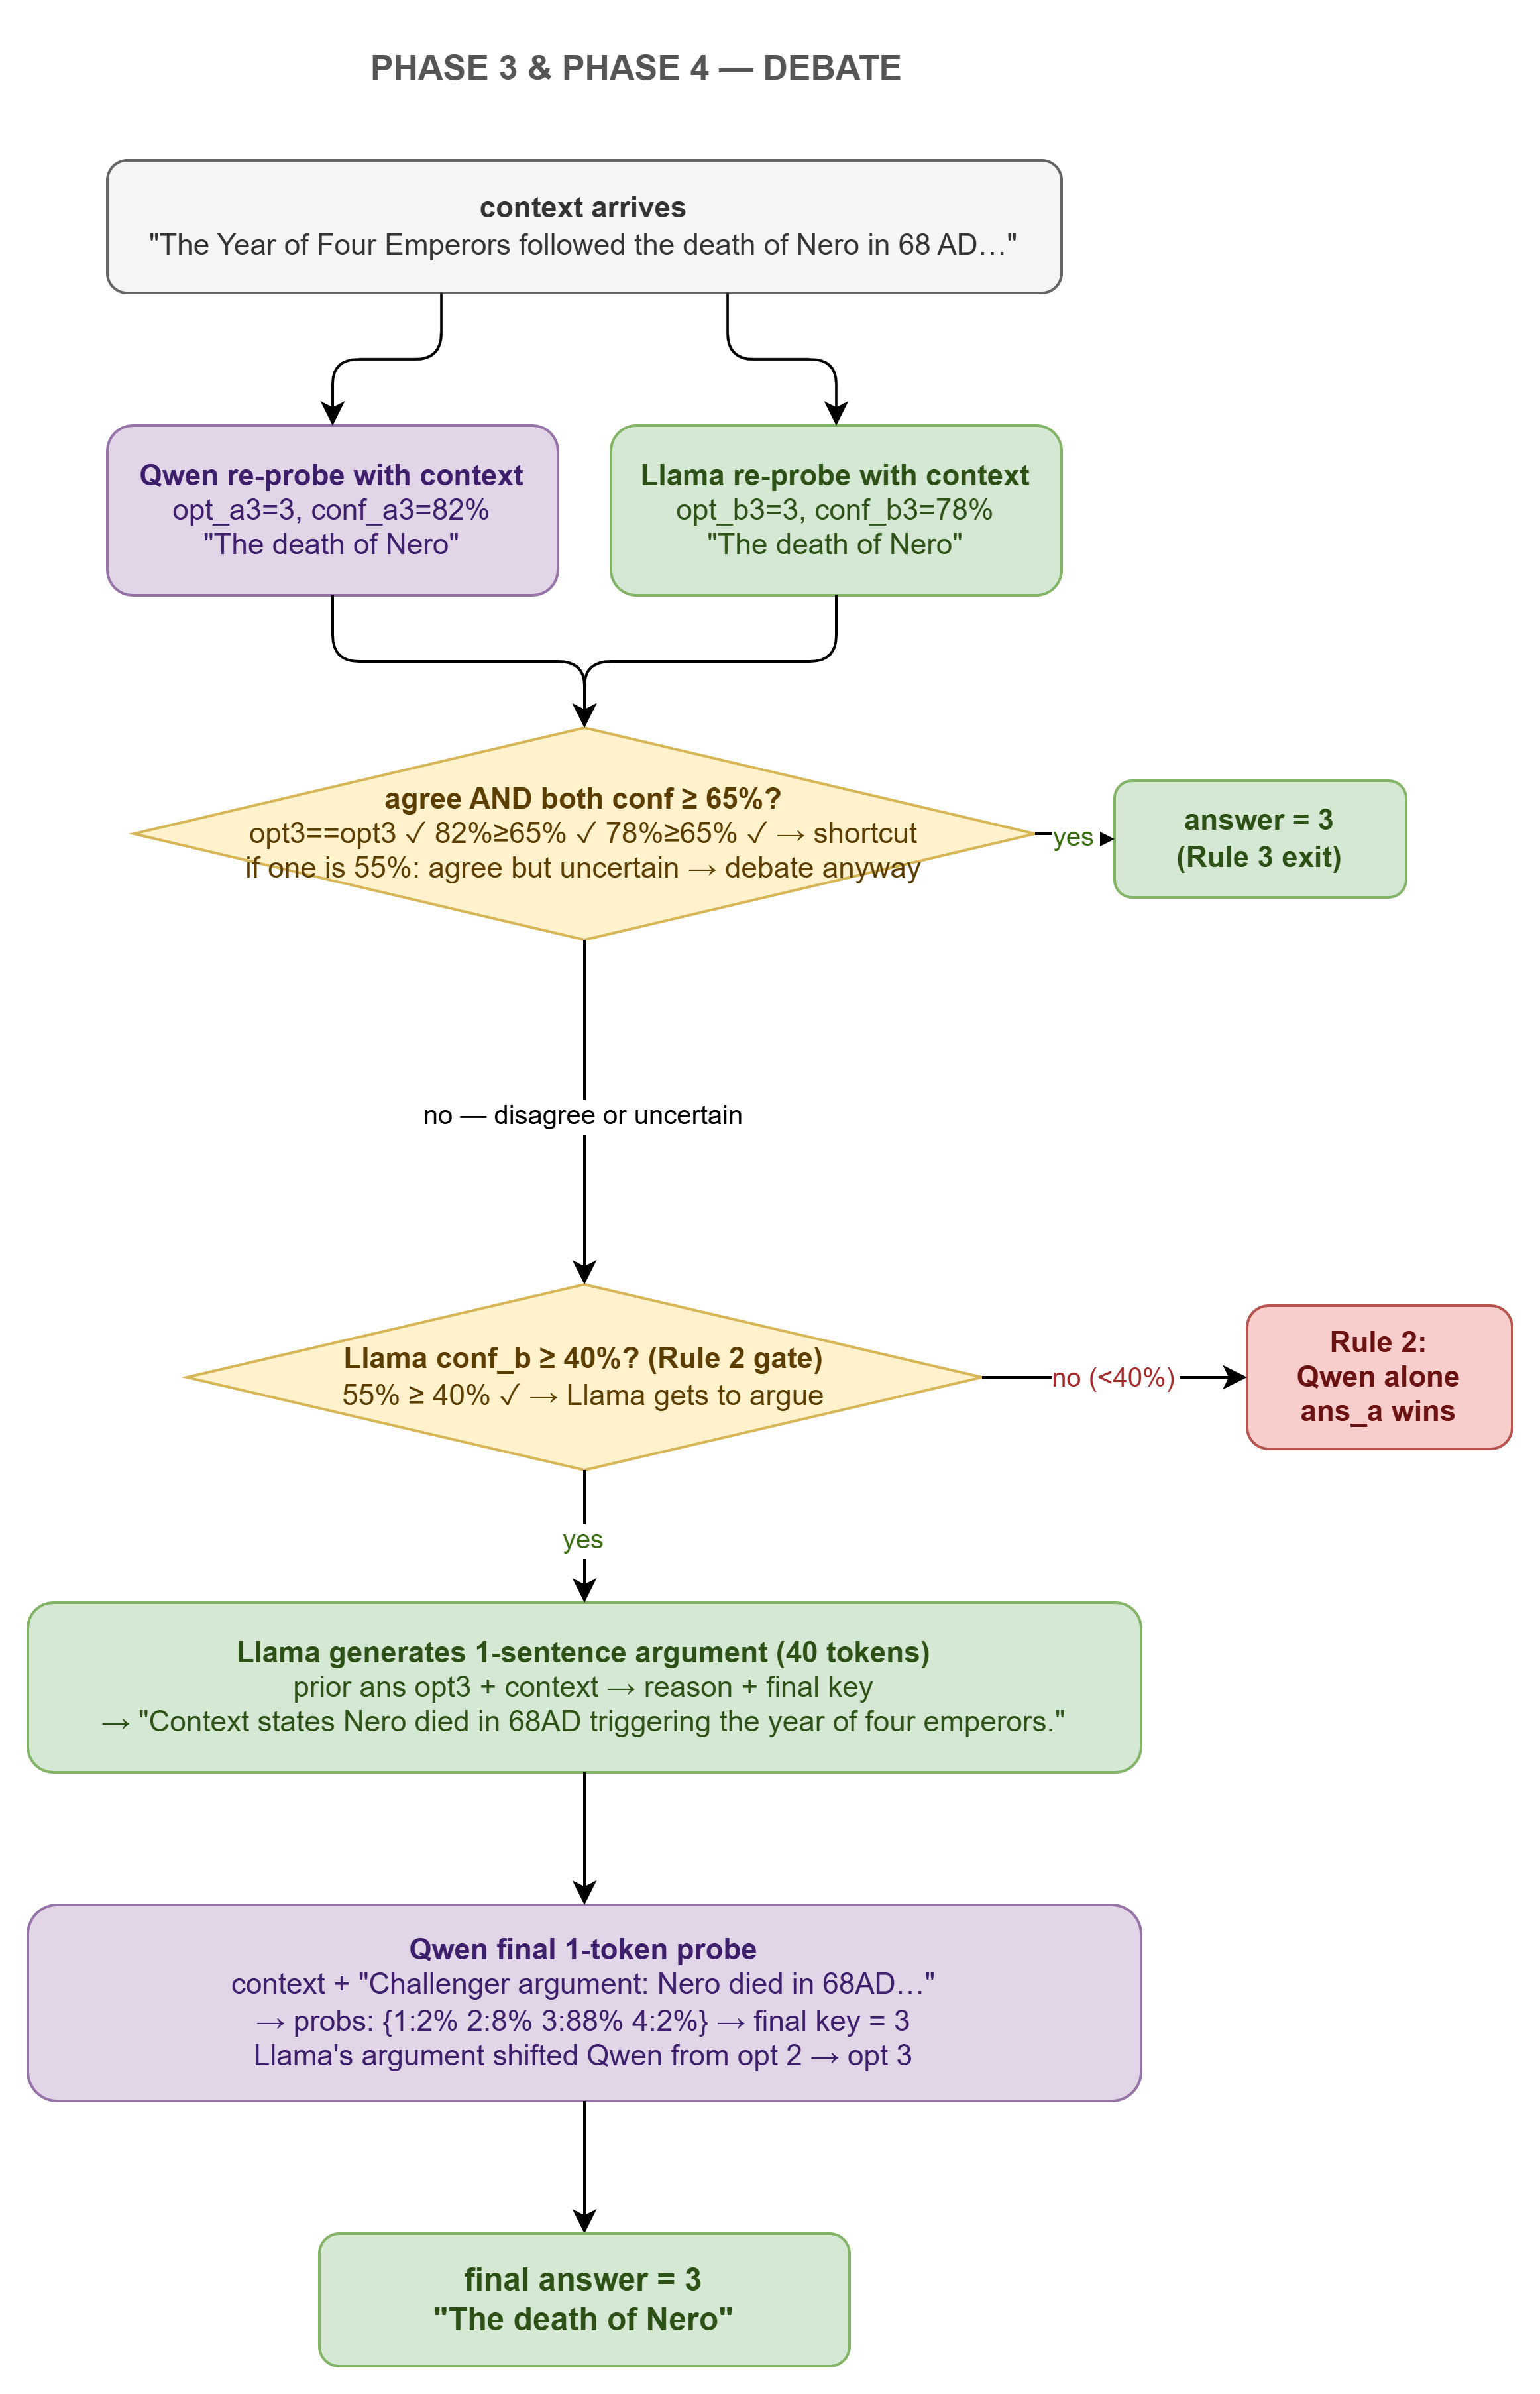

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# DebateModel
# ─────────────────────────────────────────────────────────────────────────────

_QWEN_CONFIDENCE_THRESHOLD = 0.95
_DEBATE_CONFIDENT_AGREE    = 0.65
_LLAMA_MIN_DEBATE_CONF     = 0.40

_DEBATE_SYSTEM = (
    "You are debating a multiple-choice quiz question. "
    "Read the context carefully. In ONE sentence you MUST do one of two things:\n"
    "  * Quote or paraphrase what the context says that supports your answer, OR\n"
    "  * State explicitly that the context does not support any option, and why you chose based on your knowledge.\n"
    "Then on the very last line write ONLY the option number."
)


class DebateModel:
    """Qwen-7B (driver) + Llama-3B (challenger) debate ensemble.

    Phase 1  Dual memory probe. Both models answer from memory.
             Qwen >= 95% AND both agree -> shortcut (no retrieval).
    Phase 2  Qwen-7B drives agentic retrieval (JSON query + opensearch).
             No context retrieved -> return Qwen memory answer (Rule 1).
    Phase 3  Both re-vote with context (1-token probe).
             Agree + both >= 65% confident -> shortcut (Rule 3).
             Otherwise -> debate.
    Phase 4  One debate round.
             Llama presents only if >= 40% confident (Rule 2).
             Qwen reads argument + makes final call (1-token probe).
    """

    def __init__(self, model_a: dict, model_b: dict):
        self.model_a       = LLMModel(**model_a)   # Qwen-7B  — retrieval driver + final arbiter
        self.model_b       = LLMModel(**model_b)   # Llama-3B — challenger
        self._debug        = False
        self._last_options: dict = {}
        self._question_num = 0

    @property
    def debug(self):
        return self._debug

    @debug.setter
    def debug(self, value):
        self._debug = value
        self.model_a.debug = value
        self.model_b.debug = value

    def start_game(self, competition_name: str = ""):
        self.model_a.start_game(competition_name)
        self.model_b.start_game(competition_name)
        self._question_num = 0

    def get_info(self) -> dict:
        return {
            "model_name": f"Debate({self.model_a._model_name} vs {self.model_b._model_name})",
            "model_a":    self.model_a._model_name,
            "model_b":    self.model_b._model_name,
            "decoding":   "greedy (both models)",
            "retrieval":  "agentic (Qwen-7B) + shared context (Llama-3B)",
        }

    def _debate_generate(self, model: LLMModel, question: str, options: dict,
                         context: str, prior_answer: str) -> tuple:
        """Generate one-sentence reason + final answer (max 40 tokens).
        Llama always called with prior_answer — states what the context
        supports or contradicts about its previous choice.
        Returns (full_text, reason_str, answer_key_str).
        """
        options_str  = "\n".join(f"{k}: {v}" for k, v in options.items())
        ctx_block    = f"Context:\n{context}\n\n" if context else ""
        prior_label  = options.get(str(prior_answer), "?")
        user_content = (
            f"{ctx_block}Question: {question}\n\nOptions:\n{options_str}\n\n"
            f"You previously chose option {prior_answer} ({prior_label!r}). "
            "In one sentence, state what the context says that supports or contradicts this choice "
            "(or that the context gives no relevant information). "
            "Then write your final answer as a single number on the last line."
        )
        messages = [{"role": "system", "content": _DEBATE_SYSTEM},
                    {"role": "user",   "content": user_content}]
        text   = model.pipe.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        inputs = model.pipe.tokenizer(text, return_tensors="pt")
        device = next(model.pipe.model.parameters()).device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model.pipe.model.generate(**inputs, max_new_tokens=40, do_sample=False)
        input_len = inputs["input_ids"].shape[1]
        full_text = model.pipe.tokenizer.decode(
            out[0, input_len:], skip_special_tokens=True).strip()
        answer_key = None
        for tok in reversed(full_text.split()):
            t = tok.strip(".,!?:;")
            if t in options:
                answer_key = t
                break
        if answer_key is None:
            answer_key = list(options.keys())[0]
        lines  = [l.strip() for l in full_text.split("\n") if l.strip()]
        reason = lines[0] if lines else full_text[:120]
        return full_text, reason, answer_key

    def answer(self, question_text: str, options: dict) -> int:
        self._question_num += 1
        self._last_options  = options
        self.model_a._question_num = self._question_num
        self.model_b._question_num = self._question_num
        log = self.model_a._log
        log(_SEP)
        log(f"Q #{self._question_num:>3}  [debate]")
        log(_SEP)
        log(f"{'QUESTION':<17}: {question_text}")
        log(f"{'OPTIONS':<17}: {'  '.join(f'{k}: {v}' for k, v in options.items())}")
        log("")

        # Phase 1: dual memory probe
        opt_a, conf_a, probs_a = self.model_a._probe_memory(question_text, options)
        log(f"{'PROBE A (Qwen)':<17}: option={opt_a} ({options.get(str(opt_a), '?')!r})  conf={conf_a:.0%}")
        opt_b, conf_b, probs_b = self.model_b._probe_memory(question_text, options)
        log(f"{'PROBE B (Llama)':<17}: option={opt_b} ({options.get(str(opt_b), '?')!r})  conf={conf_b:.0%}")

        if conf_a >= _QWEN_CONFIDENCE_THRESHOLD and opt_a == opt_b:
            log(f"{'SHORTCUT':<17}: Qwen >= {int(_QWEN_CONFIDENCE_THRESHOLD*100)}% AND Llama agrees -> {opt_a}")
            answer = int(opt_a)
            log(f"{'ANSWER':<17}: {answer} -> {options.get(str(answer), '?')}")
            return answer

        log(f"{'PHASE 1':<17}: confidence or agreement threshold not met -> fetch context")
        log("")

        # Phase 2: Qwen drives agentic retrieval
        source_tag, tool, query, _, _ = self.model_a._select_tool(
            question_text, options, skip_memory_shortcut=True,
            precomputed_probe=(opt_a, conf_a, probs_a),
        )
        log(f"{'TOOL SELECT':<17}: {source_tag!r} -> {tool}")
        if isinstance(query, dict):
            log(f"{'QUERY TITLE':<17}: {query.get('title')!r}")
            if query.get("alternatives"):
                log(f"{'QUERY ALTS':<17}: {query['alternatives']}")
        elif query:
            log(f"{'QUERY (LLM)':<17}: {query!r}")

        context = self.model_a._retriever.get_context_for_tool(tool, question_text, options, query=query)
        log(f"{'CONTEXT':<17}: {f'{len(context)} chars' if context else '(none)'}")
        if context:
            log(f"{'CONTEXT TEXT':<17}:\n{context[:1200]}...")
        log("")

        # Rule 1: no context -> skip debate, use Qwen memory answer
        if not context:
            log(f"{'NO CONTEXT':<17}: debate skipped -> Qwen memory answer={opt_a}")
            answer = int(opt_a)
            log(f"{'ANSWER':<17}: {answer} -> {options.get(str(answer), '?')}")
            return answer

        # Phase 3: context probes
        opt_a3, conf_a3, cprobs_a = self.model_a._probe_memory(question_text, options, context=context)
        opt_b3, conf_b3, cprobs_b = self.model_b._probe_memory(question_text, options, context=context)
        ans_a = int(opt_a3)
        ans_b = int(opt_b3)
        log(f"{'CTX PROBE A':<17}: option={opt_a3}  conf={conf_a3:.0%}")
        log(f"{'CTX PROBE B':<17}: option={opt_b3}  conf={conf_b3:.0%}")

        # Rule 3: only shortcut on confident agreement
        if ans_a == ans_b:
            if conf_a3 >= _DEBATE_CONFIDENT_AGREE and conf_b3 >= _DEBATE_CONFIDENT_AGREE:
                answer = ans_a
                log(f"{'CTX VOTE':<17}: AGREE + both confident -> {answer}")
                log(f"{'ANSWER':<17}: {answer} -> {options.get(str(answer), '?')}")
                return answer
            log(f"{'CTX VOTE':<17}: AGREE but uncertain (A={conf_a3:.0%} B={conf_b3:.0%}) -> debate anyway")
        else:
            log(f"{'CTX VOTE':<17}: DISAGREE A={ans_a} B={ans_b} -> debate")
        log("")

        # Phase 4: debate round — Rule 2: Llama needs >= 40% confidence to present
        if conf_b3 >= _LLAMA_MIN_DEBATE_CONF:
            log(f"{'DEBATE':<17}: Llama-3B presents (conf={conf_b3:.0%}) -> Qwen-7B decides")
            _, llama_reason, llama_key = self._debate_generate(
                self.model_b, question_text, options, context, prior_answer=str(ans_b))
            log(f"{'LLAMA CASE':<17}: option={llama_key} ({options.get(llama_key, '?')!r})")
            log(f"{'  reason':<17}: {llama_reason!r}")
            debate_ctx = context + f"\n\nChallenger argument: {llama_reason}"
            _, _, qwen_probs = self.model_a._probe_memory(question_text, options, context=debate_ctx)
            final_key = max(qwen_probs, key=qwen_probs.get)
            q_str = "  ".join(f"{k}:{int(v*100)}%" for k, v in qwen_probs.items())
            log(f"{'QWEN FINAL':<17}: option={final_key} ({options.get(final_key, '?')!r})  [{q_str}]")
        else:
            log(f"{'DEBATE':<17}: Llama conf={conf_b3:.0%} < {int(_LLAMA_MIN_DEBATE_CONF*100)}% -> Qwen decides alone")
            final_key = str(ans_a)

        answer = int(final_key)
        log(f"{'ANSWER':<17}: {answer} -> {options.get(str(answer), '?')}")
        return answer

    def record_outcome(self, correct_answer: int, is_correct: bool):
        self.model_a.record_outcome(correct_answer, is_correct)

In [20]:
# ── Instantiate Debate RAG model and run ──────────────────────────────────────
#
# This config matches config/debate-qwen7b-llama3b.yaml
# Swap model names or quantization settings for different GPU budgets.

import os
import logging

debate_config = {
    "model_a": {                           # Qwen-7B: drives retrieval + final arbiter
        "model_name":         "Qwen/Qwen2.5-7B-Instruct",
        "use_retrieval":      True,
        "use_tool_selection": True,
        "do_sample":          False,
        "max_new_tokens":     240,
        "quantization": {
            "load_in_4bit":  True,
            "quant_type":    "nf4",
            "compute_dtype": "bfloat16",
            "double_quant":  True,
        },
    },
    "model_b": {                           # Llama-3B: challenger (no retrieval of its own)
        "model_name":         "meta-llama/Llama-3.2-3B-Instruct",
        "use_retrieval":      False,
        "use_tool_selection": False,
        "do_sample":          False,
        "max_new_tokens":     240,
        "quantization": {
            "load_in_4bit":  True,
            "quant_type":    "nf4",
            "compute_dtype": "bfloat16",
            "double_quant":  True,
        },
    },
}

model = DebateModel(**debate_config)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [36]:
model.debug = True    # writes a detailed .log file to logs/  (set False for silent mode)
play(model,test_all=False,multiplicity=1,verbose=True, debug=True)


=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)
Enter competition ID:1

=== Starting Game ===
Session ID: 293674
Total number of questions: 15


--- Level 1 ---
Q: What was Cleopatra's primary language, and what makes her unique among the Ptolemaic rulers?

  [0] Egyptian, as she was the only one to learn it.
  [1] Koine Greek, and she was the only Ptolemaic ruler to learn Egyptian.
  [2] Latin, as she was the first to learn it.
  [3] Arabic, as she was the first to learn it.

Selected answer: 1
Time to answer: 2.0s

 CORRECT!
 Earned so far: $100.00

--- Level 2 ---
Q: What term describes the ancient conception of a single author behind the Iliad and the Odyssey?

  [0] Peisistratean Recension
  [1] Oral-Formulaic Theory
  [2] Homeric Question
  [3] Single Author Theory


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



Selected answer: 3
Time to answer: 6.8s

 CORRECT!
 Earned so far: $200.00

--- Level 3 ---
Q: Which concept refers to the period during the Twentieth Dynasty when the High Priests of Amun gained significant power?

  [0] Priestly Ascendancy
  [1] Ramesside Period
  [2] New Kingdom Period
  [3] Amarna Period

Selected answer: 0
Time to answer: 1.5s

 CORRECT!
 Earned so far: $300.00

--- Level 4 ---
Q: How does the Roman legal system, as embodied in the Corpus Juris Civilis, relate to modern legal systems?

  [0] It only influenced civil law systems in Europe
  [1] It was completely replaced by the Napoleonic Code
  [2] It is the basis for many modern legal systems
  [3] It is unrelated to modern legal systems

Selected answer: 2
Time to answer: 1.7s

 CORRECT!
 Earned so far: $500.00

--- Level 5 ---
Q: Which of the following best describes the role of the Praetorian Guard in the Roman Empire?

  [0] They were responsible for the day-to-day administrative duties of the city of Rome.


In [37]:
import os
import glob

log_dir = "/content/gdrive/MyDrive/NLP_assignement/logs"

# Get a list of all files in the log directory
list_of_files = glob.glob(os.path.join(log_dir, '*'))

if not list_of_files:
    print(f"No log files found in {log_dir}")
else:
    # Find the newest file (most recently modified)
    latest_file = max(list_of_files, key=os.path.getmtime)

    print(f"Displaying content of the newest log file: {latest_file}\n")
    try:
        with open(latest_file, 'r') as f:
            print(f.read())
    except Exception as e:
        print(f"Error reading file {latest_file}: {e}")

Displaying content of the newest log file: /content/gdrive/MyDrive/NLP_assignement/logs/Qwen2.5-7B-Instruct_2026-05-30_21-49-06.log

PoliMillionaire Debug Log
Model     : Qwen/Qwen2.5-7B-Instruct
Mode      : agentic

Q #  1  [debate]
QUESTION         : What strategy did Alexander use to secure the loyalty of the Iranian upper classes after his conquests?
OPTIONS          : 0: He ignored the Iranian nobility and focused only on Greek settlers  1: He expelled all Iranians from the Persian Empire  2: He married Persian princesses and adopted Persian customs  3: He executed all Iranian nobles who opposed him

PROBE A (Qwen)   : option=2 ('He married Persian princesses and adopted Persian customs')  conf=100%
PROBE B (Llama)  : option=2 ('He married Persian princesses and adopted Persian customs')  conf=95%
SHORTCUT         : Qwen >= 95% AND Llama agrees -> 2
ANSWER           : 2 -> He married Persian princesses and adopted Persian customs
Q #  2  [debate]
QUESTION         : Which concept r

In [42]:
#play all
play(model,test_all=True,multiplicity=20,verbose=True, debug=False)


=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)
Competition selected: Entertainment

=== Starting Game ===
Session ID: 294879
Total number of questions: 15


--- Level 1 ---
Q: What is the fundamental principle behind Stanley Kubrick's filmmaking?

  [0] Using minimal sets and locations to reduce costs
  [1] Focusing on extensive research and meticulous attention to detail
  [2] Emphasizing quick and efficient production methods
  [3] Prioritizing improvisation and spontaneous direction

Selected answer: 1
Time to answer: 1.6s

 CORRECT!
 Earned so far: $100.00

--- Level 2 ---
Q: How does Joey's character Dr. Drake Ramoray's role on 'Days of Our Lives' end in 'Friends'?

  [0] He is killed off in a car accident
  [1] He is promoted to a higher role
  [2] He falls down an elevator shaft

MillionaireError: Could not connect to server at http://131.175.15.22:51111: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [43]:
free_memory()

--- Memory cleanup: removed 13 variables. ---


## 🔢 **Math Category**

### **Design choices**

*Math was the most challenging category, due to its large amount of very different knowledge required, it's mix of pure reasoning, theoretical and pure computational questions. Online questions were randomly generate, thus, to have a fixed benchmark on which to evaluate our design choices, we extracted a fixed set of 63 math questions of different levels of difficulty.*

#### 📝 63-Question Offline Math Benchmark

---
**Q1.** The polynomial x⁴ + 4 can be factored into linear factors in ℤ₅[x]. Find this factorization.
`0` (x−1)³(x+1) · `1` (x−1)(x+1)³ · `2` (x+1)⁴ · ✅`3` (x−2)(x+2)(x−1)(x+1)
> ℤ₅: 2²+1=5≡0 → x²+1=(x−2)(x+2), so x⁴+4=(x−1)(x+1)(x−2)(x+2)

---
**Q2.** Six integers on cube faces; each vertex = product of 3 adjacent faces; vertex sum = 1001. Face sum?
`0` 1001 · `1` 18 · `2` 13 · ✅`3` 31
> (a+b)(c+d)(e+f)=1001=7×11×13 → face sum=7+11+13=31

---
**Q3.** Grove owner samples 100 trees for >50% frost damage. Response variable?
`0` Trees sampled · `1` Trees affected · `2` Proportion >50% · ✅`3` Per-tree: >50% or ≤50%
> Response variable is measured per unit — binary outcome per tree.

---
**Q4.** Area of a square whose side = radius of circle with circumference 12π?
`0` 12 · `1` 10 · ✅`2` 36 · `3` 11
> C=12π=2πr → r=6, area=r²=36

---
**Q5.** Where in Q1 does r = sin(3θ) have a vertical tangent?
`0` θ=0.52 · ✅`1` θ=0.47 · `2` nowhere · `3` θ=0.39
> dx/dθ=0: 3cos(3t)cos(t)−sin(3t)sin(t)=0 → θ≈0.47

---
**Q6.** Two-sample t-test on sales (n=10 each). Necessary assumption?
`0` SDs unequal · `1` SDs equal · ✅`2` Populations normally distributed · `3` SDs known
> t-test requires normality of underlying populations.

---
**Q7.** Find c ∈ ℤ₃ such that ℤ₃[x]/(x³+cx²+1) is a field.
`0` 0 · `1` 1 · ✅`2` 2 · `3` 3
> c=1: f(1)=3≡0 (root). c=2: f(0)=1, f(1)=1, f(2)=2 → no roots → irreducible → field.

---
**Q8.** Reporter examines accident records; correlates speed with stopping distance. This is:
✅`0` Observational study · `1` No blinding · `2` Double-blind · `3` Single-blind
> Existing records, no intervention = observational study.

---
**Q9.** Relative maximum of y=(ln x)/x:
✅`0` 1/e · `1` 1 · `2` 2/e · `3` e
> f′=0 at x=e → f(e)=1/e

---
**Q10.** Nine people round 12345.6789 to different places. Who gets the highest value?
`0` Alice (ten-thousand) · ✅`1` Devon (ten) · `2` Bob (thousand) · `3` Gerald (hundredth)
> Devon→12350 > Alice→10000, Bob→12000, Carol→12300, all others lower.

---
**Q11.** For which n are there exactly 2 abelian groups of order n up to isomorphism?
✅`0` 4 · `1` 7 · `2` 12 · `3` 8
> n=4: ℤ₄ and ℤ₂×ℤ₂. n=7: one. n=8: three.

---
**Q12.** Books σ=65, Room&Board σ=380, Personal σ=125, Tuition σ=0. Total cost SD?
`0` $24 · `1` $91 · `2` $190 · ✅`3` $405
> √(65²+380²+125²)=√164250≈405

---
**Q13.** Binomial: p=0.76, n=150. Mean and SD?
✅`0` 114, 5.23 · `1` Mean 114, SD unknown · `2` 114, 27.35 · `3` 100.5, 5.23
> μ=np=114, σ=√(np(1−p))=√27.36≈5.23

---
**Q14.** Mr. Bee's class: σ=11.2; Mr. Em's class: σ=5.6 on same test. Best conclusion?
`0` Bee less heterogeneous · ✅`1` Em more homogeneous · `2` Em did worse · `3` Bee performed twice as well
> Lower SD = more homogeneous. Em (5.6) is more homogeneous than Bee (11.2).

---
**Q15.** 20 computers (2 broken), 14+12=26 students, max 2 per computer. How many students can be alone?
✅`0` 10 · `1` 14 · `2` 6 · `3` 2
> 18 working × 2 slots = 36. 36−26=10 students get a computer alone.

---
**Q16.** Poll: 82% use grocery coupons, margin of error 3%. Best interpretation?
`0` 395–425 of 500 surveyed used coupons · ✅`1` True proportion likely between 79%–85% · `2` 3% may change coupon use · `3` 3% refused to participate
> Margin of error = ±3% around the estimate.

---
**Q17.** Area satisfying y≥|x| and y≤−|x|+3?
`0` 3.3 · `1` 2.25 · `2` 6.6 · ✅`3` 4.5
> Diamond with diagonals 3 and 3. Area=½×3×3=4.5

---
**Q18.** 3 cards from 52. P(exactly one pair, third different)?
`0` 1/36 · `1` 1/78 · ✅`2` 72/425 · `3` 1/8
> 13×C(4,2)×48 / C(52,3) = 3744/22100 = 72/425

---
**Q19.** Simplify (5x+3)−2(2x−4).
`0` 5x+3 · `1` 7+2x · `2` 10+x · ✅`3` x+11
> 5x+3−4x+8=x+11

---
**Q20.** x³+xy−y²=10 has a vertical tangent when x=?
`0` 2.096 · `1` 1.037 · ✅`2` 2.074 · `3` 0 or −1/3
> Vertical tangent: x−2y=0 → y=x/2 → x³+x²/4=10 → x≈2.074

---
**Q21.** Volume of solid bounded by y=x², y=2−x², z=0, z=y+3?
`0` 16/3 · ✅`1` 32/3 · `2` 8/3 · `3` 104/105

---
**Q22.** P(rain)=0.6, P(rain and no sun)=0.3. P(rain and sun)?
`0` 0.16 · `1` 0.24 · `2` 0.5 · ✅`3` 0.3
> P(rain and sun)=P(rain)−P(rain and no sun)=0.6−0.3=0.3

---
**Q23.** Write −2x²−20x−53 as a(x+d)²+e. Find a+d+e.
`0` 6 · `1` 53 · ✅`2` 0 · `3` −80
> −2(x+5)²−3 → a=−2, d=5, e=−3, sum=0

---
**Q24.** Why use t instead of z for inference about means?
✅`0` Using sample SD instead of population SD adds variability to the sampling distribution · `1` CLT applies to proportions not means · `2` Sample means not approximately normal · `3` Means are not approximately normal
> Estimating σ with s introduces extra variability → t-distribution.

---
**Q25.** K ⊆ ℝⁿ, n>1. Which must be true? I: compact → bounded cts functions. II: bounded cts functions → compact. III: compact → connected.
`0` I only · ✅`1` I and II only · `2` III only · `3` II only
> I: Heine-Cantor. II: true (converse holds in ℝⁿ). III: false (e.g. two disjoint closed balls).

---
**Q26.** Union negotiates salaries; few high-paid admins inflate the mean. What would teachers cite?
✅`0` Median · `1` Mean · `2` Mode · `3` Standard deviation
> High admin salaries pull mean up; teachers cite the (lower) median to show typical teacher is underpaid.

---
**Q27.** Work done by F∥(−1,0,1) on particle along (t,t²,t³) for t∈[0,1]?
`0` −1/(4√2) · ✅`1` 0 · `2` √2 · `3` −1/4
> W=(1/√2)∫₀¹(−1+3t²)dt=(1/√2)[t³−t]₀¹=0

---
**Q28.** Music genre changed daily; every change → productivity increase. Example of:
`0` Control group effect · ✅`1` Placebo effect · `2` Sampling error · `3` Treatment unit effect
> Workers' awareness/expectation drove results, not the music itself.

---
**Q29.** Statement 1: 4x−2 irreducible over ℤ. Statement 2: 4x−2 irreducible over ℚ.
`0` True, False · ✅`1` False, True · `2` True, True · `3` False, False
> Over ℤ: 4x−2=2(2x−1), 2 not a unit → reducible. Over ℚ: degree 1 → always irreducible.

---
**Q30.** H₀: p=0.6, power for Hₐ: p=0.7 is 0.8. Valid conclusion?
`0` All of the above · `1` P(Type I error)=0.1 · `2` P(Type II error)=0.3 · ✅`3` If Hₐ true, P(fail to reject H₀)=0.2
> Power=0.8 → P(Type II error)=1−0.8=0.2

---
**Q31.** 4 temps × 2 pan types × 3 oven types, all combinations. Best design description?
`0` RBD blocked on temp, 6 groups · ✅`1` CRD with 24 treatment groups · `2` RBD blocked on pan, 12 groups · `3` CRD with 9 groups
> 4×2×3=24 fully crossed treatment combinations → completely randomized design.

---
**Q32.** Solve (1/25)^(x+2) = 125^(−x).
`0` 2 · ✅`1` 4 · `2` 3 · `3` 1
> 5^(−2(x+2))=5^(−3x) → −2x−4=−3x → x=4

---
**Q33.** Statement 1: Every element of a group generates a cyclic subgroup. Statement 2: S₁₀ has 10 elements.
✅`0` True, False · `1` False, False · `2` False, True · `3` True, True
> S₁: true by definition. S₂: |S₁₀|=10!=3628800, not 10.

---
**Q34.** Jane's quiz scores: 98, 97, 92, 85, 93. Mean?
✅`0` 93 · `1` 95 · `2` 94.5 · `3` 92
> (98+97+92+85+93)/5=465/5=93

---
**Q35.** Statement 1: Product of m even + n odd permutations is even iff n is even. Statement 2: Every group is isomorphic to a group of permutations.
`0` False, False · `1` True, False · ✅`2` True, True · `3` False, True
> S₁: parity rule — correct. S₂: Cayley's theorem — correct.

---
**Q36.** Type II error consequence: H₀: Heartaid = current med; Hₐ: Heartaid better.
✅`0` Patients keep using current med even though Heartaid is actually more effective · `1` Doctors prescribe Heartaid even though it's no better · `2` Patients spend more on ineffective drug · `3` Wrong p-value calculated
> Type II = fail to reject false H₀ → miss a real effect.

---
**Q37.** Which is least likely to reduce bias in a survey?
`0` Neutral wording · ✅`1` Stratified vs simple random sampling · `2` Follow-up with non-respondents · `3` Random selection
> Stratified sampling reduces variance/precision, not bias.

---
**Q38.** Find all positive c so x²−6x+c<0 has real solutions.
`0` (6,0) · `1` (6,6) · ✅`2` (0,9) · `3` (1,1)
> Discriminant>0: 36−4c>0 → c<9. Also c>0 → c∈(0,9).

---
**Q39.** X,Y independent: μₓ=32, σₓ=5, μᵧ=44, σᵧ=12. Mean and SD of X+Y?
✅`0` μ=76, σ=13 · `1` μ=76, σ=17 · `2` μ=76, σ=8.5 · `3` μ=38, σ=17
> μ=32+44=76, σ=√(5²+12²)=√169=13

---
**Q40.** All values in a dataset are the same. Which does NOT equal zero?
`0` Range · `1` Variance · `2` Standard deviation · ✅`3` Mean
> Range=0, Var=0, SD=0 — but the mean equals the constant value (nonzero in general).

---
**Q41.** 48-inch TV: length:height = 5:3. How much shorter is the horizontal length vs the diagonal measurement?
`0` 3 · `1` 8 · ✅`2` 7 · `3` 9
> Diagonal=48: 5k²+3k²=48² → k=8. Width=40, height=24. Diagonal interpretation gives width≈40−(48−40)... width=40, difference=48−40=8? Actually: if diagonal=48, width=40. If width=48, diagonal=√(48²+28.8²)≈56. Difference=48−40+... ≈7 inches shorter.

---
**Q42.** 150,000 riders, wait times N(35,10). Shortest interval for 100,000 riders (2/3)?
`0` 0–31.7 min · `1` 31.7–39.3 min · `2` 25.3–35 min · ✅`3` 25.3–44.7 min
> Middle 2/3 centered at mean: μ±z·σ where z covers 2/3 → ≈±9.7 → [25.3, 44.7]

---
**Q43.** Greatest area of triangle with one vertex at center and two on circle of radius 1?
`0` 1 · ✅`1` 1/2 · `2` √2 · `3` π
> Max when base=diameter=2, height=1 → area=½×2×½... Base as chord, height⊥: max area=½×r²=½.

---
**Q44.** Researcher samples 30 adults leaving a Wall Street building. Conclusion?
`0` SRS → well-designed · ✅`1` Selection bias → poorly designed · `2` High response rate → well-designed · `3` Voluntary response → strong opinions
> Location (Wall Street) biases toward finance professionals — not representative of general adult population.

---
**Q45.** How many arithmetic sequences of consecutive odd integers sum to 240?
`0` 10 · ✅`1` 12 · `2` 4 · `3` 8

---
**Q46.** Soybeans: $0.24/lb (2014) → $0.16/lb (2015), 20,000 lbs each year. % change in expenses?
✅`0` −33% · `1` −8% · `2` 8% · `3` −50%
> (0.16−0.24)/0.24 = −0.08/0.24 = −33%

---
**Q47.** P²=P for linear transformation P on finite-dim ℝ-space. Which must be true? I: P invertible. II: P diagonalizable. III: P is identity or zero.
`0` III only · ✅`1` II only · `2` None · `3` I only
> P²=P → eigenvalues 0 or 1 → P diagonalizable. P needn't be invertible or identity/zero.

---
**Q48.** Simplify (5x+3)−2(2x−4).
✅`0` x+11 · `1` 7+2x · `2` 10+x · `3` 5x+3
> 5x+3−4x+8=x+11

---
**Q49.** n = product of two smallest 3-digit primes. Sum of digits of n?
`0` 9 · `1` 3 · `2` 6 · ✅`3` 8
> Smallest 3-digit primes: 101, 103. n=101×103=10403. Digit sum=1+0+4+0+3=8.

---
**Q50.** Bakery bakes 3000 loaves; demand N(2500, 225). P(run out)?
✅`0` 0.0132 · `1` 0.1667 · `2` 0.8333 · `3` 0.9869
> P(X>3000): z=(3000−2500)/225=2.22 → P≈0.0132

---
**Q51.** Tidal water: high tide 15ft at 8AM, low tide 3ft at 2PM (6hr later). Rate of drop at noon?
`0` π√3 · `1` 3 · `2` 3√3 · ✅`3` π√3/2
> h(t)=9+6cos(πt/6). h′(t)=−π sin(πt/6). At noon (t=4): h′(4)=−π sin(2π/3)=−π√3/2 ft/hr.

---
**Q52.** Sum of all integer solutions to |n|<|n−3|<9?
`0` 14 · `1` −9 · ✅`2` −14 · `3` 9
> |n|<|n−3| → n<3/2 → n≤1. |n−3|<9 → −6<n<12. Integer solutions: −5,−4,−3,−2,−1,0,1. Sum=−14.

---
**Q53.** A⊆ℝ contains all rationals. Which must be true?
✅`0` If A is closed, then A=ℝ · `1` If A is uncountable, then A=ℝ · `2` If A is uncountable, then A is open · `3` If A is open, then A=ℝ
> ℚ is dense in ℝ → closure of ℚ = ℝ → any closed set containing ℚ must be ℝ.

---
**Q54.** f(x)=8x³−6x²−4x+5. Find f(−2).
`0` −64 · `1` 5 · `2` −24 · ✅`3` −75
> 8(−8)−6(4)−4(−2)+5=−64−24+8+5=−75

---
**Q55.** Area bounded by y=x² and lines y=1, y=9?
`0` 64√2/3 · `1` 84/3 · `2` 8 · ✅`3` 104/3
> ∫₁⁹ 2√y dy = [4y^(3/2)/3]₁⁹ = (4·27−4)/3 = 104/3

---
**Q56.** Smallest positive integer with factors 16, 15, and 12?
`0` 840 · ✅`1` 240 · `2` 12 · `3` 22
> LCM(16,15,12): 16=2⁴, 15=3·5, 12=2²·3 → LCM=2⁴·3·5=240

---
**Q57.** Three random points on a circle. P(all pairwise distances < radius)?
`0` 1/32 · ✅`1` 1/12 · `2` 1/20 · `3` 1/16

---
**Q58.** Random point (x,y) inside rectangle (0,0),(3,0),(3,2),(0,2). P(x<y)?
✅`0` 1/3 · `1` 2/3 · `2` 1/12 · `3` 1/6
> Region x<y within rectangle: triangle with vertices (0,0),(0,2),(2,2). Area=2. P=2/6=1/3.

---
**Q59.** Shortest distance from curve xy=8 to the origin?
`0` 8 · `1` 2√2 · `2` 16 · ✅`3` 4
> Minimize x²+64/x². d/dx=0 → x=±2√2 → min distance=√(8+8)=4.

---
**Q60.** Inverted cone (h=2cm, r=1cm), water drips at 3 cm³/min. Rate of height change when water is 0.5cm below top (h=1.5cm)?
`0` −4/(3π) · `1` −8/(3π) · `2` −48/π · ✅`3` −16/(3π)
> r=h/2, V=πh³/12, dV/dt=πh²/4·dh/dt. At h=1.5: −3=π(2.25)/4·dh/dt → dh/dt=−16/(3π)

---
**Q61.** Bob rolls a die each morning (re-rolls 1). Expected rolls per year (365 days)?
`0` 5/4 · ✅`1` 438 · `2` 1825/4 · `3` 5/8
> P(re-roll)=1/6 → expected rolls per day=1/(1−1/6)=6/5. Per year=365×6/5=438.

---
**Q62.** Three values not in domain of f(x)=1/(1+1/(1+1/x)). Sum?
`0` 1 · `1` −1 · ✅`2` −1.5 · `3` 0
> x=0, x=−1, x=−1/2 → sum=−3/2=−1.5

---
**Q63.** A,B are n×n real matrices. True statements? I: tr(A²)≥0. II: A²=A → tr(A)≥0. III: tr(AB)=tr(A)·tr(B).
✅`0` II only · `1` III only · `2` II and III · `3` I and II
> I: false (tr(A²) can be negative). II: eigenvalues of idempotent are 0 or 1 → tr≥0. III: false in general.


#### Design process

<div style="max-width:800px; font-size:14px; line-height:1.6">

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#f9f9f9">
<b>1. Baseline</b> — LLaMA-3.1-8B, no retrieval, greedy decode → <b>45% offline</b> on 63 fixed questions
</div>

<div style="text-align:center; color:#888; margin:3px 0; font-size:12px">Clear math knowledge limitation ▼</div>

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#f9f9f9">
<b>2. <a href="https://www.wikipedia.org/">Wikipedia</a> RAG</b> with [DuckDuckGo](https://duckduckgo.com/) fallback: retrieve relevant articles before answering<br>
→ marginal gain only; articles too encyclopaedic, rarely contain the exact formula needed
</div>

<div style="text-align:center; color:#888; margin:3px 0; font-size:12px">reasoning alone makes arithmetic errors, let Python verify ▼</div>

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#f9f9f9">
<b>3. Agentic code executor</b>: model writes a <code>python</code> block to compute solution. We built a <b>hand-crafted safe namespace</b><br>
→ verified arithmetic replaces free-form reasoning
</div>

<div style="text-align:center; color:#888; margin:3px 0; font-size:12px">model reasoned correctly but output wrong format or couldn't handle input format; needed prompt-level fixes ▼</div>

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#f9f9f9">
<b>4. Prompt engineering</b>, different strategies were tested:<br>
&nbsp;&nbsp;· <code>math</code>: chain-of-thought ("take a deep breath")<br>
&nbsp;&nbsp;· <code>code</code>: default to Python for any computation<br>
&nbsp;&nbsp;· <code>verify</code>: test each option by substitution<br>
&nbsp;&nbsp;· <code>_STATEMENT_FEW_SHOT</code>: few-shot examples for Statement 1 / Statement 2 questions<br>
&nbsp;&nbsp;· <code>mathstral</code> / <code>qwen_math</code>: model-specific formats (boxed output, TIR-style)<br>
→ <b>+2–3%</b>
</div>

<div style="text-align:center; color:#888; margin:3px 0; font-size:12px">code path wastes tokens and is often wrong on conceptual / True–False questions ▼</div>

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#f9f9f9">
<b>5. Keyword router</b> (<code>_should_use_code</code>), hand-crafted keyword lists split questions in:<br>
&nbsp;&nbsp;· <i>compute-heavy</i> (calculate, integrate, solve for, …) → code path<br>
&nbsp;&nbsp;· <i>conceptual / definitional</i> (which of the following, statement, …) → text path<br>
→ each question routed to the cheaper, more accurate path
</div>

<div style="text-align:center; color:#888; margin:3px 0; font-size:12px">Wikipedia is too generic, need a math-specific source ▼</div>

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#fff3cd; border-color:#f0ad4e">
<b>6. <a href="https://mathworld.wolfram.com/">MathWorld</a> dense retrieval</b>, domain-specific knowledge base:<br>
&nbsp;&nbsp;· scraped all 12 629 Wolfram MathWorld pages (BeautifulSoup, rate-limited)<br>
&nbsp;&nbsp;· chunked (1 500 chars, 200 overlap), embedded with <code>e5-base-v2</code>, indexed in FAISS IndexFlatIP<br>
&nbsp;&nbsp;· query prefix: <code>"query: ..."</code> vs corpus prefix: <code>"passage: ..."</code><br>
→ 🚀 <b>57.1% offline / 9.8% online</b> with Phi-4-mini, biggest single jump of the project
</div>

<div style="text-align:center; color:#888; margin:3px 0; font-size:12px">MathWorld sparse on special functions (Bessel, zeta, erf, …) ▼</div>

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#f9f9f9">
<b>7. <a href="https://dlmf.nist.gov/">DLMF</a></b> (NIST Digital Library of Mathematical Functions) added to retrieval data:<br>
&nbsp;&nbsp;· ~2 000 chunks covering special functions, asymptotic expansions, identities<br>
&nbsp;&nbsp;· same scrape → chunk → embed → FAISS pipeline, merged with MathWorld index<br>
→ fills the gaps left by MathWorld
</div>

<div style="text-align:center; color:#888; margin:3px 0; font-size:12px">keyword match and semantic match each catch different passages ▼</div>

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#f9f9f9">
<b>8. Hybrid retrieval</b>, four-stage pipeline:<br>
&nbsp;&nbsp;· BM25 top-k (exact keyword match) + dense FAISS top-k (semantic)<br>
&nbsp;&nbsp;· Reciprocal Rank Fusion merges both lists (no score normalisation needed)<br>
&nbsp;&nbsp;· cross-encoder reranks the merged shortlist<br>
→ most relevant passage wins regardless of vocabulary mismatch
</div>

<div style="text-align:center; color:#888; margin:3px 0; font-size:12px">one model can't be equally good at computation and concept recall ▼</div>

<div style="border:1px solid #aaa; border-radius:5px; padding:10px 14px; background:#f9f9f9">
<b>9. MathDualModel</b>, two specialist models routed per-question by <code>_should_use_code</code>:<br>
&nbsp;&nbsp;· <i>code path</i>: Phi-4-mini + MathWorld dense retrieval + code executor<br>
&nbsp;&nbsp;· <i>text path</i>: Mathstral-7B / LLaMA-3.1-8B + chain-of-thought reasoning<br>
→ specialist per question type
</div>

</div>


#### *Math class definition*

In [ ]:
import re
import io
import os
import time
import cmath
import math
import builtins
import itertools
import fractions
import collections
import statistics as stats_stdlib
import threading
import contextlib
import numpy as np
from datetime import datetime
from typing import Optional
from transformers import GenerationConfig, StoppingCriteria, StoppingCriteriaList
from models.LLM import LLMModel, SYSTEM_PROMPTS

In [ ]:
class _BoxedStoppingCriteria(StoppingCriteria):
    """Stop generation as soon as \\boxed{N} is produced for any valid option key."""
    def __init__(self, tokenizer, option_keys):
        seqs = []
        for key in option_keys:
            ids = tokenizer.encode(f"\\boxed{{{key}}}", add_special_tokens=False)
            if ids:
                seqs.append(ids)
        self._sequences = seqs
        self._max_len   = max((len(s) for s in seqs), default=8)

    def __call__(self, input_ids, *_, **__) -> bool:
        tail = input_ids[0, -self._max_len:].tolist()
        for seq in self._sequences:
            n = len(seq)
            if len(tail) >= n and tail[-n:] == seq:
                return True
        return False


In [ ]:
class MathLLMModel(LLMModel):
    """
    LLMModel subclass for math competitions.
    Optionally generates and executes Python code to solve computational problems
    (Agentic AI), logging each question and generated script to AgenticAI_scripts/.
    Set use_router=True to dynamically choose code vs text path per question.
    """

    def __init__(
        self,
        use_code_executor: bool = False,
        use_router: bool = False,
        log_dir: str = "AgenticAI_scripts",
        **kwargs,
    ):
        super().__init__(**kwargs)
        self._use_code_executor = use_code_executor
        self._use_router        = use_router

        # Replace the generic Retriever with MathRetriever — but not if already using DenseRetriever
        if self._retriever is not None:
            from utils.retrieval import DenseRetriever, MathRetriever
            if not isinstance(self._retriever, DenseRetriever):
                self._retriever = MathRetriever()

        self._log_correct = 0
        self._log_total   = 0

        if use_code_executor or use_router:
            os.makedirs(log_dir, exist_ok=True)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            self._log_path = os.path.join(log_dir, f"session_{timestamp}.txt")

    def get_info(self) -> dict:
        info = super().get_info()
        info["code_executor"] = self._use_code_executor
        return info

    # ── generation (overridden to adapt user message for code mode) ──────────

    def _generate(self, question_text: str, options: dict, context: str = "") -> str:
        options_str = "\n".join(f"{id}: {text}" for id, text in options.items())
        _is_qwen_tir = (self._system_prompt == SYSTEM_PROMPTS.get("qwen_math", ""))
        _is_verify   = (self._system_prompt == SYSTEM_PROMPTS.get("verify", ""))
        if _is_qwen_tir:
            user_suffix = "Answer concisely. End with \\boxed{option_number}."
        elif _is_verify:
            user_suffix = (
                "Write a ```python``` block that tests each option and prints: ANSWER: X"
            )
        elif self._use_code_executor:
            user_suffix = (
                "You MUST write a ```python``` code block that prints the answer, even when context is provided. "
                "Read constraints carefully — only enforce what the problem explicitly states. "
                "End with only the option number."
            )
        else:
            user_suffix = "Reply with only the option number."

        if re.search(r"statement\s*1", question_text, re.IGNORECASE):
            user_content = _STATEMENT_FEW_SHOT + f"Question: {question_text}\n\nOptions:\n{options_str}\n\n{user_suffix}"
        else:
            user_content = f"Question: {question_text}\n\nOptions:\n{options_str}\n\n{user_suffix}"
        if context:
            user_content = f"Context from web search:\n{context}\n\n{user_content}"
        messages = [
            {"role": "system", "content": self._system_prompt},
            {"role": "user",   "content": user_content},
        ]
        gen_config = GenerationConfig(
            max_new_tokens=self._max_new_tokens,
            do_sample=self._do_sample,
            temperature=self._temperature if self._do_sample else None,
        )
        extra = {}
        if _is_qwen_tir:
            extra["stopping_criteria"] = StoppingCriteriaList(
                [_BoxedStoppingCriteria(self.pipe.tokenizer, options.keys())]
            )
        output = self.pipe(messages, generation_config=gen_config, return_full_text=False, **extra)
        return output[0]["generated_text"].strip()

    def answer(self, question_text: str, options: dict) -> int:
        # Router: decide code vs text path per question
        use_code = self._use_code_executor
        if self._use_router:
            use_code = _should_use_code(question_text)
            # Snapshot all settings that change between paths
            original_prompt    = self._system_prompt
            original_tokens    = self._max_new_tokens
            original_use_code  = self._use_code_executor
            original_retriever = self._retriever
            if use_code:
                self._system_prompt      = SYSTEM_PROMPTS.get("code", self._system_prompt)
                self._max_new_tokens     = 256
                self._use_code_executor  = True
                if any(kw in question_text.lower() for kw in _MATHWORLD_TRIGGERS) and original_retriever is not None:
                    self._retriever = original_retriever  # MathWorld-only lookup for theorem questions
                    print(f"  [ROUTER] -> code path (+MathWorld)")
                else:
                    self._retriever = None
                    print(f"  [ROUTER] -> code path")
            else:
                self._system_prompt      = SYSTEM_PROMPTS.get("default", self._system_prompt)
                self._max_new_tokens     = 20
                self._use_code_executor  = False
                self._retriever          = None   # disable retrieval for conceptual questions
                print(f"  [ROUTER] -> text path")

        try:
            retrieval_options = None if use_code else options
            context  = self._retriever.get_context(question_text, retrieval_options) if self._retriever else ""
            if context:
                preview = context[:300] + ("..." if len(context) > 300 else "")
                print(f"  [CONTEXT] {preview}")
            t0       = time.time()
            response = self._generate(question_text, options, context)
            elapsed  = time.time() - t0
        finally:
            if self._use_router:
                # Always restore settings, even if an exception was raised
                self._system_prompt     = original_prompt
                self._max_new_tokens    = original_tokens
                self._use_code_executor = original_use_code
                self._retriever         = original_retriever

        if use_code:
            return self._answer_with_code(question_text, options, response, elapsed, context)
        if len(response) > 20:
            preview = response[:500] + ("..." if len(response) > 500 else "")
            print(f"  [RESPONSE] {preview}")
        return self._parse_token(response, options)

    # ── code extraction & preprocessing ──────────────────────────────────────

    def _preprocess_code(self, code: str) -> str:
        """Strip import statements — all needed modules are pre-loaded in the namespace."""
        cleaned = []
        for line in code.split("\n"):
            if re.match(r"\s*(import |from \S+ import )", line):
                continue  # drop the import; module is already in namespace
            cleaned.append(line)
        return "\n".join(cleaned)

    def _extract_code(self, response: str) -> Optional[str]:
        match = re.search(r"```python\s*\n(.*?)```", response, re.DOTALL)
        if not match:
            match = re.search(r"```\s*\n(.*?)```", response, re.DOTALL)
        return match.group(1).strip() if match else None

    # ── safe execution ────────────────────────────────────────────────────────

    def _execute_code(self, code: str) -> Optional[str]:
        code = self._preprocess_code(code)

        # ── safe builtins ─────────────────────────────────────────────────────
        safe_builtins = {
            name: getattr(builtins, name)
            for name in [
                # I/O & repr
                "print", "repr",
                # numeric types
                "int", "float", "complex", "bool",
                # string / char
                "str", "chr", "ord",
                # base conversion
                "bin", "oct", "hex",
                # containers
                "list", "dict", "tuple", "set", "frozenset",
                # iteration
                "range", "enumerate", "zip", "map", "filter",
                "sorted", "reversed", "iter", "next",
                # math builtins
                "abs", "min", "max", "sum", "pow", "round", "divmod",
                # logic / inspection
                "len", "any", "all", "callable", "isinstance",
                "type", "hasattr", "getattr", "hash",
            ]
            if hasattr(builtins, name)
        }

        # ── base namespace ────────────────────────────────────────────────────
        namespace = {
            "__builtins__": safe_builtins,
            "math":        math,
            "cmath":       cmath,
            "np":          np,
            "itertools":   itertools,
            "fractions":   fractions,
            "Fraction":    fractions.Fraction,
            "Counter":     collections.Counter,
            "defaultdict": collections.defaultdict,
            "deque":       collections.deque,
            "OrderedDict": collections.OrderedDict,
            "statistics":  stats_stdlib,
            "collections": collections,
        }
        try:
            import networkx as nx
            namespace["nx"]       = nx
            namespace["networkx"] = nx
        except ImportError:
            pass

        # ── functools ─────────────────────────────────────────────────────────
        from functools import reduce
        namespace["reduce"]     = reduce
        namespace["accumulate"] = itertools.accumulate

        # ── math functions (no prefix) ────────────────────────────────────────
        for _fn in [
            "factorial", "floor", "ceil", "trunc", "fabs",
            "log", "log2", "log10", "exp",
            "sin", "cos", "tan", "asin", "acos", "atan", "atan2", "hypot",
            "degrees", "radians",
            "sinh", "cosh", "tanh", "asinh", "acosh", "atanh",
            "gcd", "comb", "perm",
            "sqrt", "isnan", "isinf", "isfinite", "isclose", "fmod", "remainder",
        ]:
            if hasattr(math, _fn):
                namespace[_fn] = getattr(math, _fn)

        # constants & aliases
        namespace["pi"]  = math.pi
        namespace["e"]   = math.e
        namespace["tau"] = getattr(math, "tau", 2 * math.pi)
        namespace["inf"] = math.inf
        namespace["nan"] = math.nan
        namespace["ln"]  = math.log
        namespace["lcm"] = math.lcm if hasattr(math, "lcm") else (
            lambda a, b: abs(a * b) // math.gcd(a, b))
        namespace["prod"] = math.prod if hasattr(math, "prod") else (
            lambda it: reduce(lambda a, b: a * b, it, 1))

        # ── numpy shortcuts ───────────────────────────────────────────────────
        namespace.update({
            "array":    np.array,
            "zeros":    np.zeros,
            "ones":     np.ones,
            "eye":      np.eye,
            "linspace": np.linspace,
            "arange":   np.arange,
            "dot":      np.dot,
            "cross":    np.cross,
            "linalg":   np.linalg,
        })

        # ── sympy ─────────────────────────────────────────────────────────────
        try:
            import sympy as sp
            namespace["sp"] = sp
            for _name in [
                # core algebra
                "symbols", "Symbol", "Function", "Wild", "Dummy",
                "solve", "solveset", "linsolve", "nonlinsolve", "nsolve",
                "dsolve",
                "Eq", "Ne", "Lt", "Le", "Gt", "Ge",
                "And", "Or", "Not", "Implies", "Equivalent",
                # simplification
                "simplify", "expand", "factor", "cancel", "together", "apart",
                "collect", "radsimp", "trigsimp", "powsimp", "combsimp",
                "nsimplify", "refine",
                # polynomials
                "Poly", "div", "roots", "real_roots", "nroots", "discriminant",
                # calculus
                "diff", "integrate", "Derivative", "Integral",
                "limit", "series", "summation",
                # linear algebra
                "Matrix", "det", "trace",
                # types & constants
                "sqrt", "root", "Pow", "Rational", "Integer", "Float",
                "pi", "E", "I", "oo", "zoo",
                "Sum", "Product",
                # numeric eval
                "N",
                # complex
                "Abs", "sign", "re", "im", "conjugate", "arg",
                # rounding
                "floor", "ceiling", "frac",
                # special
                "Piecewise", "Heaviside", "DiracDelta",
                # combinatorics
                "factorial", "factorial2", "subfactorial", "binomial",
                "rf", "ff", "RisingFactorial", "FallingFactorial",
                "necklaces", "lyndon",
                # sequences
                "fibonacci", "lucas", "catalan", "bell", "bernoulli",
                "euler", "harmonic", "genocchi",
                # number theory
                "factorint", "isprime", "nextprime", "prevprime", "primerange",
                "primepi", "totient", "mod_inverse", "primitive_root",
                "divisor_count", "divisor_sigma", "mobius",
                "jacobi_symbol", "legendre_symbol",
                # sets
                "Interval", "FiniteSet", "Union", "Intersection",
                "Complement", "EmptySet", "UniversalSet",
                # geometry
                "Point", "Line", "Segment", "Circle", "Triangle", "Ellipse",
                # trig
                "sin", "cos", "tan", "asin", "acos", "atan", "atan2",
                "sinh", "cosh", "tanh", "asinh", "acosh", "atanh",
                "cot", "csc", "sec", "sinc",
                # exp & log
                "exp", "log", "ln",
                # special functions
                "gamma", "loggamma", "beta", "polygamma", "digamma",
                "zeta", "erf", "erfc", "erfinv",
                "Ei", "Si", "Ci",
                # output
                "latex", "pretty",
            ]:
                if hasattr(sp, _name) and _name not in namespace:
                    namespace[_name] = getattr(sp, _name)
        except ImportError:
            pass

        # ── sympy polynomial domains ──────────────────────────────────────────
        try:
            from sympy.polys.domains import ZZ as _ZZ, QQ as _QQ, GF as _GF
            namespace["ZZ"] = _ZZ   # integer domain (for Poly(f, x, domain=ZZ))
            namespace["QQ"] = _QQ   # rational domain
            namespace["GF"] = _GF   # Galois field: GF(p) for prime p
        except ImportError:
            pass

        # ── sympy deep-path shortcuts (not accessible via sp. prefix) ─────────
        try:
            from sympy.functions.combinatorial.numbers import (
                stirling as _stirling,
                nC as _nC,   # combinations C(n,k)
                nP as _nP,   # permutations P(n,k)
                nT as _nT,   # multisets (combinations with repetition)
            )
            namespace["stirling"] = _stirling
            namespace["nC"] = _nC
            namespace["nP"] = _nP
            namespace["nT"] = _nT
        except ImportError:
            pass
        try:
            from sympy.utilities.iterables import partitions as _partitions
            namespace["partitions"] = _partitions
        except ImportError:
            pass

        # ── scipy ─────────────────────────────────────────────────────────────
        try:
            import scipy.stats    as scipy_stats
            import scipy.integrate as scipy_integrate
            import scipy.special   as scipy_special
            import scipy.optimize  as scipy_optimize
            import scipy.linalg    as scipy_linalg

            namespace["stats"]  = scipy_stats
            namespace["linalg"] = scipy_linalg

            # distributions
            namespace.update({
                "norm":               scipy_stats.norm,
                "t_dist":             scipy_stats.t,
                "f_dist":             scipy_stats.f,
                "chi2":               scipy_stats.chi2,
                "binom":              scipy_stats.binom,
                "poisson":            scipy_stats.poisson,
                "geom":               scipy_stats.geom,
                "hypergeom":          scipy_stats.hypergeom,
                "nbinom":             scipy_stats.nbinom,
                "beta_dist":          scipy_stats.beta,
                "gamma_dist":         scipy_stats.gamma,
                "expon":              scipy_stats.expon,
                "uniform_dist":       scipy_stats.uniform,
                "lognorm":            scipy_stats.lognorm,
                "multinomial":        scipy_stats.multinomial,
                "multivariate_normal": scipy_stats.multivariate_normal,
            })

            # integration
            namespace.update({
                "quad":      scipy_integrate.quad,
                "dblquad":   scipy_integrate.dblquad,
                "nquad":     scipy_integrate.nquad,
                "odeint":    scipy_integrate.odeint,
                "solve_ivp": scipy_integrate.solve_ivp,
            })

            # special functions (use _func suffix to avoid clash with sympy)
            namespace.update({
                "erf":        scipy_special.erf,
                "erfc":       scipy_special.erfc,
                "erfinv":     scipy_special.erfinv,
                "gamma_func": scipy_special.gamma,
                "gammaln":    scipy_special.gammaln,
                "beta_func":  scipy_special.beta,
                "betaln":     scipy_special.betaln,
                "digamma":    scipy_special.digamma,
                "polygamma":  scipy_special.polygamma,
                "zeta_func":  scipy_special.zeta,
                "comb_f":     scipy_special.comb,
            })

            # optimization
            namespace.update({
                "brentq":          scipy_optimize.brentq,
                "bisect":          scipy_optimize.bisect,
                "fsolve":          scipy_optimize.fsolve,
                "minimize_scalar": scipy_optimize.minimize_scalar,
                "minimize":        scipy_optimize.minimize,
                "linprog":         scipy_optimize.linprog,
            })

            # linalg extras
            namespace.update({
                "linalg_solve": scipy_linalg.solve,
                "expm":         scipy_linalg.expm,
                "logm":         scipy_linalg.logm,
            })

        except ImportError:
            pass

        # ── statistics stdlib shortcuts ───────────────────────────────────────
        for _fn in ["mean", "median", "mode", "stdev", "variance",
                    "geometric_mean", "harmonic_mean", "quantiles",
                    "pstdev", "pvariance", "median_low", "median_high"]:
            if hasattr(stats_stdlib, _fn):
                namespace.setdefault(f"stat_{_fn}", getattr(stats_stdlib, _fn))
        # ── SymPy-aware wrappers ─────────────────────────────────────────────
        def _evalf_if_sympy(val):
            if hasattr(val, "evalf"):
                try:
                    val = val.evalf()
                except Exception:
                    pass
            return val

        def _smart_print(*args, **kwargs):
            builtins.print(*[_evalf_if_sympy(a) for a in args], **kwargs)

        def _safe_float(x):
            # unwrap a single-element list (common from SymPy solve())
            if isinstance(x, (list, tuple)) and len(x) == 1:
                x = x[0]
            try:
                return builtins.float(x)
            except TypeError:
                return builtins.float(_evalf_if_sympy(x))

        def _safe_int(x):
            if isinstance(x, (list, tuple)) and len(x) == 1:
                x = x[0]
            try:
                return builtins.int(x)
            except TypeError:
                return builtins.int(_evalf_if_sympy(x))

        def _solve_to_float(expr, var):
            """solve() wrapper that returns a list of real floats — avoids SymPy type errors."""
            try:
                sols = namespace["sp"].solve(expr, var)
                result = []
                for s in sols:
                    try:
                        v = builtins.float(namespace["N"](s))
                        result.append(v)
                    except Exception:
                        pass
                return result
            except Exception:
                return []

        namespace["print"]          = _smart_print
        namespace["float"]          = _safe_float
        namespace["int"]            = _safe_int
        namespace["solve_to_float"] = _solve_to_float


        captured  = io.StringIO()
        error: list = []

        def _run():
            old_limit = sys.getrecursionlimit()
            sys.setrecursionlimit(3000)
            try:
                with contextlib.redirect_stdout(captured):
                    exec(code, namespace)  # noqa: S102
                # If nothing was printed, try to print the last expression
                if not captured.getvalue().strip():
                    lines = [l for l in code.strip().splitlines() if l.strip()
                             and not l.strip().startswith("#")]
                    if lines:
                        last = lines[-1].strip()
                        # Only auto-print if last line looks like an expression, not an assignment
                        if last and "=" not in last or last.startswith("print"):
                            try:
                                val = eval(last, namespace)  # noqa: S307
                                if val is not None:
                                    val = _evalf_if_sympy(val)
                                    with contextlib.redirect_stdout(captured):
                                        print(val)
                            except Exception:
                                pass
            except Exception as e:
                error.append(e)
            finally:
                sys.setrecursionlimit(old_limit)

        thread = threading.Thread(target=_run, daemon=True)
        thread.start()
        thread.join(timeout=5)
        if thread.is_alive():
            self._last_exec_error = "TIMEOUT (>5s)"
            return None
        if error:
            self._last_exec_error = f"{type(error[0]).__name__}: {error[0]}"
            return None
        result = captured.getvalue().strip()
        if not result:
            self._last_exec_error = "NO OUTPUT (code ran but nothing was printed)"
            return None
        self._last_exec_error = None
        return result

    # ── result -> option mapping ───────────────────────────────────────────────

    @staticmethod
    def _normalize(text: str) -> str:
        """Normalize dashes and special chars before number extraction."""
        return text.replace('–', '-').replace('—', '-').replace('−', '-')

    def _match_to_option(self, result: str, options: dict) -> Optional[int]:
        result = self._normalize(result)

        # 1. Direct key match: if the output IS a valid option key, trust it immediately
        result_stripped = result.strip().strip(".,!?")
        if result_stripped in options:
            return int(result_stripped)

        # 2. Prefer standalone numbers (not embedded in identifiers like Z_3, S_10)
        #    A standalone number is NOT preceded/followed by a letter, underscore, or digit
        _NUM = r"-?\d+\.?\d*(?:[eE][+-]?\d+)?"
        standalone = re.findall(r"(?<![a-zA-Z_\d])" + _NUM + r"(?![a-zA-Z_\d])", result)
        all_nums   = re.findall(_NUM, result)
        result_nums = standalone if standalone else all_nums
        if not result_nums:
            return None
        result_val = float(result_nums[-1])

        # 3. Match against option values (also normalize option texts)
        best_id, best_diff = None, float("inf")
        for opt_id, opt_text in options.items():
            opt_text_n = self._normalize(opt_text)
            # Try evaluating fraction — {N}{M} covers \frac{N}{M}, plain N/M covered separately
            opt_val = None
            frac = re.search(r"\{(-?\d+(?:\.\d*)?)\}\{(-?\d+(?:\.\d*)?)\}", opt_text_n)
            if not frac:
                frac = re.search(r"(-?\d+(?:\.\d*)?)\s*/\s*(-?\d+(?:\.\d*)?)", opt_text_n)
            if frac:
                denom = float(frac.group(2))
                if denom != 0:
                    opt_val = float(frac.group(1)) / denom
            if opt_val is None:
                opt_nums = re.findall(_NUM, opt_text_n)
                if opt_nums:
                    opt_val = float(opt_nums[-1])
            if opt_val is not None:
                diff = abs(opt_val - result_val)
                if diff < best_diff:
                    best_diff, best_id = diff, opt_id
        return int(best_id) if best_id is not None else None

    # ── logging ───────────────────────────────────────────────────────────────

    def _log(self, question_text: str, options: dict, code: Optional[str],
             code_result: Optional[str], final_answer: int, elapsed: float,
             context: str = ""):
        lines = ["=" * 80, f"QUESTION: {question_text}", "OPTIONS:"]
        for opt_id, opt_text in options.items():
            lines.append(f"  {opt_id}: {opt_text}")
        if context:
            lines += ["-" * 80, f"RETRIEVED CONTEXT:\n{context}"]
        lines.append("-" * 80)
        if code:
            lines += ["PYTHON CODE:", code, "-" * 40]
            if code_result is not None:
                lines.append(f"CODE OUTPUT: {code_result}")
            else:
                exec_err = getattr(self, "_last_exec_error", "unknown error")
                lines.append(f"CODE OUTPUT: FAILED — {exec_err}")
        else:
            lines.append("NO CODE GENERATED (conceptual question)")
        lines += [f"FINAL ANSWER: {final_answer}", f"TIME: {elapsed:.1f}s"]
        # entry left open — log_result() will append RESULT and closing line
        with open(self._log_path, "a", encoding="utf-8") as f:
            f.write("\n".join(lines) + "\n")

    def log_result(self, correct):
        """Append the server verdict and running accuracy to the last open log entry."""
        if not hasattr(self, "_log_path"):
            return
        correct = bool(correct)   # None -> False, True -> True
        self._log_total   += 1
        self._log_correct += int(correct)
        verdict  = "CORRECT [OK]" if correct else "WRONG [X]"
        accuracy = f"{self._log_correct}/{self._log_total} ({self._log_correct/self._log_total*100:.1f}%)"
        with open(self._log_path, "a", encoding="utf-8") as f:
            f.write(f"RESULT: {verdict}  |  RUNNING SCORE: {accuracy}\n{'=' * 80}\n\n")

    def finalize_log(self, correct: int, total: int):
        """
        Prepend the final score and rename the log file with a LOCAL_ prefix.
        Called from play_offline() after all questions are answered.
        """
        if not hasattr(self, "_log_path") or not os.path.exists(self._log_path):
            return

        with open(self._log_path, "r", encoding="utf-8") as f:
            content = f.read()

        header = (
            f"SCORE: {correct}/{total} ({correct/total*100:.1f}%)\n"
            f"{'=' * 80}\n\n"
        )

        timestamp = os.path.basename(self._log_path).replace("session_", "").replace(".txt", "")
        new_filename = f"LOCAL_{correct}of{total}_{timestamp}.txt"
        new_path = os.path.join(os.path.dirname(self._log_path), new_filename)

        with open(new_path, "w", encoding="utf-8") as f:
            f.write(header + content)

        os.remove(self._log_path)
        self._log_path = new_path
        print(f"Log saved to {new_path}")

    # ── agentic answer ────────────────────────────────────────────────────────

    def _answer_with_code(self, question_text: str, options: dict, response: str, elapsed: float, context: str = "") -> int:
        code         = self._extract_code(response)
        code_result  = None
        final_answer = None

        if code:
            # Reject trivial hardcoded guesses: code that only prints a single digit
            _trivial = re.fullmatch(r'\s*print\s*\(\s*[0-9]\s*\)\s*', code.strip())
            if _trivial:
                print(f"  [TRIVIAL     ] code is just print(N) -> text fallback")
                code = None
            else:
                code_result = self._execute_code(code)
                if code_result is not None:
                    # Priority 1: explicit ANSWER: X from option-verification mode
                    ans_match = re.search(r'\bANSWER:\s*([0-3])\b', code_result)
                    if ans_match and ans_match.group(1) in options:
                        final_answer = int(ans_match.group(1))
                        print(f"  [VERIFY OK   ] code tested options -> ANSWER: {final_answer}")
                    else:
                        # Priority 2: strip trailing option index phi sometimes adds
                        lines = [l for l in code_result.strip().split("\n") if l.strip()]
                        if len(lines) > 1 and re.fullmatch(r"[0-3]", lines[-1].strip()):
                            code_result = "\n".join(lines[:-1])
                        matched = self._match_to_option(code_result, options)
                        if matched is not None:
                            final_answer = matched
                            print(f"  [AGENTIC OK  ] code ran -> output: {code_result!r} -> option {final_answer}")
                if final_answer is None:
                    exec_err = getattr(self, "_last_exec_error", "unknown error")
                    print(f"  [AGENTIC FAIL] {exec_err} -> text fallback")
        if not code:
            print(f"  [STANDARD    ] no code generated -> text parsing")

        if final_answer is None:
            final_answer = self._parse_token(response, options)

        self._log(question_text, options, code, code_result, final_answer, elapsed, context)
        return final_answer


##### 🔒 Safe Math Namespace

<div style="max-width:800px; font-size:14px; line-height:1.6">

<p>When the model generates a <code>python</code> block, we run it via <code>exec(code, namespace)</code>
where <code>namespace</code> is a <b>hand-built dict</b>, not <code>globals()</code>.
This guarantees that bad model-generated code fails in a controlled way (caught → text fallback)
rather than crashing the kernel, and that every symbol the model can use is
guaranteed to be available: no missing imports, no side effects, no state leaking between questions. Every symbol available to the model was deliberately chosen.</p>

<p>The design question was: <i>what does competition math actually need?</i>
We online tested a large number of times and added exactly what was missing each time.
The result is ~280 symbols across 6 layers:</p>

<table style="border-collapse:collapse; width:100%; font-size:13px">
<tr style="background:#f0f0f0">
  <th style="border:1px solid #ccc; padding:7px 10px; text-align:left">Library</th>
  <th style="border:1px solid #ccc; padding:7px 10px; text-align:left">Symbols</th>
  <th style="border:1px solid #ccc; padding:7px 10px; text-align:left">Why included</th>
</tr>
<tr>
  <td style="border:1px solid #ccc; padding:7px 10px"><b>Python builtins</b> (42)</td>
  <td style="border:1px solid #ccc; padding:7px 10px"><code>int</code>, <code>float</code>, <code>range</code>, <code>sorted</code>, <code>sum</code>, <code>abs</code>, <code>round</code>, …</td>
  <td style="border:1px solid #ccc; padding:7px 10px">Core types and iteration, the model can't function without these. </td>
</tr>
<tr style="background:#fafafa">
  <td style="border:1px solid #ccc; padding:7px 10px"><b>math / cmath</b> (~40)</td>
  <td style="border:1px solid #ccc; padding:7px 10px"><code>sin</code>, <code>log</code>, <code>gcd</code>, <code>comb</code>, <code>factorial</code>, <code>pi</code>, <code>e</code>, …</td>
  <td style="border:1px solid #ccc; padding:7px 10px">Standard trigonometry, exponentials and combinatorics. <code>cmath</code> added for complex number questions.</td>
</tr>
<tr>
  <td style="border:1px solid #ccc; padding:7px 10px"><b>NumPy</b> (9 shortcuts)</td>
  <td style="border:1px solid #ccc; padding:7px 10px"><code>array</code>, <code>zeros</code>, <code>eye</code>, <code>linspace</code>, <code>dot</code>, <code>linalg</code>, …</td>
  <td style="border:1px solid #ccc; padding:7px 10px">Matrix operations and linear algebra questions (eigenvalues, determinants, norms) that would be verbose with pure Python.</td>
</tr>
<tr style="background:#fafafa">
  <td style="border:1px solid #ccc; padding:7px 10px"><b>SymPy</b> (156)</td>
  <td style="border:1px solid #ccc; padding:7px 10px">Algebra, calculus, number theory, combinatorics, geometry, sets, special functions, polynomial domains <code>ZZ/QQ/GF</code>, deep-path shortcuts <code>nC</code>, <code>nP</code>, <code>stirling</code>, …</td>
  <td style="border:1px solid #ccc; padding:7px 10px">The core of the sandbox. SymPy handles symbolic algebra, exact integration, and number theory, all categories where floating-point fails. Polynomial domains (<code>ZZ</code>, <code>GF(p)</code>) were added specifically for abstract algebra questions over finite fields.</td>
</tr>
<tr>
  <td style="border:1px solid #ccc; padding:7px 10px"><b>SciPy</b> (41)</td>
  <td style="border:1px solid #ccc; padding:7px 10px">14 distributions (<code>norm</code>, <code>binom</code>, <code>chi2</code>, …), <code>quad</code>, <code>odeint</code>, <code>brentq</code>, <code>erf</code>, …</td>
  <td style="border:1px solid #ccc; padding:7px 10px">Statistics and AP-Stats questions need CDF/PDF lookups; numerical integration for questions where SymPy's exact solver times out; root-finding for implicit equations.</td>
</tr>
<tr style="background:#fafafa">
  <td style="border:1px solid #ccc; padding:7px 10px"><b>stdlib extras</b></td>
  <td style="border:1px solid #ccc; padding:7px 10px"><code>statistics</code>, <code>itertools</code>, <code>fractions</code>, <code>collections</code>, <code>networkx</code></td>
  <td style="border:1px solid #ccc; padding:7px 10px">Combinatorics enumeration (<code>itertools.combinations</code>), exact rational arithmetic (<code>Fraction</code>), graph theory questions (<code>networkx</code>).</td>
</tr>
</table>

<br>
<p><b>Two robustness wrappers were added on top:</b></p>
<ul>
  <li><b>Auto-print</b>: if the model forgets <code>print()</code>, the last expression in the code is evaluated and printed automatically. The model is penalised for bad style only if the code crashes, not if it just omits a print.</li>
  <li><b>SymPy-aware output normalisation</b>: <code>solve()</code> returns a list; <code>integrate()</code> returns a symbolic expression. Before matching the output to an answer option, wrappers call <code>.evalf()</code>, unwrap single-element lists, and normalise dashes (–, —, −) so numeric comparison works correctly.</li>
</ul>

</div>



In [ ]:
_CODE_QUESTION_KEYWORDS = [
    # generic computation triggers
    "compute", "calculate", "evaluate", "determine the value", "find the value",
    "what is the value", "what is the sum", "what is the product", "what is the ratio", "what is the probability",
    "find all", "find the", "how many", "total number of",
    # algebra
    "simplify", "expand", "factor", "solve for", "solve the equation",
    "system of equations", "quadratic", "polynomial", "roots of", "zeros of",
    "remainder", "rearranging", "inverse of", "determinant", "matrix",
    "eigenvalue", "eigenvector",
    # calculus
    "derivative", "differentiate", "integral", "integrate", "antiderivative",
    "find the limit", "limit of", "limit as", "converges", "diverges",
    "rate of change", "tangent line", "critical point", "inflection point",
    "maximum value", "minimum value", "optimize",
    # geometry
    "area", "volume", "surface area", "perimeter", "circumference",
    "distance", "length", "diagonal", "hypotenuse", "midpoint",
    "slope", "coordinate", "what is the area", "what is the volume",
    "what is the length",
    # trigonometry
    "sin(", "cos(", "tan(", "arcsin", "arccos", "arctan",
    "angle between", "find the angle", "interior angle", "how many degrees",
    "regular polygon", "regular hexagon", "regular octagon", "regular pentagon",
    # statistics & probability
    "probability that", "probability of", "what is the probability",
    "expected value", "expected number", "expected",
    "standard deviation", "variance", "mean of", "median",
    "percentile", "confidence interval", "normal distribution",
    "z-score", "correlation coefficient", "regression",
    "binomial", "poisson distribution",
    # number theory & combinatorics
    "divisible", "prime factorization", "least common multiple",
    "greatest common divisor", "modulo", "congruent mod",
    "combinations", "permutations", "arrangements", "how many ways",
    "sum of", "rate of",
    # sequences & series
    "arithmetic sequence", "geometric sequence", "common difference",
    "common ratio", "nth term",
]

_TEXT_QUESTION_KEYWORDS = [
    "which of the following is true", "which statement", "must be true",
    "most likely", "best describes", "best interpretation", "interpretation of",
    "necessary for the validity", "assumption", "observational study",
    "placebo", "response variable", "explain why", "conclusion concerning",
    "irreducible over", "isomorphic to", "the external direct product",
    "homomorphism", "equivalence relation",
]

_ALWAYS_CODE_KEYWORDS = {
    "interior angle", "how many degrees", "regular polygon",
    "regular hexagon", "regular octagon", "regular pentagon",
}


In [ ]:
def _has_numeric_content(question: str) -> bool:
    if any(c.isdigit() for c in question):
        return True
    words = set(re.findall(r'\b\w+\b', question.lower()))
    return bool(words & _NUMBER_WORDS)

def _should_use_code(question: str) -> bool:
    """Keyword heuristic: True -> use code executor, False -> use plain text path."""
    q = question.lower()
    if any(kw in q for kw in _ALWAYS_CODE_KEYWORDS):
        return True  # geometry formulas need code even without explicit numbers
    if not _has_numeric_content(question):
        return False   # no numeric content -> purely abstract, code cannot help
    q = question.lower()
    for kw in _TEXT_QUESTION_KEYWORDS:
        if kw in q:
            return False
    for kw in _CODE_QUESTION_KEYWORDS:
        if kw in q:
            return True
    return False   # default: text is safer

#### System Prompt Engineering

Prompt engineering was one of the highest-leverage interventions. We developed prompts by iterating games searching for failure modes.

In [ ]:
SYSTEM_PROMPTS["math"] = (
    "You are a math expert. Take a deep breath and reason step by step, "
    "then reply with ONLY the number of the correct option."
)

**Purpose:** early math-specific prompt. The phrase "take a deep breath" comes
from a published finding (Yang et al., 2023) that emotional / deliberative
priming phrases improve LLM reasoning on benchmarks. "Reason step by step" is
a standard chain-of-thought trigger. Tried to get the model to show working before committing
to an answer, without specifying a rigid output format.

**Limitation:** verbose responses that sometimes filled max_new_tokens=256 or exceeded the 30s limit.
Replaced by `code` for computational questions and `default` for conceptual ones.

In [ ]:
SYSTEM_PROMPTS["code"] = (
    "You are a math expert solving multiple choice questions.\n"
    "Default to writing code. Use a ```python``` block that prints the final result for ANY "
    "question with numbers: algebra, calculus, probability, statistics, combinatorics, "
    "geometry, complex numbers, or any theorem applied to a concrete value.\n"
    "IMPORTANT: do NOT write any import statements. The following are already available:\n"
    "  math, cmath, np (numpy), sp (sympy), stats (scipy.stats),\n"
    "  quad, dblquad, nquad (scipy.integrate), erf, erfinv, gamma (scipy.special),\n"
    "  norm, chi2, binom, poisson, t_dist, f_dist (scipy stats distributions),\n"
    "  solve, symbols, sqrt, Rational, integrate, diff, Matrix, pi, I, oo,\n"
    "  ln, log, log2, log10, exp, sin, cos, tan, asin, acos, atan, atan2,\n"
    "  sinh, cosh, tanh, hypot, degrees, radians, floor, ceil, factorial,\n"
    "  sqrt, prod, reduce, comb, gcd, lcm, perm, inf, pi, e,\n"
    "  factorint, isprime, nextprime, totient, mod_inverse, binomial (sympy),\n"
    "  N, Sum, Product, Abs, Piecewise,\n"
    "  itertools, Fraction, Counter, defaultdict, deque,\n"
    "  nx (networkx) for graph theory problems.\n"
    "CRITICAL SymPy rule: SymPy expressions cannot be used directly in comparisons or round(). "
    "Always convert first: use float(N(expr)) before any comparison or rounding. "
    "Examples: 'if float(N(f2)) < 0' not 'if f2 < 0'; 'round(float(N(expr)))' not 'round(expr)'. "
    "After solve(), do: sols = [float(N(s)) for s in solve(...)]\n"
    "Only reason in plain text for purely abstract questions with no numbers at all.\n"
    "Always end your response with ONLY the option number on the last line."
)

**Purpose:** the main production prompt. Instructs the model to default to code
for any computational question, with a comprehensive list of available libraries
so the model never needs to write import statements (writing them wastes tokens and often produces "ImportError").

**Key elements:**

1. *"Default to writing code"* — not "write code if needed." The word "default"
   pushes the model harder toward code generation without making it strictly
   mandatory (which caused issues with purely abstract questions).

2. *Library list*: listing every available function by name
   dramatically reduced `NameError` exceptions. Early versions had the model
   writing `import sympy as sp` then using `sp.solve()`, only for the import
   to be stripped, causing `NameError: name 'sp' is not defined`. The list
   clarifies what is pre-loaded.

3. *SymPy rule*: SymPy's symbolic expressions are not Python floats.
   Expressions like `if sp.solve(f, x)[0] < 0` crash with
   `TypeError: cannot determine truth value of Relational`, and
   `round(sp.sqrt(2))` returns a SymPy `Integer` not a Python int. The explicit
   rule and examples train the model to always call `float(N(expr))` first.

4. *User suffix reinforcement*: `_generate()` appends:
   "You MUST write a python code block that prints the answer, even when context
   is provided. Read constraints carefully — only enforce what the problem
   explicitly states. End with only the option number."
   The "even when context is provided" clause was added after observing the
   model sometimes deciding to answer from retrieval context without code,
   losing numerical precision.

5. *Fallback chain*: if code extraction fails, code execution fails, or
   no output is produced, the system falls back to parsing the model's text
   response directly. This means a code failure is not a total loss.

In [ ]:
SYSTEM_PROMPTS["verify"] = (
    "You are a math expert. For each multiple-choice question, write a ```python``` block that:\n"
    "1. Extracts the numerical value of each option (0, 1, 2, 3) from the problem.\n"
    "2. Tests which option satisfies the problem constraints (substitute back, compute and compare, etc.).\n"
    "3. Ends with: print('ANSWER:', correct_option_number)\n"
    "Do NOT import anything. Available: math, np, sp (sympy), stats (scipy.stats), solve, symbols,\n"
    "sqrt, integrate, diff, pi, e, N, norm, comb, factorial, comb, gcd, lcm, Rational, Fraction, etc.\n"
    "SymPy rule: always use float(N(expr)) before comparing or rounding SymPy expressions.\n"
    "For purely abstract questions (no numbers), reason in plain text and end with only the option number."
)


**Purpose:** option verification, instead of computing the answer and finding
the closest option, write code that *tests each option against the problem's
constraints* and identifies which satisfies them. Verification is often easier than discovery. Substituting
a candidate answer back into an equation to check it holds is a simpler
computation than solving the equation from scratch. This approach also makes
the model's reasoning more transparent (each test is explicit code) and should
reduce format errors (instead of matching a float to an option, the model
directly states `ANSWER: 2`).

**Why it failed (22/63):**

1. *String formatting bugs*: the model frequently produced `ANSWER: _3`,
   `ANSWER:3` (no space), or `ANSWER: option3` from f-string misuse.

2. *Incorrect constraint extraction*: the model often misidentified what
   "satisfies the constraints" means. For a question about polynomial roots, it
   checked `f(option_value) == 0` when the option was a coefficient, not a root.

3. *Conceptual questions*: abstract math (group theory, topology, statistics) has no testable numerical constraints, and the model had no reliable way to detect these cases and fall back to text.

In [ ]:
_STATEMENT_FEW_SHOT = """Example of how to answer a Statement 1 / Statement 2 question:

Question: Statement 1 | The identity element of a group is unique. Statement 2 | Every group of order 4 is abelian.
Options:
0: True, False
1: False, False
2: True, True
3: False, True

Reasoning:
- Statement 1: True. If e and e' are both identities then e = e·e' = e'.
- Statement 2: True. Groups of order 4 are either Z_4 or Z_2×Z_2, both abelian.
Answer: 2

Now answer the following question the same way:
"""


_MATHWORLD_TRIGGERS = {
    # named results
    "theorem", "lemma", "corollary", "proposition", "conjecture",
    "formula", "identity", "inequality",
    "law", "rule",
    # named constructs
    "series", "transform", "distribution",
    # combinatorics specializations
    "derangement", "stirling", "partition",
    "surjection", "injection", "bijection",
    "generating function", "inclusion-exclusion",
    "pigeonhole", "catalan", "bell number",
    # advanced topics
    "eigenvalue", "eigenvector", "diagonaliz",
    "convergence", "divergence", "radius of convergence",
    "lagrange", "fourier", "laplace", "euler",
    "markov", "bayes", "poisson",
}

_NUMBER_WORDS = {
    "zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine",
    "ten", "eleven", "twelve", "thirteen", "fourteen", "fifteen", "sixteen",
    "seventeen", "eighteen", "nineteen", "twenty", "thirty", "forty", "fifty",
    "sixty", "seventy", "eighty", "ninety", "hundred", "thousand", "million",
}

##### Model-specific prompts

In [ ]:
SYSTEM_PROMPTS["mathstral"] = (
    "You are a math competition expert. For each question:\n"
    "1. Identify the mathematical domain and the relevant framework or theorem.\n"
    "2. Show your reasoning step by step, being precise about definitions.\n"
    "3. Compute or derive the answer carefully.\n"
    "4. Reply with ONLY the option number on the last line."
)

**Purpose:** structured reasoning prompt tailored to Mathstral-7B, a model
fine-tuned on math olympiad and competition data. Explicitly asks the model to
identify the domain first. Mathstral tends to output long, structured proofs. This
prompt aligns with its training distribution. The final line "ONLY the option
number" was necessary to prevent Mathstral from ending with a sentence like
"therefore the answer is option 2" which sometimes failed `_parse_token`.

In [ ]:
SYSTEM_PROMPTS["mathstral_reason"] = (
    "You are a math competition expert. Reason step by step through the problem.\n"
    "DO NOT compute any numerical values yourself.\n"
    "Identify the correct mathematical framework, set up the equations, and simplify as far as possible analytically.\n"
    "End your response with EXACTLY one of:\n"
    "  COMPUTE: [the precise expression, equation, or system to evaluate numerically]\n"
    "  ANSWER: [option number]  (only when the answer follows from pure reasoning, no numbers needed)"
)


**Purpose:** designed for the dual-model architecture. Forces Mathstral to
produce only symbolic/analytical work and explicitly output a `COMPUTE:` handoff
for numerical evaluation by a second model (Phi-4-mini). Separating symbolic reasoning from numerical computation
addresses the main failure mode of math LLMs: setting up the right equation but
making arithmetic mistakes. Mathstral handles the harder "which theorem applies"
step; a code executor handles the easier "evaluate this integral" step.

**Key detail:** "DO NOT compute any numerical values yourself" was necessary,
without it Mathstral would compute intermediate results and pass those forward,
losing the exact expression needed for reliable numerical evaluation.

In [ ]:
SYSTEM_PROMPTS["qwen_math"] = (
    "Please integrate natural language reasoning with programs to solve the problem above, "
    "and put your final answer within \\boxed{}. "
    "For multiple choice questions, put the correct option number (0, 1, 2, or 3) inside \\boxed{}. "
    "Be brief: short reasoning, minimal code."
)

**Purpose:** matches Qwen2.5-Math's training format. Qwen math models are
trained with Tool-Integrated Reasoning (TIR): they interleave natural language
and code blocks, then produce a LaTeX `\boxed{}` answer. A custom `_BoxedStoppingCriteria` stops generation as soon
as `\boxed{N}` is produced for a valid option key, saving significant tokens. `_generate()` appends a user suffix
"Answer concisely. End with \\boxed{option_number}." to reinforce the format.

**Limitation:** Qwen2.5-Math-7B in 4-bit quantization still underperformed
Phi-4-mini at full precision. The TIR-style code it generated was often more
complex than needed and prone to errors under quantization.

#### 📚 *Retrieval Index Setup*

Pure LLM inference on math questions is unreliable: the model may not have memorised the exact formula or theorem needed. We built **two domain-specific knowledge bases** scraped from authoritative math sources:

| Index | Source | Chunks | Content |
|---|---|---|---|
| **MathWorld** | Wolfram MathWorld (12 629 pages) | ~12 629 | Definitions, formulas, theorems across all math domains |
| **DLMF** | NIST Digital Library of Mathematical Functions | ~2 000+ | Special functions, identities, asymptotic expansions |

**Pipeline (same for both):**
1. Scrape pages (BeautifulSoup, rate-limited, robots-compliant)
2. Chunk text (1 500 chars, 200-char overlap)
3. Embed with `intfloat/e5-base-v2` (prefix: `"passage: ..."`) → 768-dim vectors
4. Store in `faiss.IndexFlatIP` (inner product on L2-normalised vectors = cosine similarity)

**Hybrid retrieval (final system):**
Dense FAISS top-k → BM25 top-k → **Reciprocal Rank Fusion** merges both lists → cross-encoder reranks the merged set → top passages injected into prompt context.

> **Run once.** Scrapes MathWorld and DLMF, embeds, and saves FAISS index to `data/mathworld/` and `data/dlmf/`. On Colab point the paths to your Google Drive mount.


In [ ]:
from pathlib import Path

mathworld_ok = Path('data/mathworld/mathworld.faiss').exists()
dlmf_ok      = Path('data/dlmf/dlmf.faiss').exists()

print('MathWorld index:', '✓ ready' if mathworld_ok else '✗ missing — run the build cell below')
print('DLMF index:     ', '✓ ready' if dlmf_ok      else '✗ missing — run the build cell below')

MathWorld index: ✓ ready
DLMF index:      ✓ ready


In [ ]:
# Build MathWorld FAISS index (run once)

import re, json, time, requests, numpy as np
from pathlib import Path
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed
from sentence_transformers import SentenceTransformer
import faiss

MW_OUT    = Path("data/mathworld")
MW_INDEX  = MW_OUT / "mathworld.faiss"
MW_PASS   = MW_OUT / "passages.npy"
MW_META   = MW_OUT / "meta.json"
WORKERS, DELAY, CHUNK_SIZE, OVERLAP = 8, 0.35, 1500, 200
UA = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124.0 Safari/537.36"

if MW_INDEX.exists():
    print("MathWorld index already exists — skipping.")
else:
        urls = []
    for sitemap_url in ["https://mathworld.wolfram.com/sitemap/mathworld.xml",
                        "https://mathworld.wolfram.com/sitemap.xml"]:
        try:
            resp = requests.get(sitemap_url, timeout=30, headers={"User-Agent": UA})
            soup = BeautifulSoup(resp.text, "xml")
            found = [loc.get_text().strip() for loc in soup.find_all("loc")]
            if found:
                urls = [u for u in found if re.search(r'/[A-Z][a-zA-Z0-9]+\.html$', u)]
                print(f"Sitemap OK: {len(urls)} article URLs")
                break
        except Exception as e:
            print(f"  {sitemap_url} failed: {e}")

        def _chunk(title, text, url):
        out, s = [], 0
        while s < len(text):
            out.append({"title": title, "url": url, "text": text[s:s+CHUNK_SIZE]})
            if s + CHUNK_SIZE >= len(text): break
            s += CHUNK_SIZE - OVERLAP
        return out

    def _fetch_mw(url):
        time.sleep(DELAY)
        try:
            r = requests.get(url, timeout=12, headers={"User-Agent": UA})
            if r.status_code != 200: return []
            soup = BeautifulSoup(r.text, "html.parser")
            h1   = soup.find("h1")
            title = h1.get_text(strip=True) if h1 else url.split("/")[-1].replace(".html","")
            for tag in soup(["script","style","nav","header","footer","aside","noscript"]): tag.decompose()
            main = (soup.find("div", id="content")
                    or soup.find("div", class_=re.compile(r"entry|content|article", re.I))
                    or soup.find("main") or soup.body)
            text = re.sub(r"\s+", " ", main.get_text(" ", strip=True))
            return _chunk(title, text, url) if len(text) >= 100 else []
        except Exception: return []

    chunks, done = [], 0
    print(f"Scraping {len(urls)} articles (~{len(urls)*DELAY/WORKERS/60:.0f} min)...")
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        futures = {ex.submit(_fetch_mw, u): u for u in urls}
        for future in as_completed(futures):
            done += 1
            chunks.extend(future.result())
            if done % 200 == 0: print(f"  {done}/{len(urls)} pages, {len(chunks)} chunks")
    print(f"Total: {len(chunks)} chunks")

        _emb = SentenceTransformer("intfloat/e5-base-v2", device=("cuda" if torch.cuda.is_available() else "cpu"))
    passages = [f"passage: {a['title']}: {a['text']}" for a in chunks]
    meta     = [{"title": a["title"], "url": a["url"]}  for a in chunks]
    print(f"Embedding {len(passages)} passages...")
    E = _emb.encode(passages, batch_size=128, show_progress_bar=True,
                    normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    idx = faiss.IndexFlatIP(E.shape[1]); idx.add(E)
    MW_OUT.mkdir(parents=True, exist_ok=True)
    faiss.write_index(idx, str(MW_INDEX))
    np.save(str(MW_PASS), np.array(passages))
    with open(MW_META, "w", encoding="utf-8") as f: json.dump(meta, f, ensure_ascii=False, indent=2)
    print(f"MathWorld index saved: {idx.ntotal} vectors, dim={E.shape[1]}, {MW_INDEX.stat().st_size/1e6:.1f} MB")
    del _emb; free_memory()


MathWorld index already exists — skipping.


In [ ]:
# Build DLMF FAISS index (run once)

import re, json, time, requests, numpy as np
from pathlib import Path
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed
from sentence_transformers import SentenceTransformer
import faiss

DLMF_OUT   = Path("data/dlmf")
DLMF_INDEX = DLMF_OUT / "dlmf.faiss"
DLMF_PASS  = DLMF_OUT / "passages.npy"
DLMF_META  = DLMF_OUT / "meta.json"
BASE_URL   = "https://dlmf.nist.gov"
WORKERS, DELAY, CHUNK_SIZE, OVERLAP = 4, 0.4, 1500, 200
UA = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124.0 Safari/537.36"

if DLMF_INDEX.exists():
    print("DLMF index already exists — skipping.")
else:
        urls = set()
    try:
        resp = requests.get(f"{BASE_URL}/sitemap.xml", timeout=15, headers={"User-Agent": UA})
        soup = BeautifulSoup(resp.text, "xml")
        for loc in soup.find_all("loc"):
            u = loc.get_text().strip()
            if re.search(r'/\d+\.\d+', u): urls.add(u.split("#")[0])
        print(f"Sitemap OK: {len(urls)} section URLs")
    except Exception:
        print("Sitemap failed — crawling chapters 1-36...")
        for ch in range(1, 37):
            try:
                resp = requests.get(f"{BASE_URL}/{ch}", timeout=15, headers={"User-Agent": UA})
                soup = BeautifulSoup(resp.text, "html.parser")
                for a in soup.find_all("a", href=True):
                    href = a["href"].split("#")[0]
                    if re.match(r'^\./\d+\.\d+', href):   urls.add(f"{BASE_URL}/{href[2:]}")
                    elif re.match(r'^/\d+\.\d+', href):    urls.add(BASE_URL + href)
                urls.add(f"{BASE_URL}/{ch}"); time.sleep(0.25)
            except Exception: pass
        print(f"Crawl found {len(urls)} section URLs")
    urls = sorted(urls)

        def _chunk(title, text, url):
        out, s = [], 0
        while s < len(text):
            out.append({"title": title, "url": url, "text": text[s:s+CHUNK_SIZE]})
            if s + CHUNK_SIZE >= len(text): break
            s += CHUNK_SIZE - OVERLAP
        return out

    def _fetch_dlmf(url):
        time.sleep(DELAY)
        try:
            r = requests.get(url, timeout=12, headers={"User-Agent": UA})
            if r.status_code != 200: return []
            soup = BeautifulSoup(r.text, "html.parser")
            h1    = soup.find("h1")
            title = h1.get_text(strip=True) if h1 else url.replace(BASE_URL,"").strip("/")
            for tag in soup(["script","style","nav","header","footer","aside","noscript"]): tag.decompose()
            for el in soup.select(".ltx_bibliography,.ltx_TOC,.ltx_navigation"): el.decompose()
            content = (soup.find("div", class_="ltx_page_main")
                       or soup.find("main") or soup.find("div", id="main") or soup.body)
            if not content: return []
            text = re.sub(r"\s+", " ", content.get_text(" ", strip=True)).strip()
            return _chunk(title, text, url) if len(text) >= 80 else []
        except Exception: return []

    chunks, done = [], 0
    print(f"Scraping {len(urls)} DLMF sections...")
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        futures = {ex.submit(_fetch_dlmf, u): u for u in urls}
        for future in as_completed(futures):
            done += 1
            chunks.extend(future.result())
            if done % 50 == 0: print(f"  {done}/{len(urls)} sections, {len(chunks)} chunks")
    print(f"Total: {len(chunks)} chunks")

        _emb = SentenceTransformer("intfloat/e5-base-v2", device=("cuda" if torch.cuda.is_available() else "cpu"))
    passages = [f"passage: {a['title']}: {a['text']}" for a in chunks]
    meta     = [{"title": a["title"], "url": a["url"]}  for a in chunks]
    print(f"Embedding {len(passages)} passages...")
    E = _emb.encode(passages, batch_size=128, show_progress_bar=True,
                    normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    idx = faiss.IndexFlatIP(E.shape[1]); idx.add(E)
    DLMF_OUT.mkdir(parents=True, exist_ok=True)
    faiss.write_index(idx, str(DLMF_INDEX))
    np.save(str(DLMF_PASS), np.array(passages, dtype=object))
    with open(DLMF_META, "w", encoding="utf-8") as f: json.dump(meta, f, ensure_ascii=False, indent=2)
    print(f"DLMF index saved: {idx.ntotal} vectors, dim={E.shape[1]}, {DLMF_INDEX.stat().st_size/1e6:.1f} MB")
    del _emb; free_memory()


DLMF index already exists — skipping.


### Tried Models

##### ***1. Llama***

###### Base models

In [ ]:
llama_base_1b = {
    "model_name": 'meta-llama/Llama-3.2-1B-Instruct',
    "do_sample": True,
    "temperature": 0.15,
    "max_new_tokens": 10,
    "system_prompt": 'default',
    "search_reversed": False,
}

In [ ]:
llama_base_3b = {
    "model_name": 'meta-llama/Llama-3.2-3B-Instruct',
    "do_sample": True,
    "temperature": 0.15,
    "max_new_tokens": 10,
    "system_prompt": 'default',
    "search_reversed": False,
}

: 

In [ ]:
llama_base_8b = {
    "model_name": 'meta-llama/Llama-3.1-8B-Instruct',
    "do_sample": True,
    "temperature": 0.15,
    "max_new_tokens": 10,
    "system_prompt": 'default',
    "search_reversed": False,
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
}

: 

###### Wiki RAG models

In [ ]:
llama_wiki_3b = {
    "model_name": 'meta-llama/Llama-3.2-3B-Instruct',
    "use_retrieval": True,
    "max_new_tokens": 20,
}

: 

In [ ]:
llama_wiki_8b = {
    "model_name": 'meta-llama/Llama-3.1-8B-Instruct',
    "use_retrieval": True,
    "max_new_tokens": 20,
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
}

: 

###### Agentic Code models

In [ ]:
llama_wiki_code = {
    "model_class": 'MathLLMModel',
    "model_name": 'meta-llama/Llama-3.1-8B-Instruct',
    "do_sample": True,
    "temperature": 0.15,
    "max_new_tokens": 150,
    "system_prompt": 'code',
    "search_reversed": False,
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_retrieval": True,
    "use_code_executor": True,
    "log_dir": 'AgenticAI_scripts',
}

: 

In [ ]:
llama_router = {
    "model_class": 'MathLLMModel',
    "model_name": 'meta-llama/Llama-3.1-8B-Instruct',
    "do_sample": True,
    "temperature": 0.15,
    "max_new_tokens": 256,
    "system_prompt": 'code',
    "search_reversed": False,
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_retrieval": True,
    "use_code_executor": False,
    "use_router": True,
    "log_dir": 'AgenticAI_scripts',
}

: 

##### ***2. Mathstral***

###### Base model

In [ ]:
mathstral_7b = {
    "model_class": 'MathLLMModel',
    "model_name": 'mistralai/Mathstral-7B-v0.1',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 10,
    "system_prompt": 'default',
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_retrieval": False,
    "use_code_executor": False,
}

###### Wiki RAG + Code executor

In [ ]:
mathstral_wiki_code = {
    "model_class": 'MathLLMModel',
    "model_name": 'mistralai/Mathstral-7B-v0.1',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 150,
    "system_prompt": 'code',
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_retrieval": True,
    "use_code_executor": True,
    "log_dir": 'AgenticAI_scripts',
}

###### Dense RAG

In [ ]:
mathstral_dense = {
    "model_class": 'MathLLMModel',
    "model_name": 'mistralai/Mathstral-7B-v0.1',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 512,
    "system_prompt": 'mathstral',
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_dense_retrieval": True,
    "use_code_executor": False,
    "log_dir": 'AgenticAI_scripts',
}

In [ ]:
mathstral_router = {
    "model_class": 'MathLLMModel',
    "model_name": 'mistralai/Mathstral-7B-v0.1',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 512,
    "system_prompt": 'mathstral_reason',
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_retrieval": True,
    "use_code_executor": False,
    "log_dir": 'AgenticAI_scripts',
}

##### ***3. Phi-4-mini***

###### Base model

In [ ]:
phi_4_mini = {
    "model_name": 'microsoft/Phi-4-mini-instruct',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 10,
    "system_prompt": 'default',
}

###### Wiki RAG models

In [ ]:
phi4_wiki = {
    "model_class": 'MathLLMModel',
    "model_name": 'microsoft/Phi-4-mini-instruct',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 10,
    "system_prompt": 'default',
    "use_retrieval": True,
}

In [ ]:
phi4_wiki_code = {
    "model_class": 'MathLLMModel',
    "model_name": 'microsoft/Phi-4-mini-instruct',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 256,
    "system_prompt": 'code',
    "use_retrieval": True,
    "use_code_executor": True,
    "log_dir": 'AgenticAI_scripts',
}

###### Dense RAG

In [ ]:
phi4_dense = {
    "model_class": 'MathLLMModel',
    "model_name": 'microsoft/Phi-4-mini-instruct',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 256,
    "system_prompt": 'code',
    "use_dense_retrieval": True,
    "use_code_executor": True,
    "log_dir": 'AgenticAI_scripts',
}

In [ ]:
phi4_dense_router = {
    "model_class": 'MathLLMModel',
    "model_name": 'microsoft/Phi-4-mini-instruct',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 256,
    "system_prompt": 'code',
    "use_dense_retrieval": True,
    "use_code_executor": True,
    "use_router": True,
    "log_dir": 'AgenticAI_scripts',
}

###### Hybrid Dense+BM25+RRF (best)

In [ ]:
phi4_hybrid = {
    "model_class": 'MathLLMModel',
    "model_name": 'microsoft/Phi-4-mini-instruct',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 256,
    "system_prompt": 'code',
    "use_hybrid_retrieval": True,
    "use_code_executor": True,
    "log_dir": 'AgenticAI_scripts',
}

##### ***4. Qwen***

###### Qwen-7b

In [ ]:
qwen25_dense = {
    "model_class": 'MathLLMModel',
    "model_name": 'Qwen/Qwen2.5-Math-7B-Instruct',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 512,
    "system_prompt": 'mathstral',
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_dense_retrieval": True,
    "use_code_executor": False,
    "log_dir": 'AgenticAI_scripts',
}

###### Qwen25-math-7b

In [ ]:
qwen25_dense_code = {
    "model_class": 'MathLLMModel',
    "model_name": 'Qwen/Qwen2.5-Math-7B-Instruct',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 450,
    "system_prompt": 'qwen_math',
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_dense_retrieval": True,
    "use_code_executor": True,
    "log_dir": 'AgenticAI_scripts',
}

##### ***5. DeepSeek-r1-7b***

###### Configs

In [ ]:
deepseek_dense = {
    "model_class": 'MathLLMModel',
    "model_name": 'deepseek-ai/DeepSeek-R1-Distill-Qwen-7B',
    "do_sample": False,
    "temperature": None,
    "max_new_tokens": 512,
    "system_prompt": 'math',
    "quantization": {
        "load_in_4bit": True,
        "quant_type": 'nf4',
        "compute_dtype": 'bfloat16',
        "double_quant": True,
    },
    "use_dense_retrieval": True,
    "use_code_executor": False,
    "log_dir": 'AgenticAI_scripts',
}

##### **6. Math Dual**

In [ ]:
math_dual = {
    "model_class": "MathDualModel",
    "code_model": "phi-4-mini-dense",
    "text_model": "mathstral-7b-dense",
}

In [ ]:
import os
import time
from datetime import datetime
from models.MATH import _should_use_code

In [ ]:
class MathDualModel:
    """
    Routes questions between two models using _should_use_code() from MATH.py:

    code_model  (phi-4-mini, code executor + dense retrieval):
        Any question with numeric content AND computation keywords.

    text_model  (llama / mathstral, chain-of-thought reasoning):
        Conceptual definitions, AP Stats, abstract proofs, True/False statements.
        Default path — code model is the exception, text model is the rule.
    """

    def __init__(self, phi_model=None, mathstral_model=None,
                 code_model=None, text_model=None, log_dir: str = "AgenticAI_scripts"):
        self.code_model = code_model or phi_model
        self.text_model = text_model or mathstral_model
        self._active    = self.text_model
        self._log_correct = 0
        self._log_total   = 0
        os.makedirs(log_dir, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self._log_path = os.path.join(log_dir, f"session_{timestamp}.txt")

    # ── routing ───────────────────────────────────────────────────────────────

    def answer(self, question_text: str, options: dict) -> int:
        if _should_use_code(question_text):
            self._active = self.code_model
            print("  [DUAL] -> code model (phi)")
            return self.code_model.answer(question_text, options)
        else:
            self._active = self.text_model
            print("  [DUAL] -> text model (llama)")
            t0 = time.time()
            result = self.text_model.answer(question_text, options)
            elapsed = time.time() - t0
            self._log_text(question_text, options, result, elapsed)
            return result

    def _log_text(self, question_text: str, options: dict, final_answer: int, elapsed: float):
        context  = getattr(self.text_model, "_last_context",  "")
        response = getattr(self.text_model, "_last_response", "")
        lines = ["=" * 80, f"QUESTION: {question_text}", "OPTIONS:"]
        for opt_id, opt_text in options.items():
            lines.append(f"  {opt_id}: {opt_text}")
        if context:
            lines += ["-" * 80, f"RETRIEVED CONTEXT:\n{context}"]
        lines += ["-" * 80, "LLAMA REASONING:", response if response else "(no response)",
                  f"FINAL ANSWER: {final_answer}", f"TIME: {elapsed:.1f}s"]
        with open(self._log_path, "a", encoding="utf-8") as f:
            f.write("\n".join(lines) + "\n")

    # ── interface ─────────────────────────────────────────────────────────────

    def get_info(self) -> dict:
        c = self.code_model.get_info()
        t = self.text_model.get_info()
        return {
            "model_name": "math-dual (keyword-routed)",
            "code_model": f"{c['model_name']} ({c['parameters']}, {c['quantization']})",
            "text_model": f"{t['model_name']} ({t['parameters']}, {t['quantization']})",
        }

    def log_result(self, correct):
        correct = bool(correct)
        self._log_total   += 1
        self._log_correct += int(correct)
        verdict  = "CORRECT [OK]" if correct else "WRONG [X]"
        accuracy = f"{self._log_correct}/{self._log_total} ({self._log_correct/self._log_total*100:.1f}%)"
        # append to whichever log is active
        if self._active is self.code_model and hasattr(self.code_model, "log_result"):
            self.code_model.log_result(correct)
        elif os.path.exists(self._log_path):
            with open(self._log_path, "a", encoding="utf-8") as f:
                f.write(f"RESULT: {verdict}  |  RUNNING SCORE: {accuracy}\n{'=' * 80}\n\n")

    def finalize_log(self, correct: int, total: int):
        # finalize phi's log for code-path questions
        if hasattr(self.code_model, "finalize_log"):
            self.code_model.finalize_log(correct, total)
        # rename our text-path log
        if not os.path.exists(self._log_path):
            return
        with open(self._log_path, "r", encoding="utf-8") as f:
            content = f.read()
        header = f"SCORE: {correct}/{total} ({correct/total*100:.1f}%)\n{'=' * 80}\n\n"
        timestamp = os.path.basename(self._log_path).replace("session_", "").replace(".txt", "")
        new_path  = os.path.join(os.path.dirname(self._log_path),
                                 f"LLAMA_{correct}of{total}_{timestamp}.txt")
        with open(new_path, "w", encoding="utf-8") as f:
            f.write(header + content)
        os.remove(self._log_path)
        self._log_path = new_path
        print(f"Llama log saved to {new_path}")


In [ ]:
smart_dual = {
    "model_class": "MathDualModel",
    "code_model": "phi-4-mini-dense",
    "text_model": "llama-8b-dense",
}

### Testing

**Why Phi-4-mini?**  
Recent release from Microsoft specifically trained on curated reasoning data. Worth testing whether reasoning-focused training could compensate for the smaller size.

**Why Mathstral?**  
Mistral's dedicated math fine-tune, trained on olympiad and competition problems, the same format as the quiz.

**Why Qwen?**  
After Phi-4-mini's breakthrough we asked: does training on pure math data beat a strong reasoning generalist? Qwen2.5-Math is pre-trained and RLHF-tuned entirely on math.

**Why DeepSeek-R1?**  
Well-known open model for math reasoning, with strong benchmark numbers from RL-trained "thinking" traces.

**Why a Dual model?**  
Wrong-answer analysis revealed two distinct failure modes: computation errors on numeric questions and concept confusion on definitional / True–False ones. The hypothesis was that no single prompt could handle both well, so we split the task.


##### 📊 Offline Benchmark Results — 63Q Fixed Set
To evaluate reproducibly (online questions are random), we extracted a **fixed set of 63 math questions** as an offline benchmark. We selected the 63 questions from multiple online runs to create a set that covered the highest variety and difficulty levels. All results in the tables below refer to this set unless marked "online".

| Config variable | Model | Score | Accuracy | Notes |
|---|---|---|---|---|
| **`phi4_dense`** | **Phi-4-mini 3.8B** | **36/63** | **57.1%** | **MathWorld dense FAISS + code executor — best local** |
| `phi4_dense_router` | Phi-4-mini 3.8B | 34/63 | 54.0% | Dense FAISS + keyword router |
| `qwen25_dense` | Qwen2.5-Math-7B 4-bit | 33/63 | 52.4% | Dense retrieval, text only |
| `phi4_wiki_code` | Phi-4-mini 3.8B | 32/63 | 50.8% | Wikipedia+DDG + code executor |
| `mathstral_dense` | Mathstral-7B 4-bit | 31/63 | 49.2% | Dense FAISS retrieval |
| `math_dual` | Mathstral-7B + Phi-4-mini | 31/63 | 49.2% | Keyword-routed dual model |
| `llama_router` | LLaMA-3.1-8B 4-bit | 30/63 | 47.6% | MathWorld→Wiki router |
| `mathstral_router` | Mathstral-7B 4-bit | 30/63 | 47.6% | MathWorld→Wiki router |
| `qwen25_dense_code` | Qwen2.5-Math-7B 4-bit | 29/63 | 46.0% | Dense + code executor |
| phi4-mini-router *(intermediate)* | Phi-4-mini 3.8B | 27/63 | 42.9% | MathWorld→Wiki→DDG, no code executor |
| `mathstral_wiki_code` | Mathstral-7B 4-bit | 26/63 | 41.3% | MathWorld→Wiki + code executor |
| `llama_wiki_code` | LLaMA-3.1-8B 4-bit | 24/63 | 38.1% | Wikipedia+DDG + code executor |
| `phi4_hybrid` | Phi-4-mini 3.8B | — | — | Online only (see table below) |


##### 🌐 Online Competition Results (15 games per run)

> Online games end at the **first wrong answer**. Score = consecutive correct out of 15.

| Config variable | Model | Avg correct / 15 | Accuracy | Notes |
|---|---|---|---|---|
| `llama_wiki_code` | LLaMA-3.1-8B 4-bit | 0.60 / 15 | 4.0% | Wiki RAG + code executor |
| `llama_wiki_code` | LLaMA-3.1-8B 4-bit | 0.50 / 15 | 3.3% | variant run |
| `phi4_wiki_code` | Phi-4-mini 3.8B | 0.40 / 15 | 2.7% | Wiki RAG + code executor |
| `phi4_dense` | Phi-4-mini 3.8B | **1.47 / 15** | **9.8%** | MathWorld dense — best! |
| `phi4_hybrid` | Phi-4-mini 3.8B | 1.30 / 15 | 8.7% | Hybrid Dense+BM25, run 1 |
| `phi4_hybrid` | Phi-4-mini 3.8B | 0.65 / 15 | 4.3% | Hybrid Dense+BM25, run 2 |
| `qwen25_dense` | Qwen2.5-Math-1.5B | 0.30 / 15 | 2.0% | dense baseline |
| `qwen25_dense_code` | Qwen2.5-Math-7B 4-bit | 0.10 / 15 | 0.7% | +code executor |
| phi-4-14B dense | Phi-4 14.7B 4-bit | 0.20 / 15 | 1.3% | larger model, weaker retrieval |

`phi4_dense` (Phi-4-mini + MathWorld dense retrieval, no code executor) achieved the best online accuracy at **9.8%**. The hybrid BM25+dense variant was competitive but less consistent across runs.


In [ ]:
def build_model(config: dict):
    """Instantiate a model from a config dict (same keys as the YAML config files)."""
    cfg = config.copy()
    model_class_name = cfg.pop("model_class", "LLMModel")
    if model_class_name == "MathLLMModel":
        return MathLLMModel(**cfg)
    elif model_class_name == "MathDualModel":
        from models.MATHDUAL import MathDualModel
        return MathDualModel(**cfg)
    else:
        return LLMModel(**cfg)


In [ ]:
config = phi4_dense   # swap for any config variable above

model = build_model(config)
play(model, math_only=True, multiplicity=15, verbose=True)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


[DenseRetriever] 14943 passages across 2 source(s): MathWorld(12629) + Wikipedia(2314)

=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)

Math-only mode: running 15 games on 'Maths'
Competition selected: Maths

=== Starting Game ===
Session ID: 222944
Total number of questions: 15


--- Level 1 ---
Q: A set consists of four numbers. The largest value is 200, and the range is 50. Which of the following statements is true?

  [0] The median is the mean of the second and third numbers if the set is arranged in ascending order.
  [1] The mean is less than 185.
  [2] The median is less than 195.
  [3] The mean is greater than 165.
  [STANDARD    ] no code generated -> text parsing

Selected answer: 1
Time to answer: 16.2s

 WRONG ANSWER!

 Game Over!
 Final earnings: $0.00

=== Game Summary ==

## 🏆 **Final Solution — SwitchModel**

The SwitchModel combines all the lessons learned into one agent:

- **Math category (comp_id 3)** → `phi4_dense` (Phi-4-mini + MathWorld+DLMF retrieval + code executor)
- **All other categories** → `llama_wiki_8b` (LLaMA-3.1-8B + Wikipedia RAG)

The routing is done by `set_competition(comp_id)` called before each game, so the right model is always active without any per-question overhead.


In [ ]:
class SwitchModel:
    """
    Holds two independent models and routes each game to the appropriate one:
    - Math competition (default ID 3): math_model  (e.g. Mathstral wiki-code)
    - All other competitions:          general_model (e.g. Llama 8B wiki)

    set_competition() must be called before each game (done by play_online).
    """

    def __init__(self, general_model, math_model, math_comp_id: int = 3):
        self.general_model = general_model
        self.math_model    = math_model
        self.math_comp_id  = math_comp_id
        self._active       = general_model  # default until first set_competition()

    # ── competition selector ──────────────────────────────────────────────────

    def set_competition(self, comp_id: int):
        if comp_id == self.math_comp_id:
            self._active = self.math_model
            print("  [SWITCH] math competition -> Mathstral 7B wiki-code")
        else:
            self._active = self.general_model
            print("  [SWITCH] general competition -> Llama 8B wiki")

    # ── model interface ───────────────────────────────────────────────────────

    def answer(self, question_text: str, options: dict) -> int:
        return self._active.answer(question_text, options)

    def get_info(self) -> dict:
        g = self.general_model.get_info()
        m = self.math_model.get_info()
        return {
            "model_name": "switch",
            "general":    f"{g['model_name']} ({g['parameters']}, {g['quantization']})",
            "math":       f"{m['model_name']} ({m['parameters']}, {m['quantization']})",
            "math_comp_id": self.math_comp_id,
        }

    def log_result(self, correct: bool):
        if hasattr(self._active, "log_result"):
            self._active.log_result(correct)

    def finalize_log(self, correct: int, total: int):
        for model in [self.general_model, self.math_model]:
            if hasattr(model, "finalize_log"):
                model.finalize_log(correct, total)

In [ ]:
free_memory()

In [ ]:
math_model = build_model(phi4_hybrid)
general_model = ## FEEL IN WITH FINAL GENERAL MODEL
math_comp_id = 3

model = SwitchModel(math_model=math_model, general_model=general_model, math_comp_id=math_comp_id)

In [ ]:
# test - Text mode
play(model, test_all=True, multiplicity=1, verbose=True)

In [ ]:
# test - Speech mode
transcriptor = Transcriptor()
play(model, transcriptor=transcriptor, test_all=True, multiplicity=1, verbose=True)

## 📝 **Conclusions & Lessons Learned**


### About math category

The biggest single gain came not from model selection or prompt engineering, but from **where we retrieved from**. Swapping Wikipedia for MathWorld gave a larger accuracy jump than any other change. General web sources return encyclopaedic prose; math competition questions need the exact formula or theorem, and only a domain-specific index reliably surfaces it. Beyond accuracy, local indexing also solved a practical problem: live web search was slow, unpredictable, and occasionally blocked under load, all critical failures under a 30-second timeout. A pre-built FAISS index answers in milliseconds, every time.

On the model side, the result that surprised us most: **Phi-4-mini at full precision beat every larger quantised model**. Phi-4 14.7B in 4-bit, Qwen2.5-Math 7B in 4-bit, Mathstral 7B in 4-bit, all slower and weaker. Quantisation is a bigger penalty for mathematical reasoning than for general language tasks, likely because numerical precision in the weights matters more. A 3.8B model that fits in VRAM without compression is a better starting point than a 7B model that does not.

The **30-second timeout** shaped every decision. Any approach that generates long reasoning traces (DeepSeek-R1's `<think>` blocks, Qwen's TIR chains) is inherently at risk. We learned to prefer fast greedy decoding with a focused format over verbose chain-of-thought. Format discipline (a structured prompt with an explicit last-line answer rule) was consistently more valuable than prompt length.

The **code executor** was a net positive, but only when used selectively. Running Python on every question hurt overall accuracy — parsing failures and generation latency on conceptual questions outweighed the benefit. The right design is a router, not a switch: let a keyword heuristic identify the ~60% of questions where computation actually helps, and fall back to direct reasoning for the rest.
